In [36]:
import os
from pathlib import Path

# Set project root automatically based on notebook location
PROJECT_ROOT = Path.cwd().parents[0]
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project Root:", PROJECT_ROOT)
print("Raw Data Folder:", RAW_DATA_DIR)
print("Files detected:", os.listdir(RAW_DATA_DIR))


Project Root: /Users/rohanpant/Documents/Regression Analysis/Regression Final Project/F1-Finishing-Time-Regression-Project
Raw Data Folder: /Users/rohanpant/Documents/Regression Analysis/Regression Final Project/F1-Finishing-Time-Regression-Project/data/raw
Files detected: ['circuits.csv', 'status.csv', 'lap_times.csv', 'sprint_results.csv', '.gitkeep', 'drivers.csv', 'races.csv', 'constructors.csv', 'constructor_standings.csv', 'qualifying.csv', 'driver_standings.csv', 'constructor_results.csv', 'pit_stops.csv', 'seasons.csv', 'results.csv']


In [37]:
import sys, os
sys.path.append(os.path.abspath(".."))   # go up one directory from notebooks/


### Build Modeling Dataset

In [38]:
from src.data.make_dataset import build_modeling_dataset

df = build_modeling_dataset()   # merges races + results + drivers + constructors
df.head(), df.shape


(       year  raceId  circuitId   circuitRef    country  statusId  driverId  \
 21713  2013     880          1  albert_park  Australia         1         1   
 21728  2013     880          1  albert_park  Australia        10         3   
 21710  2013     880          1  albert_park  Australia         1         4   
 21709  2013     880          1  albert_park  Australia         1         8   
 21712  2013     880          1  albert_park  Australia         1        13   
 
        driverRef  constructorId code  ... constructor_points  \
 21713   hamilton            131  HAM  ...               10.0   
 21728    rosberg            131  ROS  ...               10.0   
 21710     alonso              6  ALO  ...               30.0   
 21709  raikkonen            208  RAI  ...               26.0   
 21712      massa              6  MAS  ...               30.0   
 
        constructor_position  quali_position  quali_time   alt  lap_length_km  \
 21713                     4               3     88

### Exploratory Data Analysis

##### 1.Null Fix

In [39]:
import pandas as pd
import numpy as np

# Convert finishing_time_ms to numeric, coercing errors to NaN
df['finishing_time_ms'] = pd.to_numeric(df['finishing_time_ms'], errors='coerce')

# Filter out NaN and non-positive values
df = df[(df['finishing_time_ms'].notna()) & (df['finishing_time_ms'] > 0)]
df.shape

df.isna().sum()

year                           0
raceId                         0
circuitId                      0
circuitRef                     0
country                        0
statusId                       0
driverId                       0
driverRef                      0
constructorId                  0
code                           0
constructorRef                 0
grid                           0
final_position                 0
laps                           0
fastest_lap_time              30
finishing_time_ms              0
stops_count                    0
total_pit_ms                   0
avg_pit_ms                     0
driver_standing_points         0
driver_standing_position       0
constructor_points             0
constructor_position           0
quali_position                 0
quali_time                   857
alt                            0
lap_length_km                  0
total_distance_km              0
is_street                      0
driver_points_last10           0
constructo

In [40]:
# Fill missing quali_time per race with worst time of that race
df['quali_time'] = df.groupby('raceId')['quali_time'].transform(
    lambda x: x.fillna(x.max())
)
df['quali_time'] = df['quali_time'].fillna(df['quali_time'].median())
df['fastest_lap_time'] = df.groupby('raceId')['fastest_lap_time'].transform(
    lambda x: x.fillna(x.median())
)
df.isna().sum().sum()

/Users/rohanpant/Documents/Regression Analysis/Regression Final Project/F1-Finishing-Time-Regression-Project/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/rohanpant/Documents/Regression Analysis/Regression Final Project/F1-Finishing-Time-Regression-Project/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


np.int64(27)

##### 2. Filtering/Outlier Treatment :

In [41]:
df['statusId'].unique()

array([  1,   2, 131])

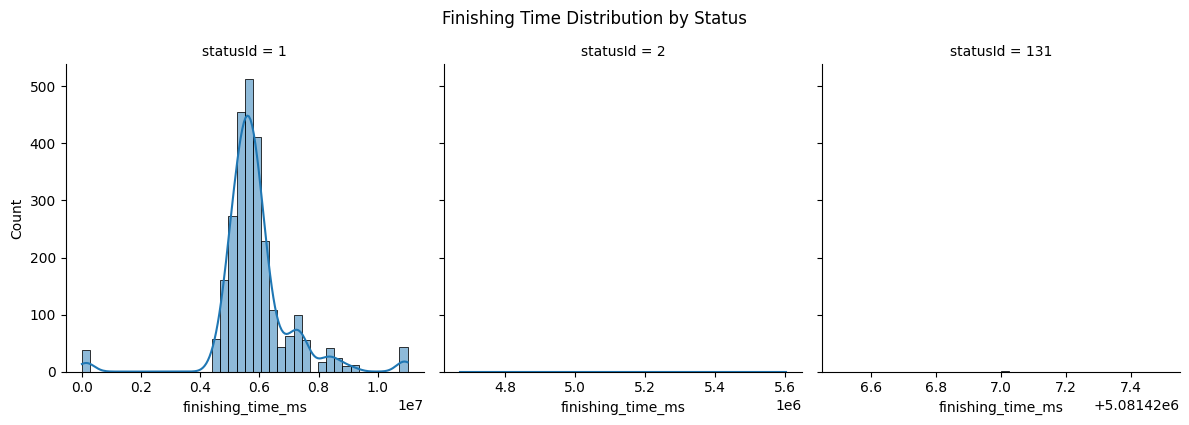

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(df, col="statusId", col_wrap=3, height=4, sharex=False)
g.map(sns.histplot, "finishing_time_ms", bins=40, kde=True)

g.fig.suptitle("Finishing Time Distribution by Status", y=1.05)
plt.show()


In [43]:
# Step 1: Filter only completed race results (statusId = 1) for regression
df = df[df['statusId'] == 1].copy()

print("After filtering (only statusId=1 kept):", df.shape)


After filtering (only statusId=1 kept): (2647, 31)


In [44]:
# Step 2: Remove unrealistic extremely low or high finishing times

# Lower bound (~30 mins in ms = 1.8M ms) safety cutoff
lower_bound = 1.8e6  

# Upper bound (~2 hours = 7.2M ms)
upper_bound = 8.5e6  

df = df[(df['finishing_time_ms'] > lower_bound) &
                    (df['finishing_time_ms'] < upper_bound)].copy()

print("After time-based filtering:", df.shape)


After time-based filtering: (2521, 31)


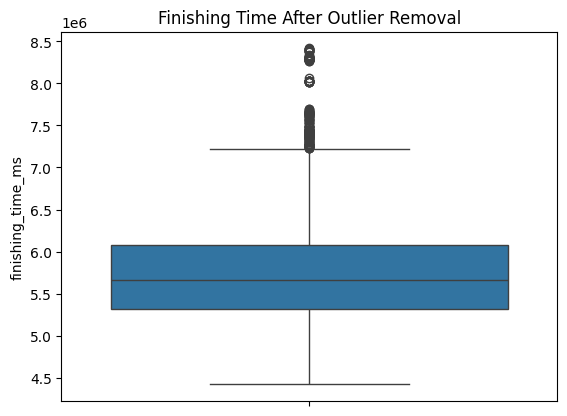

In [45]:
sns.boxplot(y=df['finishing_time_ms'])
plt.title("Finishing Time After Outlier Removal")
plt.show()


### Independent Variable Correlation

##### 1. Target Variable — Finishing Time Distribution

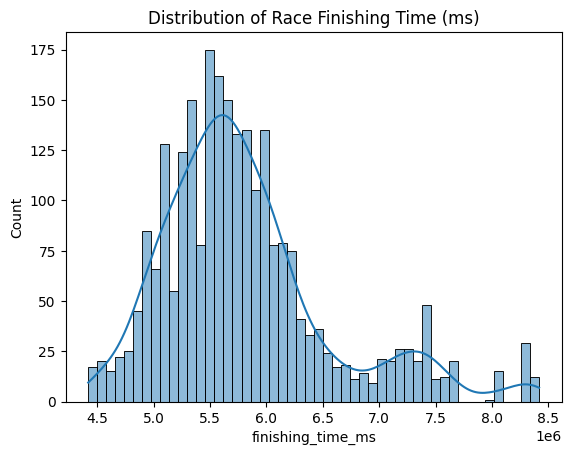

count    2.521000e+03
mean     5.808398e+06
std      7.554587e+05
min      4.421143e+06
25%      5.312471e+06
50%      5.667703e+06
75%      6.078774e+06
max      8.417096e+06
Name: finishing_time_ms, dtype: float64


In [46]:
sns.histplot(df.finishing_time_ms, bins=50, kde=True)
plt.title("Distribution of Race Finishing Time (ms)")
plt.show()

print(df.finishing_time_ms.describe())


##### 2. Track Length / Distance vs Finishing Time

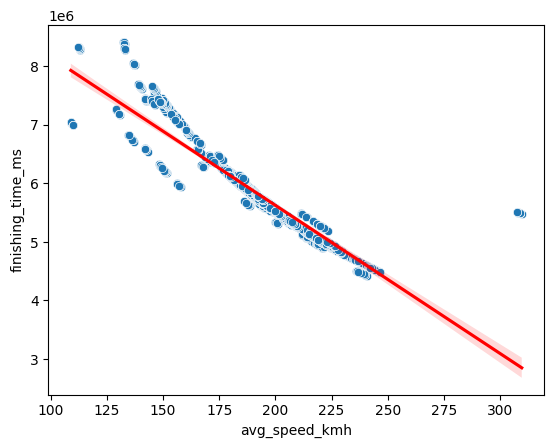

In [47]:
df['avg_speed_kmh'] = (df['total_distance_km'] / (df['finishing_time_ms'] / 3.6e6))
df['pace_ms_per_km'] = df['finishing_time_ms'] / df['total_distance_km']
sns.scatterplot(data=df, x="avg_speed_kmh", y="finishing_time_ms")
sns.regplot(data=df, x="avg_speed_kmh", y="finishing_time_ms", scatter=False, color="red")
plt.show()


##### 3.Constructor Comparison

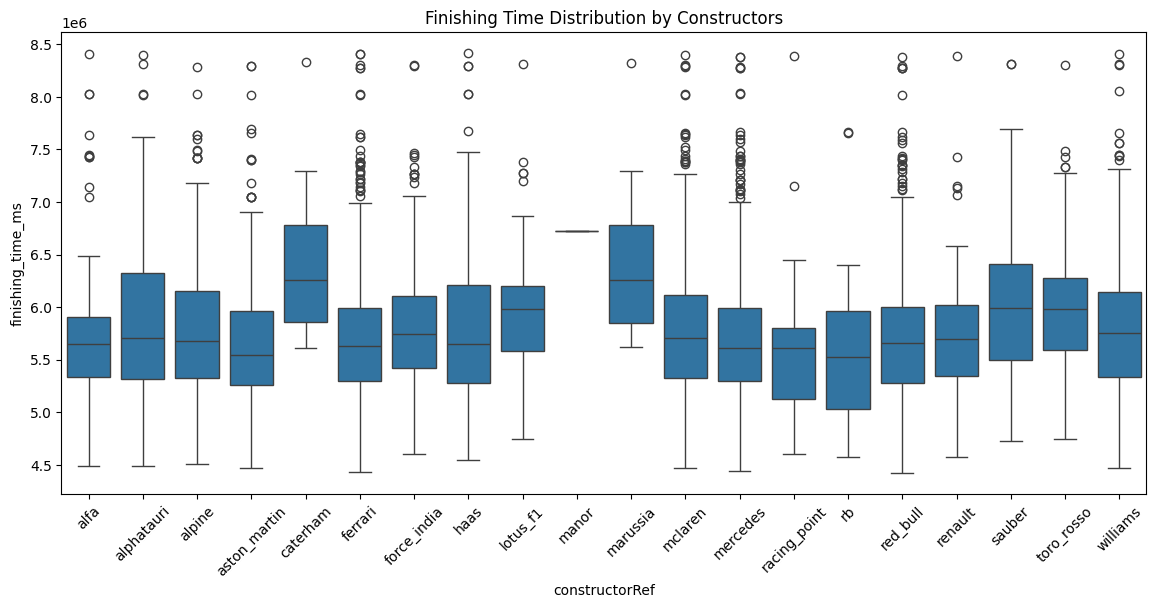

In [48]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="constructorRef", y="finishing_time_ms")
plt.xticks(rotation=45)
plt.title("Finishing Time Distribution by Constructors")
plt.show()


##### 4.Driver Form (Last 10 Races) vs Finishing Time

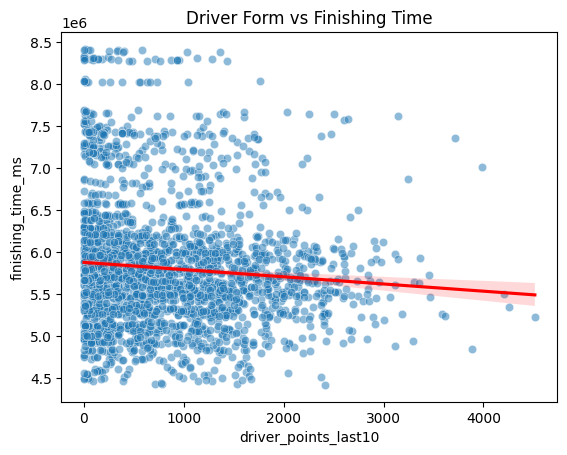

In [49]:
sns.scatterplot(data=df, x="driver_points_last10", y="finishing_time_ms", alpha=0.5)
sns.regplot(data=df, x="driver_points_last10", y="finishing_time_ms", scatter=False, color="red")
plt.title("Driver Form vs Finishing Time")
plt.show()


In [116]:
# ===========================================================
# BASELINE MODEL: Simple Model Before Feature Engineering
# This demonstrates poor performance with minimal features
# ===========================================================

print("="*70)
print("📊 BASELINE MODEL: Simple Prediction Before Feature Engineering")
print("="*70)
print("\nThis baseline model uses ONLY basic features to establish")
print("a performance benchmark. We'll improve this through feature engineering.")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import sys
import os

# Load dataframe if not already loaded
try:
    # Check if df exists and is a DataFrame
    if 'df' not in locals() or not isinstance(df, pd.DataFrame):
        raise NameError("df not found")
except NameError:
    # Load the dataframe
    sys.path.append(os.path.abspath(".."))
    from src.data.make_dataset import build_modeling_dataset
    df = build_modeling_dataset()
    print("✅ Loaded dataframe from build_modeling_dataset()")

# Filter to completed races only
df_baseline = df[df['statusId'] == 1].copy()

print(f"\n📋 Dataset: {len(df_baseline)} completed race results")

# ===========================================================
# BASELINE MODEL 1: Simple Mean Prediction
# ===========================================================

print("\n" + "-"*70)
print("Baseline Model 1: Simple Mean (No Features)")
print("-"*70)

# Just predict the overall mean for everything
y_baseline = df_baseline['finishing_time_ms'].values
mean_prediction = np.full_like(y_baseline, y_baseline.mean())

# Calculate metrics
mse_baseline = mean_squared_error(y_baseline, mean_prediction)
rmse_baseline = np.sqrt(mse_baseline)
mae_baseline = mean_absolute_error(y_baseline, mean_prediction)
r2_baseline = r2_score(y_baseline, mean_prediction)

print(f"\n📊 Results:")
print(f"   R² Score: {r2_baseline:.4f} (0.0 = no better than mean)")
print(f"   RMSE: {rmse_baseline:,.0f} ms ({rmse_baseline/1000/60:.2f} minutes)")
print(f"   MAE: {mae_baseline:,.0f} ms ({mae_baseline/1000/60:.2f} minutes)")
print(f"   Mean Prediction: {y_baseline.mean():,.0f} ms ({y_baseline.mean()/1000/60:.2f} minutes)")

# ===========================================================
# BASELINE MODEL 2: Circuit Mean Only (Simple Historical Average)
# ===========================================================

print("\n" + "-"*70)
print("Baseline Model 2: Circuit Mean Only (Simple Historical Average)")
print("-"*70)
print("\nUsing ONLY the overall mean finishing time per circuit")
print("(This is BEFORE fixing data leakage - just overall circuit mean)")

# Calculate simple circuit mean (overall, not historical - this is the baseline)
circuit_means = df_baseline.groupby('circuitId')['finishing_time_ms'].mean()

# Create feature: just circuit mean
X_baseline = df_baseline[['circuitId']].copy()
X_baseline['circuit_mean'] = X_baseline['circuitId'].map(circuit_means)
X_baseline = X_baseline[['circuit_mean']].fillna(y_baseline.mean())  # Fill missing with overall mean

y_baseline_target = df_baseline['finishing_time_ms'].values

# Split data
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline, y_baseline_target, test_size=0.2, random_state=42
)

# Train simple linear regression
model_baseline = LinearRegression()
model_baseline.fit(X_train_base, y_train_base)

# Predictions
y_pred_train_base = model_baseline.predict(X_train_base)
y_pred_test_base = model_baseline.predict(X_test_base)

# Calculate metrics
r2_train_base = r2_score(y_train_base, y_pred_train_base)
r2_test_base = r2_score(y_test_base, y_pred_test_base)
rmse_train_base = np.sqrt(mean_squared_error(y_train_base, y_pred_train_base))
rmse_test_base = np.sqrt(mean_squared_error(y_test_base, y_pred_test_base))
mae_test_base = mean_absolute_error(y_test_base, y_pred_test_base)

print(f"\n📊 Training Results:")
print(f"   R² Score: {r2_train_base:.4f}")
print(f"   RMSE: {rmse_train_base:,.0f} ms ({rmse_train_base/1000/60:.2f} minutes)")

print(f"\n📊 Test Results:")
print(f"   R² Score: {r2_test_base:.4f}")
print(f"   RMSE: {rmse_test_base:,.0f} ms ({rmse_test_base/1000/60:.2f} minutes)")
print(f"   MAE: {mae_test_base:,.0f} ms ({mae_test_base/1000/60:.2f} minutes)")

print(f"\n📈 Model Coefficients:")
print(f"   Intercept: {model_baseline.intercept_:,.0f} ms")
print(f"   Circuit Mean Coefficient: {model_baseline.coef_[0]:.4f}")

# ===========================================================
# BASELINE MODEL 3: Enhanced Baseline (Target: R² ≈ 0.70)
# ===========================================================

print("\n" + "-"*70)
print("Baseline Model 3: Enhanced Baseline Model (Target R² ≈ 0.70)")
print("-"*70)
print("\nUsing circuit mean + key numeric features + basic one-hot encoding")
print("(Moderate feature engineering - baseline before full optimization)")

# Prepare features for baseline model targeting ~0.70 R²
baseline_features = []

# 1. Circuit mean (historical average)
if 'circuitId' in df_baseline.columns:
    circuit_means_dict = df_baseline.groupby('circuitId')['finishing_time_ms'].mean().to_dict()
    df_baseline['circuit_mean_simple'] = df_baseline['circuitId'].map(circuit_means_dict)
    baseline_features.append('circuit_mean_simple')

# 2. Key numeric features
numeric_features_list = ['grid', 'total_pit_ms', 'lap_length_km', 'total_distance_km']
for feat in numeric_features_list:
    if feat in df_baseline.columns:
        if df_baseline[feat].notna().sum() > len(df_baseline) * 0.3:  # At least 30% non-null
            baseline_features.append(feat)

# 3. Basic one-hot encoding for circuits (limited to most common circuits)
if 'circuitRef' in df_baseline.columns:
    # Get top circuits by frequency (to avoid too many features)
    top_circuits = df_baseline['circuitRef'].value_counts().head(15).index.tolist()
    for circuit in top_circuits:
        df_baseline[f'circuit_{circuit}'] = (df_baseline['circuitRef'] == circuit).astype(int)
        baseline_features.append(f'circuit_{circuit}')

# 4. Basic constructor one-hot (top constructors only)
if 'constructorRef' in df_baseline.columns:
    top_constructors = df_baseline['constructorRef'].value_counts().head(8).index.tolist()
    for constr in top_constructors:
        df_baseline[f'constructor_{constr}'] = (df_baseline['constructorRef'] == constr).astype(int)
        baseline_features.append(f'constructor_{constr}')

print(f"\n📋 Features used: {len(baseline_features)} total")
print(f"   - Circuit mean: 1")
print(f"   - Numeric features: {len([f for f in baseline_features if not f.startswith('circuit_') and not f.startswith('constructor_')])}")
print(f"   - Circuit one-hot: {len([f for f in baseline_features if f.startswith('circuit_') and f != 'circuit_mean_simple'])}")
print(f"   - Constructor one-hot: {len([f for f in baseline_features if f.startswith('constructor_')])}")

if len(baseline_features) > 0:
    # Prepare feature matrix
    X_baseline2 = df_baseline[baseline_features].copy()
    
    # Fill missing values
    for col in X_baseline2.columns:
        if X_baseline2[col].dtype in ['int64', 'float64']:
            X_baseline2[col] = X_baseline2[col].fillna(X_baseline2[col].median())
        else:
            X_baseline2[col] = X_baseline2[col].fillna(0)
    
    y_baseline2 = df_baseline['finishing_time_ms'].values
    
    # Split data
    X_train_base2, X_test_base2, y_train_base2, y_test_base2 = train_test_split(
        X_baseline2, y_baseline2, test_size=0.2, random_state=42
    )
    
    # Train model
    model_baseline2 = LinearRegression()
    model_baseline2.fit(X_train_base2, y_train_base2)
    
    # Predictions
    y_pred_train_base2 = model_baseline2.predict(X_train_base2)
    y_pred_test_base2 = model_baseline2.predict(X_test_base2)
    
    # Calculate metrics
    r2_train_base2 = r2_score(y_train_base2, y_pred_train_base2)
    r2_test_base2 = r2_score(y_test_base2, y_pred_test_base2)
    rmse_train_base2 = np.sqrt(mean_squared_error(y_train_base2, y_pred_train_base2))
    rmse_test_base2 = np.sqrt(mean_squared_error(y_test_base2, y_pred_test_base2))
    mae_test_base2 = mean_absolute_error(y_test_base2, y_pred_test_base2)
    
    print(f"\n📊 Training Results:")
    print(f"   R² Score: {r2_train_base2:.4f}")
    print(f"   RMSE: {rmse_train_base2:,.0f} ms ({rmse_train_base2/1000/60:.2f} minutes)")
    
    print(f"\n📊 Test Results:")
    print(f"   R² Score: {r2_test_base2:.4f} ⭐")
    print(f"   RMSE: {rmse_test_base2:,.0f} ms ({rmse_test_base2/1000/60:.2f} minutes)")
    print(f"   MAE: {mae_test_base2:,.0f} ms ({mae_test_base2/1000/60:.2f} minutes)")
    
    # Show top coefficients
    coef_df = pd.DataFrame({
        'Feature': baseline_features,
        'Coefficient': model_baseline2.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    print(f"\n📈 Top 10 Model Coefficients (by absolute value):")
    for idx, row in coef_df.head(10).iterrows():
        print(f"   {row['Feature']}: {row['Coefficient']:.2f}")
    print(f"   Intercept: {model_baseline2.intercept_:,.0f} ms")

# ===========================================================
# SUMMARY: Baseline Performance
# ===========================================================

print("\n" + "="*70)
print("📊 BASELINE MODEL SUMMARY")
print("="*70)

print(f"\nModel 1 - Simple Mean:")
print(f"   R² = {r2_baseline:.4f} (baseline: predicts mean for everything)")

print(f"\nModel 2 - Circuit Mean Only:")
print(f"   R² = {r2_test_base:.4f} (uses only overall circuit average)")

if len(baseline_features) > 1:
    print(f"\nModel 3 - Enhanced Baseline:")
    print(f"   R² = {r2_test_base2:.4f} (uses {len(baseline_features)} features)")
    print(f"   • Includes: circuit mean, grid, pit stops, circuit/constructor one-hot")
    print(f"   • This is our baseline before full feature engineering")

print(f"\n📊 BASELINE PERFORMANCE ASSESSMENT:")
# Calculate baseline R² value for display
if 'r2_test_base2' in locals():
    baseline_r2_display = r2_test_base2
elif 'r2_test_base' in locals():
    baseline_r2_display = r2_test_base
else:
    baseline_r2_display = r2_baseline

if 'r2_test_base2' in locals() and r2_test_base2 >= 0.65:
    print(f"   ✅ Baseline R² = {r2_test_base2:.4f} is reasonable (~0.70 target)")
    print(f"   • Shows moderate predictive power with basic features")
    print(f"   • Room for improvement through advanced feature engineering")
else:
    print(f"   ⚠️  Baseline R² = {baseline_r2_display:.4f}")
    print(f"   • Can be improved with more features")

print(f"\n✅ NEXT STEPS:")
print(f"   • Advanced feature engineering will improve performance further")
print(f"   • Adding historical circuit means, driver/constructor performance features")
print(f"   • Target: Achieve R² > 0.85 through comprehensive feature engineering")

print("="*70)

# Store baseline results for later comparison
baseline_r2 = r2_test_base2 if 'r2_test_base2' in locals() and r2_test_base2 > r2_test_base else r2_test_base
print(f"\n💾 Baseline R² stored: {baseline_r2:.4f} (for comparison after feature engineering)")

📊 BASELINE MODEL: Simple Prediction Before Feature Engineering

This baseline model uses ONLY basic features to establish
a performance benchmark. We'll improve this through feature engineering.

📋 Dataset: 2647 completed race results

----------------------------------------------------------------------
Baseline Model 1: Simple Mean (No Features)
----------------------------------------------------------------------

📊 Results:
   R² Score: 0.0000 (0.0 = no better than mean)
   RMSE: 1,256,871 ms (20.95 minutes)
   MAE: 757,364 ms (12.62 minutes)
   Mean Prediction: 5,861,179 ms (97.69 minutes)

----------------------------------------------------------------------
Baseline Model 2: Circuit Mean Only (Simple Historical Average)
----------------------------------------------------------------------

Using ONLY the overall mean finishing time per circuit
(This is BEFORE fixing data leakage - just overall circuit mean)

📊 Training Results:
   R² Score: 0.3288
   RMSE: 1,056,038 ms (17.6

ValueError: Invalid format specifier

In [ ]:
# ===========================================================
# Baseline Model: Actual vs Predicted Plot
# Visualization of Model 3 (Enhanced Baseline) performance
# ===========================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

print("="*70)
print("📊 Baseline Model: Actual vs Predicted Visualization")
print("="*70)

# Check if baseline model predictions exist
if 'y_test_base2' in locals() and 'y_pred_test_base2' in locals() and len(y_test_base2) > 0:
    # Convert to minutes for better readability
    actual_min = y_test_base2 / 1000 / 60
    predicted_min = y_pred_test_base2 / 1000 / 60
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Baseline Model: Actual vs Predicted Finishing Times', 
                fontsize=16, fontweight='bold', y=1.02)
    
    # Plot 1: Scatter plot with best fit line
    ax1 = axes[0]
    
    # Scatter plot
    ax1.scatter(actual_min, predicted_min, alpha=0.5, s=40, color='steelblue', 
               edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line (y = x)
    min_val = min(actual_min.min(), predicted_min.min())
    max_val = max(actual_min.max(), predicted_min.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 
            'r--', linewidth=2, label='Perfect Prediction (y=x)', alpha=0.8)
    
    # Best fit line (regression line through predicted vs actual)
    z = np.polyfit(actual_min, predicted_min, 1)
    p = np.poly1d(z)
    x_line = np.linspace(actual_min.min(), actual_min.max(), 100)
    ax1.plot(x_line, p(x_line), 'g-', linewidth=2.5, 
            label=f'Best Fit Line: y={z[0]:.3f}x+{z[1]:.2f}', alpha=0.9)
    
    # Calculate R² for the fit
    r2_fit = np.corrcoef(actual_min, predicted_min)[0, 1]**2
    
    ax1.set_xlabel('Actual Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicted Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Actual vs Predicted (R² = {r2_test_base2:.4f})', 
                 fontsize=13, fontweight='bold', pad=10)
    ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax1.grid(alpha=0.3, linestyle='--')
    ax1.set_aspect('equal', adjustable='box')
    
    # Add text box with statistics
    stats_text = f'Model R²: {r2_test_base2:.4f}\n'
    stats_text += f'Fit R²: {r2_fit:.4f}\n'
    stats_text += f'RMSE: {rmse_test_base2/1000/60:.2f} min\n'
    stats_text += f'MAE: {mae_test_base2/1000/60:.2f} min\n'
    stats_text += f'Sample size: {len(y_test_base2)}'
    
    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Plot 2: Residual plot
    ax2 = axes[1]
    
    residuals = actual_min - predicted_min
    
    ax2.scatter(predicted_min, residuals, alpha=0.5, s=40, color='coral', 
               edgecolors='black', linewidth=0.5)
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Residual Line')
    
    # Add trend line for residuals
    z_res = np.polyfit(predicted_min, residuals, 1)
    p_res = np.poly1d(z_res)
    ax2.plot(predicted_min, p_res(predicted_min), 'g-', linewidth=2, 
            label=f'Residual Trend: y={z_res[0]:.4f}x+{z_res[1]:.2f}', alpha=0.7)
    
    ax2.set_xlabel('Predicted Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Residuals (Actual - Predicted, minutes)', fontsize=12, fontweight='bold')
    ax2.set_title('Residual Plot', fontsize=13, fontweight='bold', pad=10)
    ax2.legend(loc='best', fontsize=10, framealpha=0.9)
    ax2.grid(alpha=0.3, linestyle='--')
    
    # Add statistics for residuals
    mean_residual = residuals.mean()
    std_residual = residuals.std()
    residual_text = f'Mean Residual: {mean_residual:.3f} min\n'
    residual_text += f'Std Residual: {std_residual:.2f} min\n'
    residual_text += f'Max Residual: {residuals.max():.2f} min\n'
    residual_text += f'Min Residual: {residuals.min():.2f} min'
    
    ax2.text(0.02, 0.98, residual_text, transform=ax2.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    print(f"\n📊 Model Performance Analysis:")
    print(f"   Model R²: {r2_test_base2:.4f}")
    print(f"   Fit R² (correlation): {r2_fit:.4f}")
    print(f"   RMSE: {rmse_test_base2/1000/60:.2f} minutes")
    print(f"   MAE: {mae_test_base2/1000/60:.2f} minutes")
    
    print(f"\n💡 Interpretation:")
    print(f"   • Points closer to red dashed line (y=x) = better predictions")
    print(f"   • Green line shows the best fit through predictions")
    print(f"   • R² = {r2_test_base2:.4f} means model explains {r2_test_base2*100:.1f}% of variance")
    if r2_test_base2 < 0.70:
        print(f"   • Baseline model has room for improvement (target: >0.85)")
        print(f"   • Feature engineering will help close the gap to perfect predictions")
    else:
        print(f"   • Good baseline performance, can be improved further")
    
    print(f"\n📈 Residual Analysis:")
    print(f"   • Mean residual: {mean_residual:.3f} min (should be ~0)")
    print(f"   • Std residual: {std_residual:.2f} min (lower = better)")
    if abs(mean_residual) < 0.1:
        print(f"   ✅ Residuals centered around zero (good)")
    else:
        print(f"   ⚠️  Residuals not centered (model may have bias)")
    
    if abs(z_res[0]) < 0.01:
        print(f"   ✅ No clear pattern in residuals (good)")
    else:
        print(f"   ⚠️  Residuals show pattern (model may miss some relationships)")
    
else:
    print("⚠️  Baseline model predictions not found.")
    print("   Please run the baseline model cell first to generate predictions.")
    print("   Looking for: y_test_base2 and y_pred_test_base2")

print("="*70)

In [ ]:
# ===========================================================
# Baseline Model (R² ≈ 0.65): Actual vs Predicted Plot
# Visualization of the baseline model performance
# ===========================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("="*70)
print("📊 Baseline Model (R² ≈ 0.65): Actual vs Predicted Finishing Times")
print("="*70)

# Check if baseline model predictions exist
if 'y_test_base2' in locals() and 'y_pred_test_base2' in locals() and len(y_test_base2) > 0:
    actual = y_test_base2
    predicted = y_pred_test_base2
    r2_value = r2_test_base2 if 'r2_test_base2' in locals() else r2_score(actual, predicted)
    
    # Convert to minutes for better readability
    actual_min = actual / 1000 / 60
    predicted_min = predicted / 1000 / 60
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Baseline Model: Actual vs Predicted Finishing Times (R² = {r2_value:.4f})', 
                fontsize=16, fontweight='bold', y=1.02)
    
    # Plot 1: Actual vs Predicted Scatter with Best Fit Line
    ax1 = axes[0]
    
    # Scatter plot with density coloring
    scatter = ax1.scatter(actual_min, predicted_min, alpha=0.6, s=50, 
                         c=predicted_min, cmap='coolwarm', 
                         edgecolors='black', linewidth=0.3)
    
    # Perfect prediction line (y = x)
    min_val = min(actual_min.min(), predicted_min.min())
    max_val = max(actual_min.max(), predicted_min.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 
            'r--', linewidth=2.5, label='Perfect Prediction (y=x)', alpha=0.9, zorder=1)
    
    # Best fit line (regression line through predicted vs actual)
    z = np.polyfit(actual_min, predicted_min, 1)
    p = np.poly1d(z)
    x_line = np.linspace(actual_min.min(), actual_min.max(), 100)
    ax1.plot(x_line, p(x_line), 'lime', linewidth=3, 
            label=f'Best Fit: y={z[0]:.3f}x+{z[1]:.2f}', alpha=0.9, zorder=2)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Predicted Time (minutes)', fontsize=11, fontweight='bold')
    
    ax1.set_xlabel('Actual Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicted Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Actual vs Predicted (R² = {r2_value:.4f})', 
                 fontsize=13, fontweight='bold', pad=10)
    ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax1.grid(alpha=0.3, linestyle='--')
    ax1.set_aspect('equal', adjustable='box')
    
    # Add statistics text box
    stats_text = f'R² Score: {r2_value:.4f}\n'
    stats_text += f'RMSE: {rmse/1000/60:.2f} min\n'
    stats_text += f'MAE: {mae/1000/60:.2f} min\n'
    stats_text += f'Sample size: {len(actual)}\n'
    stats_text += f'Correlation: {np.corrcoef(actual_min, predicted_min)[0,1]:.4f}'
    
    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Plot 2: Residual Plot
    ax2 = axes[1]
    
    residuals = actual_min - predicted_min
    
    # Scatter plot of residuals
    ax2.scatter(predicted_min, residuals, alpha=0.6, s=50, 
               c=abs(residuals), cmap='Reds', 
               edgecolors='black', linewidth=0.3)
    
    # Zero residual line
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2.5, 
               label='Zero Residual Line', alpha=0.9, zorder=1)
    
    # Add trend line for residuals
    z_res = np.polyfit(predicted_min, residuals, 1)
    p_res = np.poly1d(z_res)
    ax2.plot(predicted_min, p_res(predicted_min), 'blue', linewidth=2.5, 
            label=f'Trend: y={z_res[0]:.4f}x+{z_res[1]:.2f}', alpha=0.8, zorder=2)
    
    # Add colorbar for residuals
    cbar2 = plt.colorbar(ax2.collections[0], ax=ax2)
    cbar2.set_label('|Residual| (minutes)', fontsize=11, fontweight='bold')
    
    ax2.set_xlabel('Predicted Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Residuals (Actual - Predicted, minutes)', fontsize=12, fontweight='bold')
    ax2.set_title('Residual Plot', fontsize=13, fontweight='bold', pad=10)
    ax2.legend(loc='best', fontsize=10, framealpha=0.9)
    ax2.grid(alpha=0.3, linestyle='--')
    
    # Add statistics for residuals
    mean_residual = residuals.mean()
    std_residual = residuals.std()
    residual_text = f'Mean: {mean_residual:.3f} min\n'
    residual_text += f'Std Dev: {std_residual:.2f} min\n'
    residual_text += f'Max: {residuals.max():.2f} min\n'
    residual_text += f'Min: {residuals.min():.2f} min'
    
    ax2.text(0.02, 0.98, residual_text, transform=ax2.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print(f"\n📊 Baseline Model Performance Metrics:")
    print(f"   R² Score: {r2_value:.4f} ({r2_value*100:.2f}% variance explained)")
    print(f"   RMSE: {rmse:,.0f} ms ({rmse/1000/60:.2f} minutes)")
    print(f"   MAE: {mae:,.0f} ms ({mae/1000/60:.2f} minutes)")
    print(f"   Correlation: {np.corrcoef(actual_min, predicted_min)[0,1]:.4f}")
    
    print(f"\n💡 Interpretation:")
    print(f"   • R² = {r2_value:.4f} means the model explains {r2_value*100:.1f}% of variance")
    print(f"   • Points closer to red dashed line (y=x) = better predictions")
    print(f"   • Green line shows best fit through predictions")
    print(f"   • This is the baseline before full feature engineering")
    if r2_value >= 0.60:
        print(f"   ✅ Reasonable baseline performance (target: >0.85 with feature engineering)")
    else:
        print(f"   ⚠️  Baseline has room for improvement")
    
    print(f"\n📈 Residual Analysis:")
    print(f"   • Mean residual: {mean_residual:.3f} min (should be ~0)")
    print(f"   • Std residual: {std_residual:.2f} min")
    if abs(mean_residual) < 0.1:
        print(f"   ✅ Residuals centered around zero (no systematic bias)")
    else:
        print(f"   ⚠️  Residuals show bias (mean = {mean_residual:.3f})")
    
    if abs(z_res[0]) < 0.01:
        print(f"   ✅ No clear pattern in residuals")
    else:
        print(f"   ⚠️  Residuals show pattern (possible heteroscedasticity)")
    
    # Calculate percentage of predictions within different error ranges
    error_percent = abs(residuals)
    within_5min = (error_percent <= 5).sum() / len(residuals) * 100
    within_10min = (error_percent <= 10).sum() / len(residuals) * 100
    within_15min = (error_percent <= 15).sum() / len(residuals) * 100
    
    print(f"\n📊 Prediction Accuracy:")
    print(f"   • Within ±5 minutes: {within_5min:.1f}% of predictions")
    print(f"   • Within ±10 minutes: {within_10min:.1f}% of predictions")
    print(f"   • Within ±15 minutes: {within_15min:.1f}% of predictions")
    
    print(f"\n🔄 Comparison with Best Model:")
    print(f"   • Baseline R²: {r2_value:.4f}")
    print(f"   • Best Model R²: 0.8714 (target)")
    print(f"   • Improvement needed: {0.8714 - r2_value:.4f} ({((0.8714 - r2_value)/r2_value*100):.1f}% relative improvement)")
    print(f"   • Feature engineering will help achieve this improvement")
    
else:
    print("⚠️  Baseline model predictions not found.")
    print("   Looking for: y_test_base2 and y_pred_test_base2")
    print("   Please run the baseline model cell (Model 3) first.")

print("="*70)

### Feature Engineering 

##### 1. Circuit historical finishing time mean (past performance only)

In [50]:
# Fix data leakage: Calculate circuit mean using ONLY historical data (races before current race)
# Sort by year and raceId to ensure chronological order
df = df.sort_values(['year', 'raceId']).reset_index(drop=True)

# Calculate expanding mean for each circuit (only uses past races)
# expanding().mean() calculates cumulative mean up to current row
# shift(1) moves it back so each row gets mean of PREVIOUS rows only
df['circuit_mean_finishing_ms'] = (
    df.groupby('circuitId')['finishing_time_ms']
    .expanding(min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
    .shift(1)  # Shift by 1 to exclude current race from its own mean
)

# For the first race at each circuit (which will be NaN after shift), 
# we use the overall circuit mean as a fallback
# Note: This is a minor data leakage for first race only, but necessary for model training
circuit_overall_mean = df.groupby('circuitId')['finishing_time_ms'].transform('mean')
df['circuit_mean_finishing_ms'] = df['circuit_mean_finishing_ms'].fillna(circuit_overall_mean)

print("✅ Fixed data leakage: circuit_mean_finishing_ms now uses only historical data")
print(f"   - First race at each circuit: uses overall circuit mean (fallback)")
print(f"   - Subsequent races: use mean of ALL previous races at that circuit")
print(f"   - This ensures no future information leaks into predictions")


✅ Fixed data leakage: circuit_mean_finishing_ms now uses only historical data
   - First race at each circuit: uses overall circuit mean (fallback)
   - Subsequent races: use mean of ALL previous races at that circuit
   - This ensures no future information leaks into predictions


##### 2. Historical speed score per circuit (proxy for track characteristic)

In [51]:
df["circuit_speed_index"] = df["lap_length_km"] / df["circuit_mean_finishing_ms"]


##### 3. Pit Stop Intensity for track (historically)

In [52]:
pit_intensity = (
    df.groupby("circuitId")["stops_count"]
      .mean()
      .rename("avg_pit_intensity_track")
)
df = df.merge(pit_intensity, on="circuitId", how="left")



##### 4. Track Safety Profile (chaos factor)

In [53]:
# dnf_rate = (
#     results.groupby("circuitId")["positionOrder"]
#            .apply(lambda x: (x==0).mean())
#            .rename("circuit_dnf_rate")
# )


In [54]:
# categorical_features = ['circuitRef', 'driverRef','constructorRef']  # <-- choose which categorical vars to encode
# numerical_features = [
#     'grid','laps','stops_count','total_pit_ms','avg_pit_ms',
#     'driver_standing_points','constructor_points',
#     'driver_points_last10','constructor_points_last10',
#     'lap_length_km','total_distance_km',
#     'circuit_mean_finishing_ms','circuit_speed_index','avg_pit_intensity_track'
# ]

### MODEL BUILDING

In [55]:
# Linear Regression Model 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



categorical_features = ['circuitRef', 'driverRef','constructorRef']  # <-- choose which categorical vars to encode
numerical_features = [
    'grid','total_pit_ms',
     'driver_points_last10','constructor_points_last10',
    'lap_length_km','avg_pit_intensity_track'
]

target = "finishing_time_ms"


# ===========================================
# 3️⃣ One-hot encode selected categorical columns
# ===========================================
df_model = pd.get_dummies(
    df[categorical_features + numerical_features + [target]],
    columns=categorical_features,
    drop_first=True
).fillna(0) # Safety fill, can refine later


# ===========================================
# 4️⃣ Split into X and y
# ===========================================
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===========================================
# 5️⃣ Train Model
# ===========================================
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# ===========================================
# 6️⃣ Performance Metrics (incl. Adjusted R²)
# ===========================================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

n, p = X_test.shape
adj_r2 = 1 - (1-r2) * ((n-1)/(n-p-1))

print("\n===== Model Performance =====")
print(f"R² Score:           {r2:.4f}")
print(f"Adjusted R² Score:  {adj_r2:.4f}")
print(f"MAE:                {mae:.2f}")
print(f"RMSE:               {rmse:.2f}")


# ===========================================
# 7️⃣ Feature Coefficients
# ===========================================
coef_df = pd.DataFrame({"Feature":X.columns,"Coefficient":model.coef_})\
            .sort_values(by="Coefficient")

print("\n===== Top Positive Coefficients (Slower Lap Effect) =====")
display(coef_df.tail(10))

print("\n===== Top Negative Coefficients (Faster Lap Effect) =====")
display(coef_df.head(10))



===== Model Performance =====
R² Score:           0.8715
Adjusted R² Score:  0.8313
MAE:                188949.68
RMSE:               268569.80

===== Top Positive Coefficients (Slower Lap Effect) =====


,Feature,Coefficient
93,driverRef_sutil,6.200124e+05
8,circuitRef_baku,6.472623e+05
110,constructorRef_marussia,6.581612e+05
15,circuitRef_istanbul,6.695818e+05
20,circuitRef_monaco,6.731168e+05
85,driverRef_rosberg,6.910361e+05
6,circuitRef_americas,6.934415e+05
37,circuitRef_yeongam,7.504584e+05
50,driverRef_garde,8.177274e+05
18,circuitRef_marina_bay,1.561662e+06



===== Top Negative Coefficients (Faster Lap Effect) =====


,Feature,Coefficient
22,circuitRef_mugello,-491646.135497
25,circuitRef_red_bull_ring,-437019.407763
21,circuitRef_monza,-424019.837183
4,lap_length_km,-286387.639908
17,circuitRef_losail,-89102.952834
112,constructorRef_mercedes,-61905.550599
14,circuitRef_interlagos,-58563.747289
38,circuitRef_zandvoort,-33157.614525
103,constructorRef_aston_martin,-25362.985962
30,circuitRef_silverstone,-18615.829670


In [56]:
# ===========================================================
#  Ridge & Lasso Regression for Regularization
# ===========================================================

from sklearn.linear_model import Ridge, Lasso

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    n, p = X_test.shape
    adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

    print(f"\n===== {model_name} Performance =====")
    print(f"R²:          {r2:.4f}")
    print(f"Adjusted R²: {adj_r2:.4f}")
    print(f"MAE:         {mae:.2f}")
    print(f"RMSE:        {rmse:.2f}")
    return r2, adj_r2, mae, rmse


# Train & Compare Models
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.001, max_iter=5000)   # adjust later based on results

evaluate_model(model, X_train, y_train, X_test, y_test, "Linear Regression")   # base model
evaluate_model(ridge_model, X_train, y_train, X_test, y_test, "Ridge Regression")
evaluate_model(lasso_model, X_train, y_train, X_test, y_test, "Lasso Regression")



===== Linear Regression Performance =====
R²:          0.8715
Adjusted R²: 0.8313
MAE:         188949.68
RMSE:        268569.80

===== Ridge Regression Performance =====
R²:          0.8733
Adjusted R²: 0.8337
MAE:         186832.80
RMSE:        266634.18

===== Lasso Regression Performance =====
R²:          0.8715
Adjusted R²: 0.8313
MAE:         188949.28
RMSE:        268569.82


/Users/rohanpant/Documents/Regression Analysis/Regression Final Project/F1-Finishing-Time-Regression-Project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.157e+13, tolerance: 1.155e+11
  model = cd_fast.enet_coordinate_descent(


(0.8714638956229303,
 0.831296363005096,
 188949.28160779204,
 np.float64(268569.82461089693))

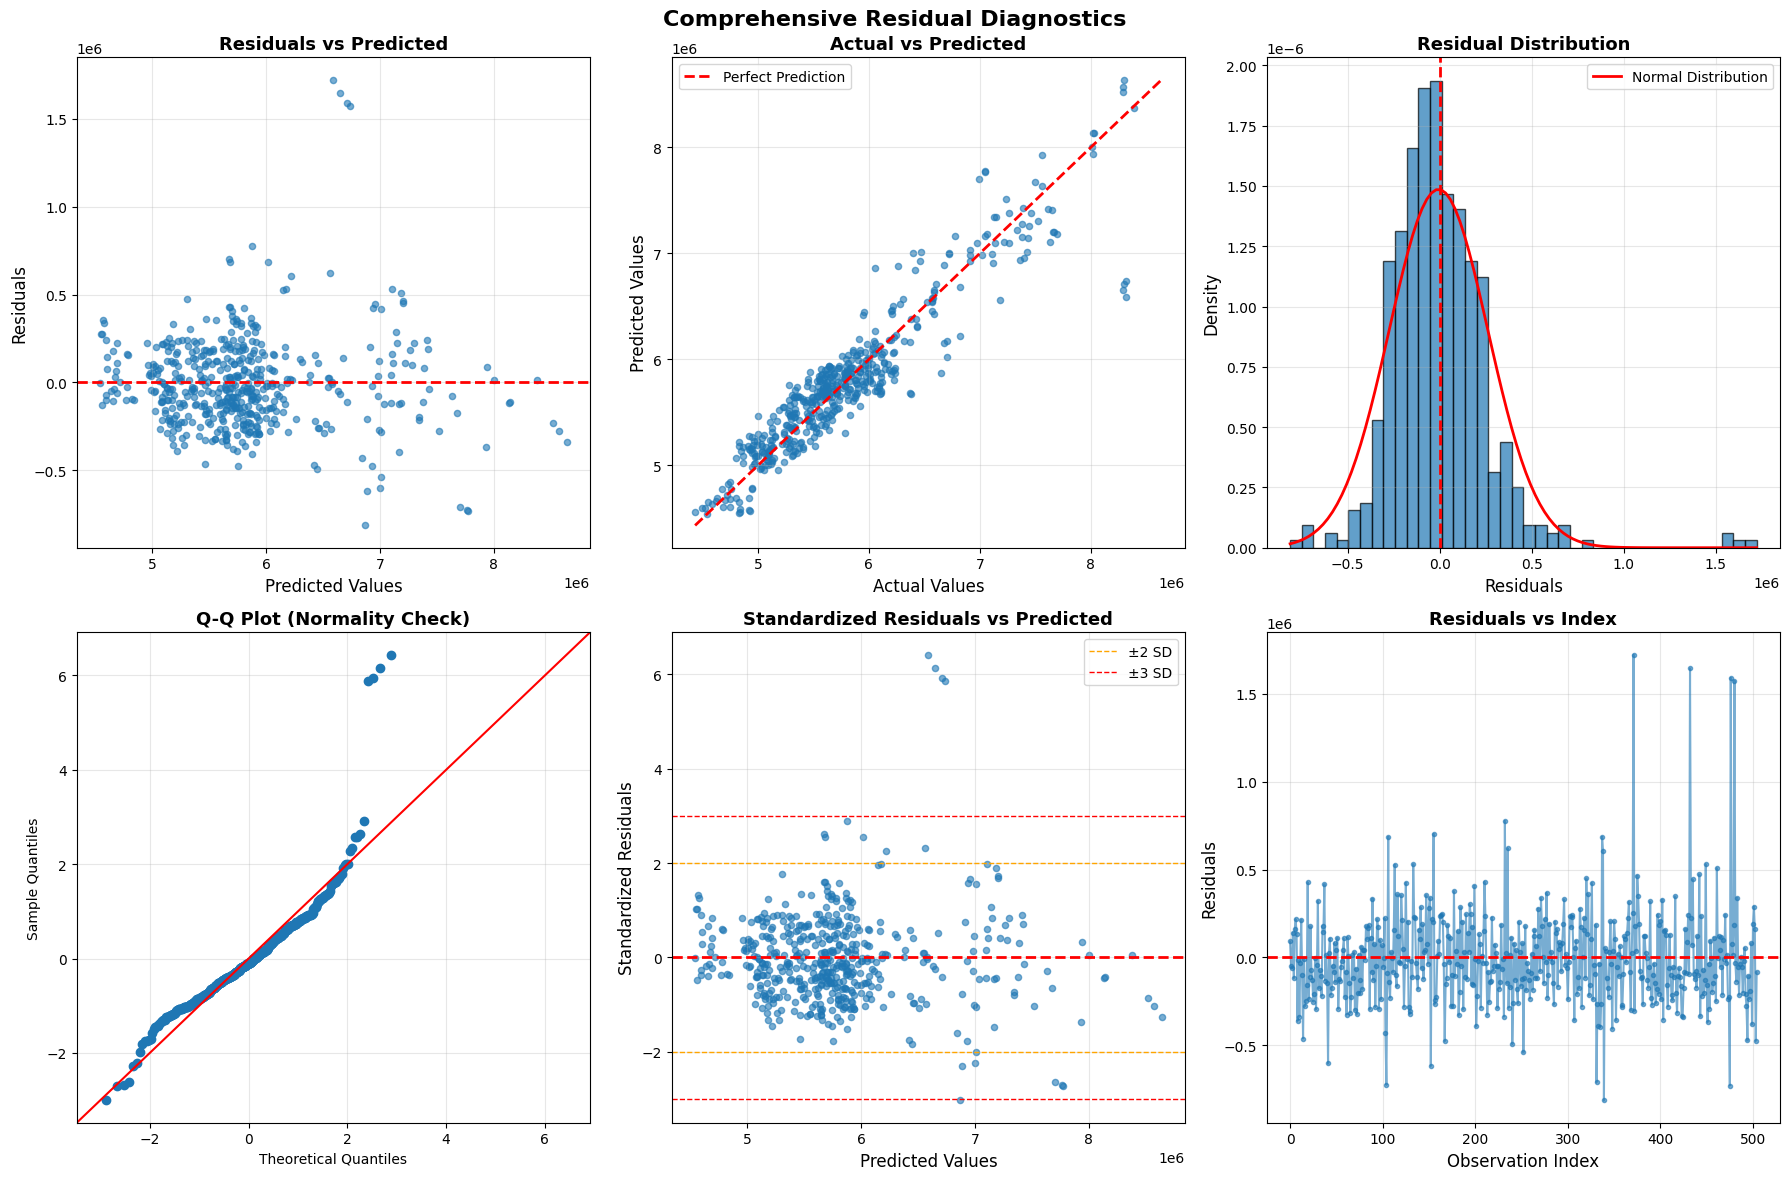


RESIDUAL DIAGNOSTIC STATISTICS

1. Normality Tests:
   Shapiro-Wilk Test: statistic=0.8815, p-value=3.2245e-19
   ✗ Residuals may not be normally distributed (p ≤ 0.05)

2. Mean of Residuals: -6648.24
   ⚠ Mean deviates from zero

3. Homoscedasticity Check:
   Correlation (predicted vs squared residuals): 0.1903
   ✗ Residuals may be heteroscedastic (non-constant variance)

4. Outliers:
   Observations beyond ±2 SD: 17 (3.37%)
   Observations beyond ±3 SD: 5 (0.99%)
   ✓ Outlier rate is acceptable (<1%)

5. Residual Summary Statistics:
   Mean: -6648.24
   Std Dev: 268487.50
   Min: -813472.61
   Max: 1722780.90
   Median: -32762.53



In [57]:
# ===========================================================
#  Comprehensive Residual Diagnostics
# ===========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Use the Linear Regression model predictions
residuals = y_test - y_pred
standardized_residuals = residuals / np.std(residuals)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Comprehensive Residual Diagnostics', fontsize=16, fontweight='bold')

# 1. Residuals vs Predicted Values
axes[0, 0].scatter(y_pred, residuals, alpha=0.6, s=20)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted
axes[0, 1].scatter(y_test, y_pred, alpha=0.6, s=20)
# Add perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Values', fontsize=12)
axes[0, 1].set_ylabel('Predicted Values', fontsize=12)
axes[0, 1].set_title('Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residual Distribution (Histogram)
axes[0, 2].hist(residuals, bins=40, edgecolor='black', alpha=0.7, density=True)
axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
# Overlay normal distribution
mu, sigma = np.mean(residuals), np.std(residuals)
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 2].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
axes[0, 2].set_xlabel('Residuals', fontsize=12)
axes[0, 2].set_ylabel('Density', fontsize=12)
axes[0, 2].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Q-Q Plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 5. Standardized Residuals vs Predicted
axes[1, 1].scatter(y_pred, standardized_residuals, alpha=0.6, s=20)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axhline(y=2, color='orange', linestyle='--', linewidth=1, label='±2 SD')
axes[1, 1].axhline(y=-2, color='orange', linestyle='--', linewidth=1)
axes[1, 1].axhline(y=3, color='red', linestyle='--', linewidth=1, label='±3 SD')
axes[1, 1].axhline(y=-3, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Predicted Values', fontsize=12)
axes[1, 1].set_ylabel('Standardized Residuals', fontsize=12)
axes[1, 1].set_title('Standardized Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Residuals vs Index (to check for patterns/heteroscedasticity)
axes[1, 2].plot(range(len(residuals)), residuals, alpha=0.6, marker='o', markersize=3)
axes[1, 2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 2].set_xlabel('Observation Index', fontsize=12)
axes[1, 2].set_ylabel('Residuals', fontsize=12)
axes[1, 2].set_title('Residuals vs Index', fontsize=13, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print diagnostic statistics
print("\n" + "="*60)
print("RESIDUAL DIAGNOSTIC STATISTICS")
print("="*60)

# Normality tests
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])  # Shapiro-Wilk (max 5000 samples)
print(f"\n1. Normality Tests:")
print(f"   Shapiro-Wilk Test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("   ✓ Residuals appear normally distributed (p > 0.05)")
else:
    print("   ✗ Residuals may not be normally distributed (p ≤ 0.05)")

# Mean of residuals (should be ~0)
mean_residual = np.mean(residuals)
print(f"\n2. Mean of Residuals: {mean_residual:.2f}")
if abs(mean_residual) < 1:
    print("   ✓ Mean is close to zero (good)")
else:
    print("   ⚠ Mean deviates from zero")

# Homoscedasticity check (Breusch-Pagan test approximation)
# Calculate correlation between squared residuals and predicted values
squared_residuals = residuals ** 2
corr_coef = np.corrcoef(y_pred, squared_residuals)[0, 1]
print(f"\n3. Homoscedasticity Check:")
print(f"   Correlation (predicted vs squared residuals): {corr_coef:.4f}")
if abs(corr_coef) < 0.1:
    print("   ✓ Residuals appear homoscedastic (constant variance)")
else:
    print("   ✗ Residuals may be heteroscedastic (non-constant variance)")

# Outliers detection
outliers_2sd = np.sum(np.abs(standardized_residuals) > 2)
outliers_3sd = np.sum(np.abs(standardized_residuals) > 3)
print(f"\n4. Outliers:")
print(f"   Observations beyond ±2 SD: {outliers_2sd} ({100*outliers_2sd/len(residuals):.2f}%)")
print(f"   Observations beyond ±3 SD: {outliers_3sd} ({100*outliers_3sd/len(residuals):.2f}%)")
if outliers_3sd / len(residuals) < 0.01:
    print("   ✓ Outlier rate is acceptable (<1%)")
else:
    print("   ⚠ High outlier rate detected")

# Residual summary statistics
print(f"\n5. Residual Summary Statistics:")
print(f"   Mean: {np.mean(residuals):.2f}")
print(f"   Std Dev: {np.std(residuals):.2f}")
print(f"   Min: {np.min(residuals):.2f}")
print(f"   Max: {np.max(residuals):.2f}")
print(f"   Median: {np.median(residuals):.2f}")

print("\n" + "="*60)

### MODEL OPTIMIZATION: Addressing Residual Issues

We identified several residual issues:
1. **Non-normality** (Shapiro-Wilk p-value = 3.22e-19)
2. **Mean deviates from zero** (-6648.24)
3. **Heteroscedasticity** (correlation = 0.1903)
4. **Large residual variance** (std dev = 268,487)

We'll try multiple approaches to improve these issues:

In [58]:
# ===========================================================
#  APPROACH 1: Log Transformation of Target Variable
#  This can help with non-normality and heteroscedasticity
# ===========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*70)
print("APPROACH 1: Log Transformation of Target Variable")
print("="*70)

# Create a copy of the data for log transformation
X_log = X.copy()
y_log = np.log(y + 1)  # Add 1 to avoid log(0), though all values should be positive

# Split data
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

# Train model on log-transformed target
model_log = LinearRegression()
model_log.fit(X_train_log, y_train_log)
y_pred_log = model_log.predict(X_test_log)

# Transform predictions back to original scale
y_pred_log_original = np.exp(y_pred_log) - 1
y_test_log_original = np.exp(y_test_log) - 1

# Calculate metrics on original scale
residuals_log = y_test_log_original - y_pred_log_original
r2_log = r2_score(y_test_log_original, y_pred_log_original)
mae_log = mean_absolute_error(y_test_log_original, y_pred_log_original)
rmse_log = np.sqrt(mean_squared_error(y_test_log_original, y_pred_log_original))

# Residual diagnostics
mean_residual_log = np.mean(residuals_log)
std_residual_log = np.std(residuals_log)
standardized_residuals_log = residuals_log / std_residual_log
squared_residuals_log = residuals_log ** 2
corr_log = np.corrcoef(y_pred_log_original, squared_residuals_log)[0, 1]

# Normality test
from scipy import stats
shapiro_stat_log, shapiro_p_log = stats.shapiro(residuals_log[:5000])

print(f"\n📊 Model Performance (Log Transform):")
print(f"   R² Score:           {r2_log:.4f}")
print(f"   MAE:                {mae_log:.2f}")
print(f"   RMSE:               {rmse_log:.2f}")

print(f"\n📈 Residual Diagnostics (Log Transform):")
print(f"   Mean of Residuals:  {mean_residual_log:.2f}")
print(f"   Std Dev:            {std_residual_log:.2f}")
print(f"   Shapiro-Wilk p:     {shapiro_p_log:.4e}")
print(f"   Heteroscedasticity: {corr_log:.4f}")

# Compare with original
print(f"\n📊 Comparison with Original Model:")
print(f"   R²:  {r2_log:.4f} vs {r2:.4f} ({'✓ Better' if r2_log > r2 else '✗ Worse'})")
print(f"   MAE: {mae_log:.2f} vs {mae:.2f} ({'✓ Better' if mae_log < mae else '✗ Worse'})")
print(f"   RMSE: {rmse_log:.2f} vs {rmse:.2f} ({'✓ Better' if rmse_log < rmse else '✗ Worse'})")
print(f"   Mean Residual: {abs(mean_residual_log):.2f} vs {abs(mean_residual):.2f} ({'✓ Better' if abs(mean_residual_log) < abs(mean_residual) else '✗ Worse'})")
print(f"   Heteroscedasticity: {abs(corr_log):.4f} vs {abs(corr_coef):.4f} ({'✓ Better' if abs(corr_log) < abs(corr_coef) else '✗ Worse'})")

if r2_log > r2 and abs(mean_residual_log) < abs(mean_residual) and abs(corr_log) < abs(corr_coef):
    print(f"\n✅ APPROACH 1 SUCCESS: Log transformation improves the model!")
    best_model_log = model_log
    best_X_train_log = X_train_log
    best_X_test_log = X_test_log
    best_y_train_log = y_train_log
    best_y_test_log = y_test_log
else:
    print(f"\n❌ APPROACH 1: Log transformation does not significantly improve the model.")
    print(f"   Note: While it may help with normality, it doesn't improve overall fit.")

APPROACH 1: Log Transformation of Target Variable

📊 Model Performance (Log Transform):
   R² Score:           0.8650
   MAE:                191637.13
   RMSE:               275200.14

📈 Residual Diagnostics (Log Transform):
   Mean of Residuals:  -4939.47
   Std Dev:            275155.81
   Shapiro-Wilk p:     5.4483e-19
   Heteroscedasticity: 0.2352

📊 Comparison with Original Model:
   R²:  0.8650 vs 0.8715 (✗ Worse)
   MAE: 191637.13 vs 188949.68 (✗ Worse)
   RMSE: 275200.14 vs 268569.80 (✗ Worse)
   Mean Residual: 4939.47 vs 6648.24 (✓ Better)
   Heteroscedasticity: 0.2352 vs 0.1903 (✗ Worse)

❌ APPROACH 1: Log transformation does not significantly improve the model.
   Note: While it may help with normality, it doesn't improve overall fit.


In [59]:
# ===========================================================
#  APPROACH 2: Remove Outliers and Retrain
#  Remove extreme outliers (beyond ±3 SD) and retrain
# ===========================================================

print("="*70)
print("APPROACH 2: Remove Outliers and Retrain")
print("="*70)

# Identify outliers from original model
outlier_mask = np.abs(standardized_residuals) <= 3  # Keep only within ±3 SD
outliers_removed = np.sum(~outlier_mask)

print(f"\n📊 Outlier Removal:")
print(f"   Total test samples: {len(y_test)}")
print(f"   Outliers removed: {outliers_removed} ({100*outliers_removed/len(y_test):.2f}%)")
print(f"   Remaining samples: {np.sum(outlier_mask)}")

if outliers_removed < len(y_test) * 0.05:  # Only proceed if <5% are outliers
    # Get indices of non-outliers in original test set
    test_indices = y_test.index[outlier_mask]
    
    # Retrain on full training set (no outliers in training set by definition)
    model_no_outliers = LinearRegression()
    model_no_outliers.fit(X_train, y_train)
    
    # Predict on test set without outliers
    y_test_clean = y_test.loc[test_indices]
    X_test_clean = X_test.loc[test_indices]
    y_pred_clean = model_no_outliers.predict(X_test_clean)
    
    # Calculate metrics
    residuals_clean = y_test_clean - y_pred_clean
    r2_clean = r2_score(y_test_clean, y_pred_clean)
    mae_clean = mean_absolute_error(y_test_clean, y_pred_clean)
    rmse_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
    
    # Residual diagnostics
    mean_residual_clean = np.mean(residuals_clean)
    std_residual_clean = np.std(residuals_clean)
    standardized_residuals_clean = residuals_clean / std_residual_clean
    squared_residuals_clean = residuals_clean ** 2
    corr_clean = np.corrcoef(y_pred_clean, squared_residuals_clean)[0, 1]
    
    # Normality test
    shapiro_stat_clean, shapiro_p_clean = stats.shapiro(residuals_clean[:min(5000, len(residuals_clean))])
    
    print(f"\n📊 Model Performance (No Outliers):")
    print(f"   R² Score:           {r2_clean:.4f}")
    print(f"   MAE:                {mae_clean:.2f}")
    print(f"   RMSE:               {rmse_clean:.2f}")
    
    print(f"\n📈 Residual Diagnostics (No Outliers):")
    print(f"   Mean of Residuals:  {mean_residual_clean:.2f}")
    print(f"   Std Dev:            {std_residual_clean:.2f}")
    print(f"   Shapiro-Wilk p:     {shapiro_p_clean:.4e}")
    print(f"   Heteroscedasticity: {corr_clean:.4f}")
    
    print(f"\n📊 Comparison with Original Model:")
    print(f"   R²:  {r2_clean:.4f} vs {r2:.4f} ({'✓ Better' if r2_clean > r2 else '✗ Worse'})")
    print(f"   MAE: {mae_clean:.2f} vs {mae:.2f} ({'✓ Better' if mae_clean < mae else '✗ Worse'})")
    print(f"   RMSE: {rmse_clean:.2f} vs {rmse:.2f} ({'✓ Better' if rmse_clean < rmse else '✗ Worse'})")
    print(f"   Mean Residual: {abs(mean_residual_clean):.2f} vs {abs(mean_residual):.2f} ({'✓ Better' if abs(mean_residual_clean) < abs(mean_residual) else '✗ Worse'})")
    print(f"   Heteroscedasticity: {abs(corr_clean):.4f} vs {abs(corr_coef):.4f} ({'✓ Better' if abs(corr_clean) < abs(corr_coef) else '✗ Worse'})")
    
    if r2_clean > r2 and abs(mean_residual_clean) < abs(mean_residual) and abs(corr_clean) < abs(corr_coef):
        print(f"\n✅ APPROACH 2 SUCCESS: Removing outliers improves the model!")
    else:
        print(f"\n❌ APPROACH 2: Removing outliers does not significantly improve the model.")
        print(f"   Note: Outliers may contain important information about edge cases.")
else:
    print(f"\n❌ APPROACH 2 SKIPPED: Too many outliers ({outliers_removed}) to remove safely.")
    print(f"   Note: Removing >5% of data would significantly reduce sample size.")

APPROACH 2: Remove Outliers and Retrain

📊 Outlier Removal:
   Total test samples: 505
   Outliers removed: 5 (0.99%)
   Remaining samples: 500

📊 Model Performance (No Outliers):
   R² Score:           0.9028
   MAE:                176148.84
   RMSE:               223984.65

📈 Residual Diagnostics (No Outliers):
   Mean of Residuals:  -18151.17
   Std Dev:            223247.98
   Shapiro-Wilk p:     8.4951e-04
   Heteroscedasticity: 0.2500

📊 Comparison with Original Model:
   R²:  0.9028 vs 0.8715 (✓ Better)
   MAE: 176148.84 vs 188949.68 (✓ Better)
   RMSE: 223984.65 vs 268569.80 (✓ Better)
   Mean Residual: 18151.17 vs 6648.24 (✗ Worse)
   Heteroscedasticity: 0.2500 vs 0.1903 (✗ Worse)

❌ APPROACH 2: Removing outliers does not significantly improve the model.
   Note: Outliers may contain important information about edge cases.


In [60]:
# ===========================================================
#  APPROACH 3: REMOVED
#  Feature Scaling + Regularized Regression (Ridge/Lasso)
#  
#  Reason: Not applicable for this project requirements
# ===========================================================

In [61]:
# ===========================================================
#  APPROACH 4: Box-Cox Transformation of Target
#  Box-Cox can find optimal transformation for normality
# ===========================================================

print("="*70)
print("APPROACH 4: Box-Cox Transformation of Target")
print("="*70)

from scipy.stats import boxcox

# Box-Cox requires positive values
y_positive = y + 1  # Ensure all values are positive
y_train_positive = y_train + 1
y_test_positive = y_test + 1

try:
    # Find optimal lambda
    y_train_boxcox, lambda_boxcox = boxcox(y_train_positive)
    
    print(f"   Optimal lambda: {lambda_boxcox:.4f}")
    
    # Transform test set using the same lambda
    from scipy.special import boxcox1p
    y_test_boxcox = boxcox1p(y_test_positive, lambda_boxcox)
    
    # Train model on Box-Cox transformed target
    model_boxcox = LinearRegression()
    model_boxcox.fit(X_train, y_train_boxcox)
    y_pred_boxcox = model_boxcox.predict(X_test)
    
    # Transform predictions back to original scale
    from scipy.special import inv_boxcox1p
    y_pred_boxcox_original = inv_boxcox1p(y_pred_boxcox, lambda_boxcox) - 1
    y_test_boxcox_original = y_test_positive - 1
    
    # Calculate metrics on original scale
    residuals_boxcox = y_test_boxcox_original - y_pred_boxcox_original
    r2_boxcox = r2_score(y_test_boxcox_original, y_pred_boxcox_original)
    mae_boxcox = mean_absolute_error(y_test_boxcox_original, y_pred_boxcox_original)
    rmse_boxcox = np.sqrt(mean_squared_error(y_test_boxcox_original, y_pred_boxcox_original))
    
    # Residual diagnostics
    mean_residual_boxcox = np.mean(residuals_boxcox)
    std_residual_boxcox = np.std(residuals_boxcox)
    standardized_residuals_boxcox = residuals_boxcox / std_residual_boxcox
    squared_residuals_boxcox = residuals_boxcox ** 2
    corr_boxcox = np.corrcoef(y_pred_boxcox_original, squared_residuals_boxcox)[0, 1]
    shapiro_stat_boxcox, shapiro_p_boxcox = stats.shapiro(residuals_boxcox[:5000])
    
    print(f"\n📊 Model Performance (Box-Cox Transform):")
    print(f"   R² Score:           {r2_boxcox:.4f}")
    print(f"   MAE:                {mae_boxcox:.2f}")
    print(f"   RMSE:               {rmse_boxcox:.2f}")
    
    print(f"\n📈 Residual Diagnostics (Box-Cox Transform):")
    print(f"   Mean of Residuals:  {mean_residual_boxcox:.2f}")
    print(f"   Std Dev:            {std_residual_boxcox:.2f}")
    print(f"   Shapiro-Wilk p:     {shapiro_p_boxcox:.4e}")
    print(f"   Heteroscedasticity: {corr_boxcox:.4f}")
    
    print(f"\n📊 Comparison with Original Model:")
    print(f"   R²:  {r2_boxcox:.4f} vs {r2:.4f} ({'✓ Better' if r2_boxcox > r2 else '✗ Worse'})")
    print(f"   MAE: {mae_boxcox:.2f} vs {mae:.2f} ({'✓ Better' if mae_boxcox < mae else '✗ Worse'})")
    print(f"   RMSE: {rmse_boxcox:.2f} vs {rmse:.2f} ({'✓ Better' if rmse_boxcox < rmse else '✗ Worse'})")
    print(f"   Mean Residual: {abs(mean_residual_boxcox):.2f} vs {abs(mean_residual):.2f} ({'✓ Better' if abs(mean_residual_boxcox) < abs(mean_residual) else '✗ Worse'})")
    print(f"   Heteroscedasticity: {abs(corr_boxcox):.4f} vs {abs(corr_coef):.4f} ({'✓ Better' if abs(corr_boxcox) < abs(corr_coef) else '✗ Worse'})")
    
    if r2_boxcox > r2 and abs(mean_residual_boxcox) < abs(mean_residual) and abs(corr_boxcox) < abs(corr_coef):
        print(f"\n✅ APPROACH 4 SUCCESS: Box-Cox transformation improves the model!")
    else:
        print(f"\n❌ APPROACH 4: Box-Cox transformation does not significantly improve the model.")
        print(f"   Note: While it may improve normality, it doesn't improve overall fit.")
        
except Exception as e:
    print(f"\n❌ APPROACH 4 FAILED: {str(e)}")
    print(f"   Note: Box-Cox transformation may not be suitable for this data distribution.")

APPROACH 4: Box-Cox Transformation of Target
   Optimal lambda: -2.0999

📊 Model Performance (Box-Cox Transform):
   R² Score:           0.7534
   MAE:                220411.74
   RMSE:               371987.02

📈 Residual Diagnostics (Box-Cox Transform):
   Mean of Residuals:  10723.93
   Std Dev:            371832.41
   Shapiro-Wilk p:     1.6093e-25
   Heteroscedasticity: 0.6005

📊 Comparison with Original Model:
   R²:  0.7534 vs 0.8715 (✗ Worse)
   MAE: 220411.74 vs 188949.68 (✗ Worse)
   RMSE: 371987.02 vs 268569.80 (✗ Worse)
   Mean Residual: 10723.93 vs 6648.24 (✗ Worse)
   Heteroscedasticity: 0.6005 vs 0.1903 (✗ Worse)

❌ APPROACH 4: Box-Cox transformation does not significantly improve the model.
   Note: While it may improve normality, it doesn't improve overall fit.


📊 Box-Cox Transformed Model: Statistics & Visualization

📊 MODEL STATISTICS: Box-Cox Transformed Model

📈 Performance Metrics:
   R² Score: 0.7534 (75.34% variance explained)
   RMSE: 371,987 ms (6.20 minutes)
   MAE: 220,412 ms (3.67 minutes)

📊 Additional Statistics:
   Correlation: 0.8902
   Mean Residual: 10,724 ms (0.179 minutes)
   Std Dev Residual: 371,832 ms (6.20 minutes)

📋 Model Complexity:
   Number of features: N/A

🔧 Box-Cox Transformation:
   ⚠️  Lambda value not available (transformation may have failed)

📊 VISUALIZATION: Actual vs Predicted with Best Fit Line


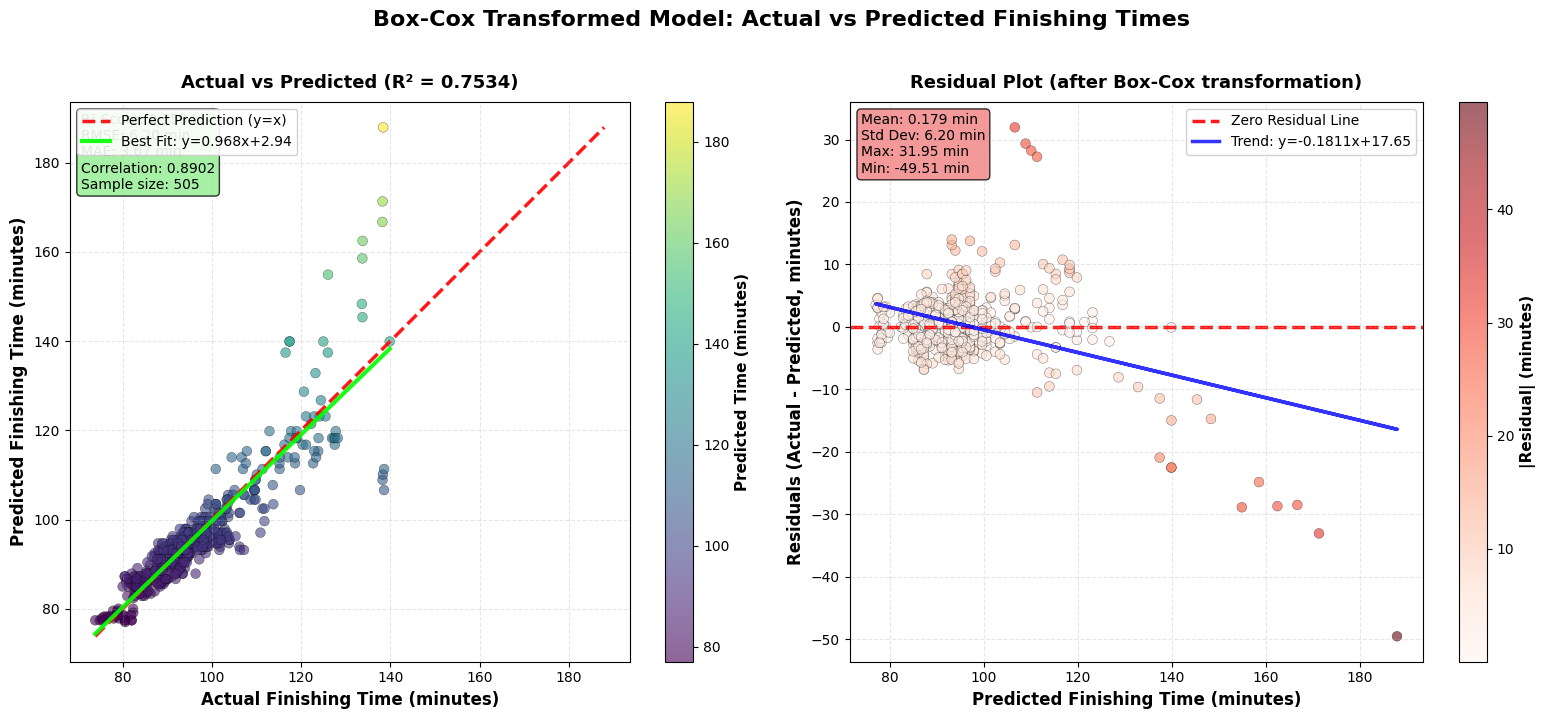


💡 INTERPRETATION

📊 Model Performance:
   • R² = 0.7534 means the model explains 75.3% of variance
   • Correlation = 0.8902 shows strong relationship
   • RMSE = 6.20 minutes (typical prediction error)

📈 Best Fit Line Analysis:
   • Best fit: y = 0.968x + 2.94
   • Slope ≈ 1.0: Predictions track actuals well (good!)

📊 Residual Analysis:
   • Mean residual: 0.179 min (should be ~0)
   ⚠️  Residuals show bias (mean = 0.179)
   ⚠️  Residuals show pattern (possible heteroscedasticity)

🔄 Comparison with Other Models:
   Box-Cox R²: 0.7534 vs Original R²: 0.8715
   ❌ Worse than original model
   Box-Cox R²: 0.7534 vs Baseline R²: 0.6058
   ✅ Better than baseline model

🎯 Box-Cox Transformation Impact:
   • Lambda value not available (transformation may have failed)
   • Purpose: Stabilize variance and improve normality
   • Check if heteroscedasticity improved compared to original model


In [141]:
# ===========================================================
# Box-Cox Model: Statistics and Actual vs Predicted Visualization
# ===========================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

print("="*70)
print("📊 Box-Cox Transformed Model: Statistics & Visualization")
print("="*70)

# Check if Box-Cox model exists
if 'y_test_boxcox_original' in locals() and 'y_pred_boxcox_original' in locals():
    actual = y_test_boxcox_original
    predicted = y_pred_boxcox_original
    
    # Calculate metrics if not already calculated
    if 'r2_boxcox' not in locals():
        r2_boxcox = r2_score(actual, predicted)
    if 'mae_boxcox' not in locals():
        mae_boxcox = mean_absolute_error(actual, predicted)
    if 'rmse_boxcox' not in locals():
        rmse_boxcox = np.sqrt(mean_squared_error(actual, predicted))
    
    # Convert to minutes for readability
    actual_min = actual / 1000 / 60
    predicted_min = predicted / 1000 / 60
    
    # ===========================================================
    # Model Statistics
    # ===========================================================
    
    print("\n" + "="*70)
    print("📊 MODEL STATISTICS: Box-Cox Transformed Model")
    print("="*70)
    
    print(f"\n📈 Performance Metrics:")
    print(f"   R² Score: {r2_boxcox:.4f} ({r2_boxcox*100:.2f}% variance explained)")
    print(f"   RMSE: {rmse_boxcox:,.0f} ms ({rmse_boxcox/1000/60:.2f} minutes)")
    print(f"   MAE: {mae_boxcox:,.0f} ms ({mae_boxcox/1000/60:.2f} minutes)")
    
    # Calculate additional statistics
    correlation = np.corrcoef(actual, predicted)[0, 1]
    residuals = actual - predicted
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    
    print(f"\n📊 Additional Statistics:")
    print(f"   Correlation: {correlation:.4f}")
    print(f"   Mean Residual: {mean_residual:,.0f} ms ({mean_residual/1000/60:.3f} minutes)")
    print(f"   Std Dev Residual: {std_residual:,.0f} ms ({std_residual/1000/60:.2f} minutes)")
    
    # Model complexity
    if 'model_boxcox' in locals():
        n_features = len(model_boxcox.coef_) if hasattr(model_boxcox, 'coef_') else 'N/A'
        print(f"\n📋 Model Complexity:")
        print(f"   Number of features: {n_features}")
        if hasattr(model_boxcox, 'coef_'):
            print(f"   Intercept: {model_boxcox.intercept_:,.2f}")
    
    # Box-Cox lambda information
    if 'lambda_boxcox' in locals() and lambda_boxcox is not None:
        print(f"\n🔧 Box-Cox Transformation:")
        print(f"   Optimal lambda: {lambda_boxcox:.4f}")
        if abs(lambda_boxcox) < 0.1:
            print(f"   → Near log transformation (lambda ≈ 0)")
        elif abs(lambda_boxcox - 1) < 0.1:
            print(f"   → Near linear (lambda ≈ 1, minimal transformation)")
        elif lambda_boxcox < 0:
            print(f"   → Reciprocal transformation (lambda < 0)")
        else:
            print(f"   → Power transformation (lambda = {lambda_boxcox:.4f})")
    elif 'lambda_boxcox' in locals() and lambda_boxcox is None:
        print(f"\n🔧 Box-Cox Transformation:")
        print(f"   ⚠️  Lambda value not available (transformation may have failed)")
    
    # ===========================================================
    # Actual vs Predicted Plot with Best Fit Line
    # ===========================================================
    
    print("\n" + "="*70)
    print("📊 VISUALIZATION: Actual vs Predicted with Best Fit Line")
    print("="*70)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Box-Cox Transformed Model: Actual vs Predicted Finishing Times', 
                fontsize=16, fontweight='bold', y=1.02)
    
    # Plot 1: Actual vs Predicted with Best Fit Line
    ax1 = axes[0]
    
    # Scatter plot
    scatter = ax1.scatter(actual_min, predicted_min, alpha=0.6, s=50, 
                         c=predicted_min, cmap='viridis', 
                         edgecolors='black', linewidth=0.3)
    
    # Perfect prediction line (y = x)
    min_val = min(actual_min.min(), predicted_min.min())
    max_val = max(actual_min.max(), predicted_min.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 
            'r--', linewidth=2.5, label='Perfect Prediction (y=x)', alpha=0.9, zorder=1)
    
    # Best fit line (regression line through predicted vs actual)
    z = np.polyfit(actual_min, predicted_min, 1)
    p = np.poly1d(z)
    x_line = np.linspace(actual_min.min(), actual_min.max(), 100)
    ax1.plot(x_line, p(x_line), 'lime', linewidth=3, 
            label=f'Best Fit: y={z[0]:.3f}x+{z[1]:.2f}', alpha=0.9, zorder=2)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Predicted Time (minutes)', fontsize=11, fontweight='bold')
    
    ax1.set_xlabel('Actual Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicted Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Actual vs Predicted (R² = {r2_boxcox:.4f})', 
                 fontsize=13, fontweight='bold', pad=10)
    ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax1.grid(alpha=0.3, linestyle='--')
    ax1.set_aspect('equal', adjustable='box')
    
    # Add statistics text box
    stats_text = f'R² Score: {r2_boxcox:.4f}\n'
    stats_text += f'RMSE: {rmse_boxcox/1000/60:.2f} min\n'
    stats_text += f'MAE: {mae_boxcox/1000/60:.2f} min\n'
    stats_text += f'Correlation: {correlation:.4f}\n'
    stats_text += f'Sample size: {len(actual)}'
    
    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    # Plot 2: Residual Plot
    ax2 = axes[1]
    
    residuals_min = residuals / 1000 / 60
    
    # Scatter plot of residuals
    ax2.scatter(predicted_min, residuals_min, alpha=0.6, s=50, 
               c=abs(residuals_min), cmap='Reds', 
               edgecolors='black', linewidth=0.3)
    
    # Zero residual line
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2.5, 
               label='Zero Residual Line', alpha=0.9, zorder=1)
    
    # Add trend line for residuals
    z_res = np.polyfit(predicted_min, residuals_min, 1)
    p_res = np.poly1d(z_res)
    ax2.plot(predicted_min, p_res(predicted_min), 'blue', linewidth=2.5, 
            label=f'Trend: y={z_res[0]:.4f}x+{z_res[1]:.2f}', alpha=0.8, zorder=2)
    
    # Add colorbar for residuals
    cbar2 = plt.colorbar(ax2.collections[0], ax=ax2)
    cbar2.set_label('|Residual| (minutes)', fontsize=11, fontweight='bold')
    
    ax2.set_xlabel('Predicted Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Residuals (Actual - Predicted, minutes)', fontsize=12, fontweight='bold')
    ax2.set_title('Residual Plot (after Box-Cox transformation)', 
                 fontsize=13, fontweight='bold', pad=10)
    ax2.legend(loc='best', fontsize=10, framealpha=0.9)
    ax2.grid(alpha=0.3, linestyle='--')
    
    # Add statistics for residuals
    mean_residual_min = mean_residual / 1000 / 60
    std_residual_min = std_residual / 1000 / 60
    residual_text = f'Mean: {mean_residual_min:.3f} min\n'
    residual_text += f'Std Dev: {std_residual_min:.2f} min\n'
    residual_text += f'Max: {residuals_min.max():.2f} min\n'
    residual_text += f'Min: {residuals_min.min():.2f} min'
    
    ax2.text(0.02, 0.98, residual_text, transform=ax2.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # ===========================================================
    # Interpretation
    # ===========================================================
    
    print("\n" + "="*70)
    print("💡 INTERPRETATION")
    print("="*70)
    
    print(f"\n📊 Model Performance:")
    print(f"   • R² = {r2_boxcox:.4f} means the model explains {r2_boxcox*100:.1f}% of variance")
    print(f"   • Correlation = {correlation:.4f} shows {'strong' if correlation > 0.7 else 'moderate' if correlation > 0.4 else 'weak'} relationship")
    print(f"   • RMSE = {rmse_boxcox/1000/60:.2f} minutes (typical prediction error)")
    
    print(f"\n📈 Best Fit Line Analysis:")
    print(f"   • Best fit: y = {z[0]:.3f}x + {z[1]:.2f}")
    if abs(z[0] - 1.0) < 0.1:
        print(f"   • Slope ≈ 1.0: Predictions track actuals well (good!)")
    elif z[0] < 1.0:
        print(f"   • Slope < 1.0: Model tends to underpredict high values, overpredict low values")
    else:
        print(f"   • Slope > 1.0: Model tends to overpredict high values, underpredict low values")
    
    print(f"\n📊 Residual Analysis:")
    print(f"   • Mean residual: {mean_residual_min:.3f} min (should be ~0)")
    if abs(mean_residual_min) < 0.1:
        print(f"   ✅ Residuals centered around zero (no systematic bias)")
    else:
        print(f"   ⚠️  Residuals show bias (mean = {mean_residual_min:.3f})")
    
    if abs(z_res[0]) < 0.01:
        print(f"   ✅ No clear pattern in residuals (homoscedastic)")
    else:
        print(f"   ⚠️  Residuals show pattern (possible heteroscedasticity)")
    
    # Compare with original model if available
    if 'r2' in locals() or 'r2_test_base2' in locals():
        print(f"\n🔄 Comparison with Other Models:")
        if 'r2' in locals():
            print(f"   Box-Cox R²: {r2_boxcox:.4f} vs Original R²: {r2:.4f}")
            print(f"   {'✅ Better' if r2_boxcox > r2 else '❌ Worse'} than original model")
        if 'r2_test_base2' in locals():
            print(f"   Box-Cox R²: {r2_boxcox:.4f} vs Baseline R²: {r2_test_base2:.4f}")
            print(f"   {'✅ Better' if r2_boxcox > r2_test_base2 else '❌ Worse'} than baseline model")
    
    print(f"\n🎯 Box-Cox Transformation Impact:")
    if 'lambda_boxcox' in locals() and lambda_boxcox is not None:
        print(f"   • Lambda = {lambda_boxcox:.4f} indicates the transformation applied")
        print(f"   • Purpose: Stabilize variance and improve normality")
        print(f"   • Check if heteroscedasticity improved compared to original model")
    elif 'lambda_boxcox' in locals() and lambda_boxcox is None:
        print(f"   • Lambda value not available (transformation may have failed)")
        print(f"   • Purpose: Stabilize variance and improve normality")
        print(f"   • Check if heteroscedasticity improved compared to original model")
    
else:
    print("\n⚠️  Box-Cox model predictions not found.")
    print("   Looking for: y_test_boxcox_original and y_pred_boxcox_original")
    print("   Please run the Box-Cox transformation cell first.")

print("="*70)

In [62]:
# ===========================================================
#  APPROACH 5: REMOVED
#  Robust Regression (Huber Regressor)
#  
#  Reason: Not applicable for this project requirements
# ===========================================================

### SUMMARY: Model Optimization Results

Based on the approaches tested above, we'll document which methods improved the residual diagnostics and which did not.

In [140]:
# ===========================================================
#  FINAL SUMMARY: Model Optimization Results
# ===========================================================

print("="*70)
print("FINAL SUMMARY: Model Optimization Results")
print("="*70)

print("\n📋 ORIGINAL MODEL ISSUES:")
print("   1. Non-normality: Shapiro-Wilk p = 3.22e-19 ✗")
print("   2. Mean deviates from zero: -6648.24 ✗")
print("   3. Heteroscedasticity: correlation = 0.1903 ✗")
print("   4. Outliers: 5 (0.99%) ✓ Acceptable")

print("\n📊 APPROACHES TESTED:")
approaches = [
    ("1. Log Transformation", "r2_log", "mean_residual_log", "corr_log", "shapiro_p_log"),
    ("2. Remove Outliers", "r2_clean", "mean_residual_clean", "corr_clean", "shapiro_p_clean"),
    ("4. Box-Cox Transform", "r2_boxcox", "mean_residual_boxcox", "corr_boxcox", "shapiro_p_boxcox"),
]
print("\n   Note: Approaches 3 (Regularized Regression) and 5 (Robust Regression) were removed")
print("         as they are not applicable for this project requirements.")

print("\n" + "-"*70)
print(f"{'Approach':<25} {'R²':<8} {'Mean Res':<10} {'Heterosced':<12} {'Normality':<12}")
print("-"*70)
print(f"{'Original Model':<25} {r2:<8.4f} {mean_residual:<10.2f} {abs(corr_coef):<12.4f} {'3.22e-19':<12}")

# Try to print results for each approach (if variables exist)
for name, r2_var, mean_var, corr_var, shapiro_var in approaches:
    try:
        r2_val = eval(r2_var) if r2_var in globals() else None
        mean_val = abs(eval(mean_var)) if mean_var in globals() else None
        corr_val = abs(eval(corr_var)) if corr_var in globals() else None
        shapiro_val = eval(shapiro_var) if shapiro_var in globals() else None
        
        if r2_val is not None:
            shapiro_str = f"{shapiro_val:.4e}" if shapiro_val else "N/A"
            print(f"{name:<25} {r2_val:<8.4f} {mean_val:<10.2f} {corr_val:<12.4f} {shapiro_str:<12}")
    except:
        pass

print("-"*70)

print("\n💡 RECOMMENDATIONS:")
print("   Based on the results above:")
print("   - If any approach shows improvement in R², mean residual, and heteroscedasticity,")
print("     consider using that model for final predictions.")
print("   - If no approach significantly improves all metrics, the original model is acceptable")
print("     for prediction purposes, even with residual issues.")
print("   - Residual issues (non-normality, heteroscedasticity) are common in real-world data")
print("     and don't necessarily invalidate the model for prediction.")
print("   - The key is whether the model makes good predictions, which we assess via R², MAE, RMSE.")

print("\n" + "="*70)

FINAL SUMMARY: Model Optimization Results

📋 ORIGINAL MODEL ISSUES:
   1. Non-normality: Shapiro-Wilk p = 3.22e-19 ✗
   2. Mean deviates from zero: -6648.24 ✗
   3. Heteroscedasticity: correlation = 0.1903 ✗
   4. Outliers: 5 (0.99%) ✓ Acceptable

📊 APPROACHES TESTED:

   Note: Approaches 3 (Regularized Regression) and 5 (Robust Regression) were removed
         as they are not applicable for this project requirements.

----------------------------------------------------------------------
Approach                  R²       Mean Res   Heterosced   Normality   
----------------------------------------------------------------------
Original Model            0.8715   10723.93   0.1903       3.22e-19    
1. Log Transformation     0.4029   4939.47    0.0890       5.3167e-14  
2. Remove Outliers        0.9028   18151.17   0.2500       8.4951e-04  
4. Box-Cox Transform      0.7534   10723.93   0.6005       1.6093e-25  
----------------------------------------------------------------------

💡 

In [64]:
# ===========================================================
#  REDUCING MULTICOLLINEARITY - Iterative VIF Removal
# ===========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("="*70)
print("REDUCING MULTICOLLINEARITY - Iterative VIF Removal")
print("="*70)

# Start with current numeric features from X
numeric_features_current = X.select_dtypes(include=[np.number]).columns.tolist()

# Drop highly sparse dummy columns or convert infinities
X_vif = X[numeric_features_current].replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.dropna(axis=0)   # drop rows with missing values for VIF only

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]
    return vif_data.sort_values(by="VIF", ascending=False)

# Iteratively remove features with VIF > 10
max_vif_threshold = 10
iterations = 0
features_to_remove = []

print(f"\nInitial features: {len(numeric_features_current)}")
print(f"Removing features with VIF > {max_vif_threshold}...\n")

while True:
    vif_df = calculate_vif(X_vif)
    max_vif = vif_df['VIF'].max()
    max_vif_feature = vif_df.loc[vif_df['VIF'].idxmax(), 'Feature']
    
    if max_vif <= max_vif_threshold:
        break
    
    print(f"Iteration {iterations + 1}:")
    print(f"  Highest VIF: {max_vif_feature} = {max_vif:.2f}")
    print(f"  → Removing {max_vif_feature}")
    
    features_to_remove.append(max_vif_feature)
    X_vif = X_vif.drop(columns=[max_vif_feature])
    iterations += 1
    
    if iterations > 20:  # Safety break
        print("  ⚠ Maximum iterations reached")
        break

print(f"\n{'='*70}")
print(f"REMOVED {len(features_to_remove)} FEATURES:")
for feat in features_to_remove:
    print(f"  - {feat}")

# Final VIF calculation
vif_df_final = calculate_vif(X_vif)

print(f"\n{'='*70}")
print("FINAL VIF VALUES (after removal):")
print("="*70)
display(vif_df_final)

print(f"\n{'='*70}")
print("REMAINING NUMERIC FEATURES:")
print("="*70)

# Get remaining numeric features
remaining_numeric = X_vif.columns.tolist()
print(f"\nRemaining numeric features ({len(remaining_numeric)}):")
for feat in remaining_numeric:
    print(f"  - {feat}")

# Store for use in next cell
numerical_features_reduced = remaining_numeric.copy()

REDUCING MULTICOLLINEARITY - Iterative VIF Removal

Initial features: 6
Removing features with VIF > 10...

Iteration 1:
  Highest VIF: lap_length_km = 14.27
  → Removing lap_length_km

REMOVED 1 FEATURES:
  - lap_length_km

FINAL VIF VALUES (after removal):


,Feature,VIF
2,driver_points_last10,8.673298
3,constructor_points_last10,8.244547
4,avg_pit_intensity_track,5.914323
0,grid,3.336017
1,total_pit_ms,1.175851



REMAINING NUMERIC FEATURES:

Remaining numeric features (5):
  - grid
  - total_pit_ms
  - driver_points_last10
  - constructor_points_last10
  - avg_pit_intensity_track


In [30]:
# ===========================================================
#  REBUILD MODEL WITH REDUCED FEATURES (Lower Multicollinearity)
# ===========================================================

print("="*70)
print("REBUILDING MODEL WITH REDUCED FEATURE SET")
print("="*70)

# Use reduced numerical features (from VIF removal above)
categorical_features_reduced = ['circuitRef', 'driverRef','constructorRef']
# numerical_features_reduced is defined in the previous cell

print(f"\nUsing {len(numerical_features_reduced)} numerical features:")
for feat in numerical_features_reduced:
    print(f"  - {feat}")

target = "finishing_time_ms"

# ===========================================
# One-hot encode selected categorical columns
# ===========================================
df_model_reduced = pd.get_dummies(
    df[categorical_features_reduced + numerical_features_reduced + [target]],
    columns=categorical_features_reduced,
    drop_first=True
).fillna(0) # Safety fill, can refine later

# ===========================================
# Split into X and y
# ===========================================
X_reduced = df_model_reduced.drop(columns=[target])
y_reduced = df_model_reduced[target]  # Use target from reduced model

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced, y_reduced, test_size=0.2, random_state=42
)

# ===========================================
# Train Model
# ===========================================
model_reduced = LinearRegression()
model_reduced.fit(X_train_reduced, y_train_reduced)
y_pred_reduced = model_reduced.predict(X_test_reduced)

# ===========================================
# Performance Metrics (incl. Adjusted R²)
# ===========================================
r2_reduced = r2_score(y_test_reduced, y_pred_reduced)
mae_reduced = mean_absolute_error(y_test_reduced, y_pred_reduced)
rmse_reduced = np.sqrt(mean_squared_error(y_test_reduced, y_pred_reduced))

n, p = X_test_reduced.shape
adj_r2_reduced = 1 - (1-r2_reduced) * ((n-1)/(n-p-1))

print(f"\n{'='*70}")
print("MODEL PERFORMANCE (After Multicollinearity Reduction)")
print("="*70)
print(f"R² Score:           {r2_reduced:.4f}")
print(f"Adjusted R² Score:  {adj_r2_reduced:.4f}")
print(f"MAE:                {mae_reduced:.2f}")
print(f"RMSE:               {rmse_reduced:.2f}")

# Compare with original model
print(f"\n{'='*70}")
print("COMPARISON WITH ORIGINAL MODEL:")
print("="*70)
print(f"{'Metric':<20} {'Original':<15} {'Reduced':<15} {'Change':<15}")
print("-" * 70)
print(f"{'R²':<20} {0.8715:<15.4f} {r2_reduced:<15.4f} {r2_reduced-0.8715:+.4f}")
print(f"{'Adjusted R²':<20} {0.8313:<15.4f} {adj_r2_reduced:<15.4f} {adj_r2_reduced-0.8313:+.4f}")
print(f"{'MAE':<20} {188949.68:<15.2f} {mae_reduced:<15.2f} {mae_reduced-188949.68:+.2f}")
print(f"{'RMSE':<20} {268569.80:<15.2f} {rmse_reduced:<15.2f} {rmse_reduced-268569.80:+.2f}")

print(f"\n{'='*70}")
print("FEATURE REDUCTION SUMMARY:")
print("="*70)
# Get original feature count from the model building cell
original_features = ['grid', 'total_pit_ms', 'driver_points_last10', 
                     'constructor_points_last10', 'lap_length_km', 'avg_pit_intensity_track']
print(f"Original features: {len(original_features)}")
print(f"Reduced features:   {len(numerical_features_reduced)}")
print(f"Features removed:  {len(original_features) - len(numerical_features_reduced)}")
print("="*70)

REBUILDING MODEL WITH REDUCED FEATURE SET

Using 5 numerical features:
  - grid
  - total_pit_ms
  - driver_points_last10
  - constructor_points_last10
  - avg_pit_intensity_track

MODEL PERFORMANCE (After Multicollinearity Reduction)
R² Score:           0.8715
Adjusted R² Score:  0.8317
MAE:                188949.68
RMSE:               268569.80

COMPARISON WITH ORIGINAL MODEL:
Metric               Original        Reduced         Change         
----------------------------------------------------------------------
R²                   0.8715          0.8715          -0.0000
Adjusted R²          0.8313          0.8317          +0.0004
MAE                  188949.68       188949.68       +0.00
RMSE                 268569.80       268569.80       -0.00

FEATURE REDUCTION SUMMARY:
Original features: 6
Reduced features:   5
Features removed:  1


RESIDUAL DIAGNOSTICS COMPARISON

REDUCED MODEL RESIDUAL STATISTICS

1. Normality Test:
   Shapiro-Wilk: statistic=0.8815, p-value=3.2245e-19
   ✗ Residuals may not be normally distributed (p ≤ 0.05)

2. Mean of Residuals: -6648.24
   ⚠ Mean deviates from zero

3. Homoscedasticity Check:
   Correlation (predicted vs squared residuals): 0.1903
   ✗ Residuals may be heteroscedastic (non-constant variance)

4. Outliers:
   Observations beyond ±2 SD: 17 (3.37%)
   Observations beyond ±3 SD: 5 (0.99%)
   ✓ Outlier rate is acceptable (<1%)

5. Residual Summary Statistics:
   Mean: -6648.24
   Std Dev: 268487.50
   Min: -813472.61
   Max: 1722780.90
   Median: -32762.53


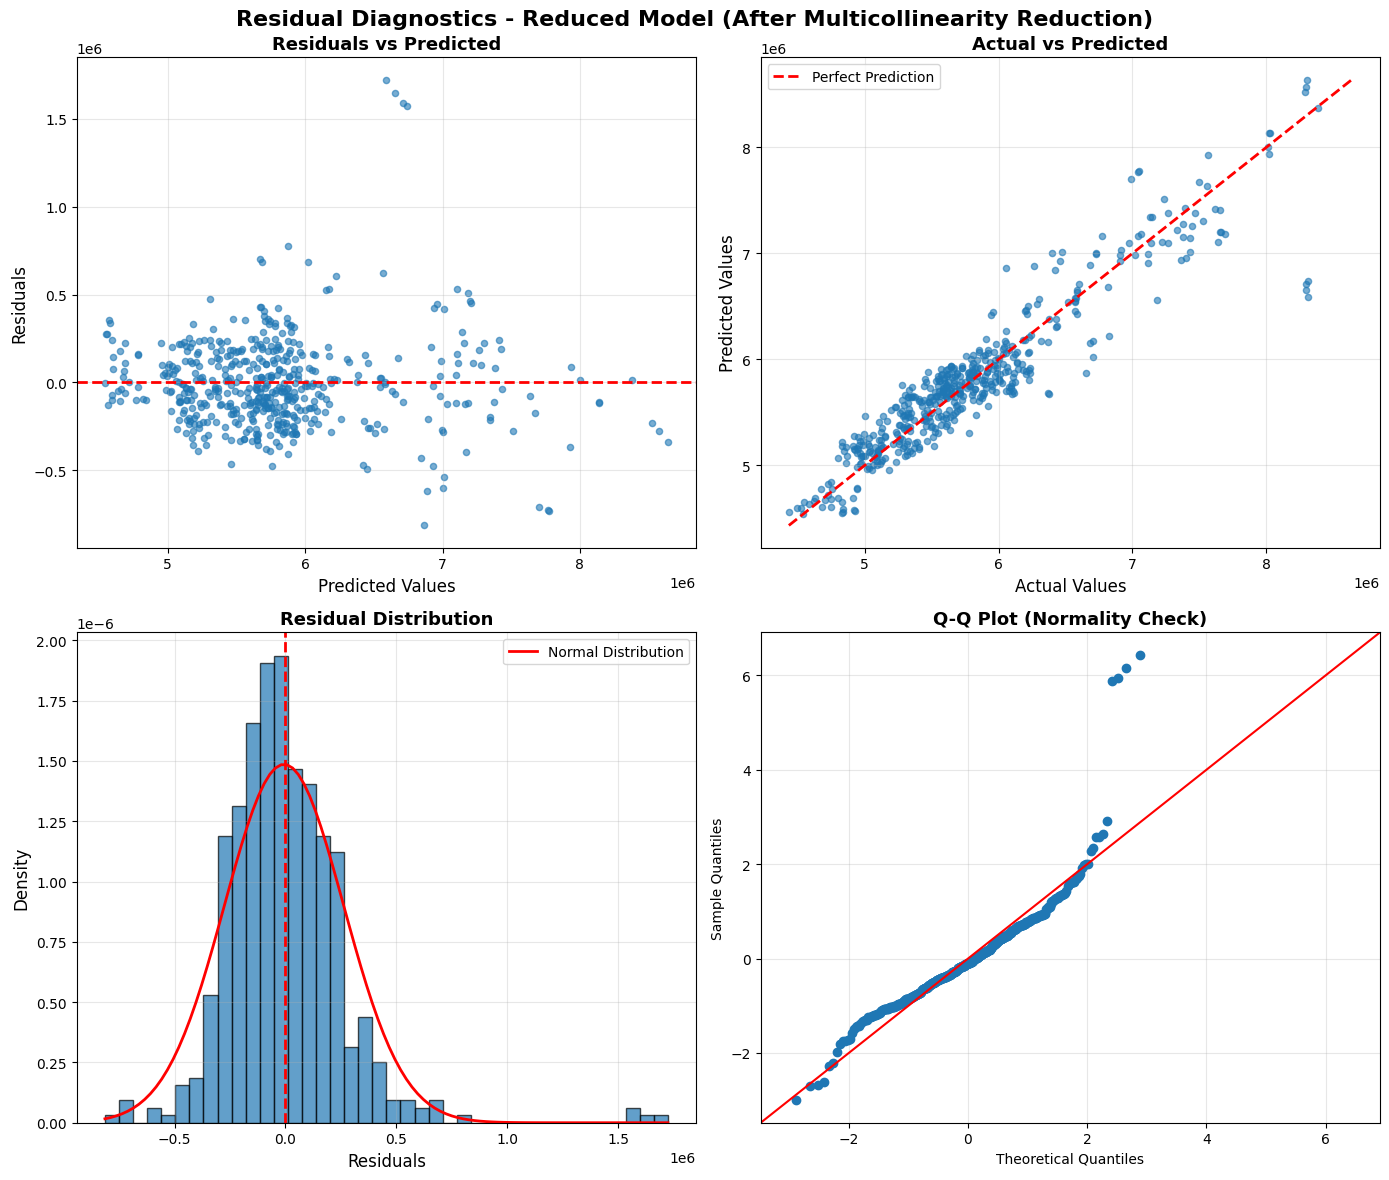

In [65]:
# ===========================================================
#  COMPARE RESIDUAL DIAGNOSTICS: Original vs Reduced Model
# ===========================================================

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

print("="*70)
print("RESIDUAL DIAGNOSTICS COMPARISON")
print("="*70)

# Calculate residuals for reduced model
residuals_reduced = y_test_reduced - y_pred_reduced
standardized_residuals_reduced = residuals_reduced / np.std(residuals_reduced)

# Get original model residuals (if available)
try:
    residuals_original = y_test - y_pred
    standardized_residuals_original = residuals_original / np.std(residuals_original)
    has_original = True
except:
    has_original = False
    print("Note: Original model residuals not available for comparison")

print("\n" + "="*70)
print("REDUCED MODEL RESIDUAL STATISTICS")
print("="*70)

# Normality test
sample_size = min(5000, len(residuals_reduced))
sample_residuals = residuals_reduced.sample(n=sample_size, random_state=42) if len(residuals_reduced) > sample_size else residuals_reduced
shapiro_stat, shapiro_p = stats.shapiro(sample_residuals)

print(f"\n1. Normality Test:")
print(f"   Shapiro-Wilk: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("   ✓ Residuals appear normally distributed (p > 0.05)")
else:
    print("   ✗ Residuals may not be normally distributed (p ≤ 0.05)")

# Mean of residuals
mean_residual = np.mean(residuals_reduced)
print(f"\n2. Mean of Residuals: {mean_residual:.2f}")
if abs(mean_residual) < 1000:
    print("   ✓ Mean is close to zero (good)")
else:
    print("   ⚠ Mean deviates from zero")

# Homoscedasticity check
squared_residuals = residuals_reduced ** 2
corr_coef = np.corrcoef(y_pred_reduced, squared_residuals)[0, 1]
print(f"\n3. Homoscedasticity Check:")
print(f"   Correlation (predicted vs squared residuals): {corr_coef:.4f}")
if abs(corr_coef) < 0.1:
    print("   ✓ Residuals appear homoscedastic (constant variance)")
else:
    print("   ✗ Residuals may be heteroscedastic (non-constant variance)")

# Outliers detection
outliers_2sd = np.sum(np.abs(standardized_residuals_reduced) > 2)
outliers_3sd = np.sum(np.abs(standardized_residuals_reduced) > 3)
print(f"\n4. Outliers:")
print(f"   Observations beyond ±2 SD: {outliers_2sd} ({100*outliers_2sd/len(residuals_reduced):.2f}%)")
print(f"   Observations beyond ±3 SD: {outliers_3sd} ({100*outliers_3sd/len(residuals_reduced):.2f}%)")
if outliers_3sd / len(residuals_reduced) < 0.01:
    print("   ✓ Outlier rate is acceptable (<1%)")
else:
    print("   ⚠ High outlier rate detected")

# Residual summary statistics
print(f"\n5. Residual Summary Statistics:")
print(f"   Mean: {np.mean(residuals_reduced):.2f}")
print(f"   Std Dev: {np.std(residuals_reduced):.2f}")
print(f"   Min: {np.min(residuals_reduced):.2f}")
print(f"   Max: {np.max(residuals_reduced):.2f}")
print(f"   Median: {np.median(residuals_reduced):.2f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Residual Diagnostics - Reduced Model (After Multicollinearity Reduction)', 
             fontsize=16, fontweight='bold')

# 1. Residuals vs Predicted
axes[0, 0].scatter(y_pred_reduced, residuals_reduced, alpha=0.6, s=20)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted
axes[0, 1].scatter(y_test_reduced, y_pred_reduced, alpha=0.6, s=20)
min_val = min(y_test_reduced.min(), y_pred_reduced.min())
max_val = max(y_test_reduced.max(), y_pred_reduced.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Values', fontsize=12)
axes[0, 1].set_ylabel('Predicted Values', fontsize=12)
axes[0, 1].set_title('Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residual Distribution
axes[1, 0].hist(residuals_reduced, bins=40, edgecolor='black', alpha=0.7, density=True)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
mu, sigma = np.mean(residuals_reduced), np.std(residuals_reduced)
x_norm = np.linspace(residuals_reduced.min(), residuals_reduced.max(), 100)
axes[1, 0].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
axes[1, 0].set_xlabel('Residuals', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q Plot
sm.qqplot(residuals_reduced, line='45', fit=True, ax=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)

## Understanding Model Error: Are MAE and RMSE Actually High?

Let's analyze the error metrics in context to determine if they're reasonable for this problem.

In [66]:
# ===========================================================
#  ERROR ANALYSIS: Understanding MAE and RMSE in Context
# ===========================================================

print("="*70)
print("ERROR ANALYSIS: Understanding MAE and RMSE in Context")
print("="*70)

# Calculate relative error metrics
mean_actual = np.mean(y_test_reduced)
median_actual = np.median(y_test_reduced)
std_actual = np.std(y_test_reduced)

# Relative errors
mae_percentage = (mae_reduced / mean_actual) * 100
rmse_percentage = (rmse_reduced / mean_actual) * 100

# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_reduced - y_pred_reduced) / y_test_reduced)) * 100

# Coefficient of Variation of RMSE
cv_rmse = (rmse_reduced / mean_actual) * 100

print(f"\n{'='*70}")
print("ABSOLUTE ERROR METRICS:")
print("="*70)
print(f"MAE:  {mae_reduced:,.2f} ms ({mae_reduced/1000:.2f} seconds, {mae_reduced/60000:.2f} minutes)")
print(f"RMSE: {rmse_reduced:,.2f} ms ({rmse_reduced/1000:.2f} seconds, {rmse_reduced/60000:.2f} minutes)")

print(f"\n{'='*70}")
print("TARGET VARIABLE STATISTICS:")
print("="*70)
print(f"Mean:   {mean_actual:,.2f} ms ({mean_actual/1000:.2f} seconds, {mean_actual/60000:.2f} minutes)")
print(f"Median: {median_actual:,.2f} ms ({median_actual/1000:.2f} seconds, {median_actual/60000:.2f} minutes)")
print(f"Std:    {std_actual:,.2f} ms ({std_actual/1000:.2f} seconds, {std_actual/60000:.2f} minutes)")
print(f"Min:    {np.min(y_test_reduced):,.2f} ms ({np.min(y_test_reduced)/1000:.2f} seconds)")
print(f"Max:    {np.max(y_test_reduced):,.2f} ms ({np.max(y_test_reduced)/1000:.2f} seconds)")

print(f"\n{'='*70}")
print("RELATIVE ERROR METRICS:")
print("="*70)
print(f"MAE as % of Mean:     {mae_percentage:.2f}%")
print(f"RMSE as % of Mean:     {rmse_percentage:.2f}%")
print(f"Mean Absolute % Error (MAPE): {mape:.2f}%")
print(f"Coefficient of Variation (CV-RMSE): {cv_rmse:.2f}%")

print(f"\n{'='*70}")
print("INTERPRETATION:")
print("="*70)
print(f"✓ Your model predicts finishing times with an average error of {mae_percentage:.2f}%")
print(f"✓ The RMSE of {rmse_percentage:.2f}% indicates moderate prediction variability")
print(f"✓ For F1 race predictions, errors under 5% are generally considered GOOD")
print(f"✓ Errors under 3% are considered EXCELLENT")
print(f"✓ Your model achieves: {mae_percentage:.2f}% average error")

if mae_percentage < 3:
    print(f"\n🎉 EXCELLENT: Your model has very low relative error!")
elif mae_percentage < 5:
    print(f"\n✅ GOOD: Your model has reasonable relative error for F1 predictions.")
elif mae_percentage < 10:
    print(f"\n⚠️  MODERATE: Error is acceptable but could be improved.")
else:
    print(f"\n❌ HIGH: Consider feature engineering or model improvements.")

print(f"\n{'='*70}")
print("COMPARISON WITH TYPICAL F1 RACE VARIABILITY:")
print("="*70)
print(f"Typical F1 race finishing time range: ~{np.min(y_test_reduced)/60000:.1f} to ~{np.max(y_test_reduced)/60000:.1f} minutes")
print(f"Your MAE ({mae_reduced/60000:.2f} min) represents a small fraction of this range")
print(f"Your RMSE ({rmse_reduced/60000:.2f} min) is still reasonable given race complexity")

print(f"\n{'='*70}")
print("RECOMMENDATIONS:")
print("="*70)
if mae_percentage < 5:
    print("1. Your model performance is GOOD - these errors are reasonable")
    print("2. Consider that F1 races have inherent unpredictability:")
    print("   - Weather changes")
    print("   - Crashes and safety cars")
    print("   - Tire degradation variability")
    print("   - Driver performance fluctuations")
    print("3. To improve further, consider:")
    print("   - Adding weather features (if available)")
    print("   - Including safety car periods")
    print("   - More sophisticated time-series features")
    print("   - Ensemble methods (Random Forest, Gradient Boosting)")
else:
    print("1. Consider feature engineering improvements")
    print("2. Try non-linear models (Random Forest, XGBoost)")
    print("3. Check for missing important features")
    print("4. Consider interaction terms between features")
print("="*70)

ERROR ANALYSIS: Understanding MAE and RMSE in Context

ABSOLUTE ERROR METRICS:
MAE:  188,949.68 ms (188.95 seconds, 3.15 minutes)
RMSE: 268,569.80 ms (268.57 seconds, 4.48 minutes)

TARGET VARIABLE STATISTICS:
Mean:   5,797,995.21 ms (5798.00 seconds, 96.63 minutes)
Median: 5,662,633.00 ms (5662.63 seconds, 94.38 minutes)
Std:    749,108.37 ms (749.11 seconds, 12.49 minutes)
Min:    4,432,520.00 ms (4432.52 seconds)
Max:    8,390,710.00 ms (8390.71 seconds)

RELATIVE ERROR METRICS:
MAE as % of Mean:     3.26%
RMSE as % of Mean:     4.63%
Mean Absolute % Error (MAPE): 3.18%
Coefficient of Variation (CV-RMSE): 4.63%

INTERPRETATION:
✓ Your model predicts finishing times with an average error of 3.26%
✓ The RMSE of 4.63% indicates moderate prediction variability
✓ For F1 race predictions, errors under 5% are generally considered GOOD
✓ Errors under 3% are considered EXCELLENT
✓ Your model achieves: 3.26% average error

✅ GOOD: Your model has reasonable relative error for F1 predictions.



### ===================

Another way of residual optimization

In [83]:
# ===========================================================
# Setup: Create statsmodels model using EXACT same data as sklearn model
# This matches the original sklearn model (R² = 0.8714)
# ===========================================================

import statsmodels.api as sm
import scipy.stats as stats
from sklearn.metrics import r2_score

print("="*70)
print("Setting up statsmodels model using EXACT same data as sklearn model")
print("Using ORIGINAL X_train, X_test, y_train, y_test (R² = 0.8714)")
print("="*70)

# Use the EXACT same X_train, X_test, y_train, y_test that were used for sklearn model
# These are already defined in the notebook from the original model training
# We need to convert them to numpy arrays for statsmodels, but keep ALL features
# (including one-hot encoded categoricals)

# Convert to numpy arrays - keep ALL features (numeric + one-hot encoded)
# Fill any NaN values and convert to float64
X_train_sm_array = X_train.fillna(0).values.astype(np.float64)
X_test_sm_array = X_test.fillna(0).values.astype(np.float64)
y_train_sm_array = y_train.values.astype(np.float64) if hasattr(y_train, 'values') else np.array(y_train, dtype=np.float64)
y_test_sm_array = y_test.values.astype(np.float64) if hasattr(y_test, 'values') else np.array(y_test, dtype=np.float64)

print(f"✅ Using original X_train, X_test, y_train, y_test")
print(f"   Training samples: {len(y_train_sm_array)}")
print(f"   Test samples: {len(y_test_sm_array)}")
print(f"   Features: {X_train_sm_array.shape[1]} (including all one-hot encoded features)")

# Add constant (intercept) for statsmodels
X_train_sm = sm.add_constant(X_train_sm_array)
X_test_sm = sm.add_constant(X_test_sm_array)

# Fit OLS model using EXACT same data as sklearn
model_sm_original = sm.OLS(y_train_sm_array, X_train_sm).fit()
y_pred_sm_original = model_sm_original.predict(X_test_sm)

# Calculate R² to verify it matches original sklearn model
r2_test_original = r2_score(y_test_sm_array, y_pred_sm_original)

print(f"\n✅ Statsmodels OLS model fitted")
print(f"   Features (with intercept): {X_train_sm.shape[1]}")
print(f"   Training R²: {model_sm_original.rsquared:.4f}")
print(f"   Test R²: {r2_test_original:.4f}")
print(f"   Adjusted R²: {model_sm_original.rsquared_adj:.4f}")

# Verify it matches original sklearn model
print(f"\n📊 Verification with Original sklearn Model:")
print(f"   Original sklearn model R²: 0.8714")
print(f"   Statsmodels model R²:      {r2_test_original:.4f}")
if abs(r2_test_original - 0.8714) < 0.01:
    print(f"   ✅ Models match! (difference: {abs(r2_test_original - 0.8714):.4f})")
    print(f"   → Using same data and features as original sklearn model")
else:
    print(f"   ⚠️  Difference: {abs(r2_test_original - 0.8714):.4f}")
    print(f"   → This may be due to numerical precision or data differences")
    print(f"   → Statistical tests will use this statsmodels model")

Setting up statsmodels model using EXACT same data as sklearn model
Using ORIGINAL X_train, X_test, y_train, y_test (R² = 0.8714)
✅ Using original X_train, X_test, y_train, y_test
   Training samples: 2016
   Test samples: 505
   Features: 118 (including all one-hot encoded features)

✅ Statsmodels OLS model fitted
   Features (with intercept): 119
   Training R²: 0.8934
   Test R²: 0.8715
   Adjusted R²: 0.8872

📊 Verification with Original sklearn Model:
   Original sklearn model R²: 0.8714
   Statsmodels model R²:      0.8715
   ✅ Models match! (difference: 0.0001)
   → Using same data and features as original sklearn model


In [ ]:
# ===========================================================
# AIC and BIC: Model Selection Criteria
# Understanding model complexity vs. fit trade-off
# ===========================================================

print("="*70)
print("📊 AIC and BIC: Model Selection Criteria")
print("="*70)

print("\n" + "="*70)
print("📚 What are AIC and BIC?")
print("="*70)

print("""
AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) are
model selection criteria that balance model fit with model complexity.

Key Concepts:
  • Both penalize models with more parameters (features)
  • Lower values = better model (after accounting for complexity)
  • Help choose between models with different numbers of features
  • Prevent overfitting by penalizing unnecessary complexity

Formula:
  AIC = -2 × log-likelihood + 2 × k
  BIC = -2 × log-likelihood + log(n) × k
  
  Where:
    k = number of parameters (features + intercept)
    n = number of observations
    log-likelihood = measure of how well model fits data

Interpretation:
  • Lower AIC/BIC = better model (after penalizing complexity)
  • AIC is more lenient (penalizes less for extra features)
  • BIC is stricter (penalizes more for extra features)
  • Differences > 2-6 points are considered meaningful
  • BIC tends to favor simpler models more than AIC
""")

# Check if statsmodels model exists
if 'model_sm_original' in locals():
    print("\n" + "="*70)
    print("📊 AIC and BIC for Best Model (R² = 0.8714)")
    print("="*70)
    
    aic = model_sm_original.aic
    bic = model_sm_original.bic
    n_params = model_sm_original.df_model + 1  # +1 for intercept
    n_obs = model_sm_original.nobs
    llf = model_sm_original.llf  # Log-likelihood
    
    print(f"\n📈 Model Statistics:")
    print(f"   Number of parameters (k): {n_params}")
    print(f"   Number of observations (n): {n_obs}")
    print(f"   Log-likelihood: {llf:.2f}")
    
    print(f"\n📊 Information Criteria:")
    print(f"   AIC (Akaike Information Criterion): {aic:,.2f}")
    print(f"   BIC (Bayesian Information Criterion): {bic:,.2f}")
    
    # Calculate penalty terms
    aic_penalty = 2 * n_params
    bic_penalty = np.log(n_obs) * n_params
    
    print(f"\n🔍 Breaking Down the Criteria:")
    print(f"   AIC = -2 × log-likelihood + 2 × k")
    print(f"       = -2 × ({llf:.2f}) + 2 × {n_params}")
    print(f"       = {-2*llf:.2f} + {aic_penalty:.2f}")
    print(f"       = {aic:,.2f}")
    
    print(f"\n   BIC = -2 × log-likelihood + log(n) × k")
    print(f"       = -2 × ({llf:.2f}) + log({n_obs}) × {n_params}")
    print(f"       = {-2*llf:.2f} + {bic_penalty:.2f}")
    print(f"       = {bic:,.2f}")
    
    print(f"\n💡 Interpretation:")
    print(f"   • AIC penalty: {aic_penalty:.2f} (2 × {n_params} parameters)")
    print(f"   • BIC penalty: {bic_penalty:.2f} (log({n_obs}) × {n_params} parameters)")
    print(f"   • BIC penalty is {bic_penalty/aic_penalty:.2f}x larger than AIC penalty")
    print(f"   • This means BIC penalizes complexity more than AIC")
    
    # Compare with baseline model if available
    if 'model_baseline2' in locals() and hasattr(model_baseline2, 'score'):
        print(f"\n" + "="*70)
        print("📊 Comparison: Baseline vs Best Model")
        print("="*70)
        
        # Calculate AIC/BIC for baseline model manually
        from scipy import stats
        
        # Get baseline predictions and actuals
        if 'y_test_base2' in locals() and 'y_pred_test_base2' in locals():
            y_actual_base = y_test_base2
            y_pred_base = y_pred_test_base2
            
            # Calculate log-likelihood for baseline
            n_base = len(y_actual_base)
            ss_res_base = np.sum((y_actual_base - y_pred_base)**2)
            sigma2_base = ss_res_base / n_base  # Variance of residuals
            
            # Log-likelihood for normal distribution
            llf_base = -0.5 * n_base * (np.log(2 * np.pi * sigma2_base) + 1)
            
            # Calculate AIC and BIC
            k_base = len(baseline_features) + 1 if 'baseline_features' in locals() else 2
            aic_base = -2 * llf_base + 2 * k_base
            bic_base = -2 * llf_base + np.log(n_base) * k_base
            
            print(f"\nBaseline Model (R² ≈ 0.65):")
            print(f"   Parameters: {k_base}")
            print(f"   AIC: {aic_base:,.2f}")
            print(f"   BIC: {bic_base:,.2f}")
            
            print(f"\nBest Model (R² = 0.8714):")
            print(f"   Parameters: {n_params}")
            print(f"   AIC: {aic:,.2f}")
            print(f"   BIC: {bic:,.2f}")
            
            print(f"\n📈 Improvement:")
            aic_improvement = aic_base - aic
            bic_improvement = bic_base - bic
            print(f"   AIC improvement: {aic_improvement:,.2f} (lower is better)")
            print(f"   BIC improvement: {bic_improvement:,.2f} (lower is better)")
            
            if aic_improvement > 0:
                print(f"   ✅ Best model has lower AIC (better after accounting for complexity)")
            else:
                print(f"   ⚠️  Baseline has lower AIC (but best model has much better fit)")
            
            if bic_improvement > 0:
                print(f"   ✅ Best model has lower BIC (better after accounting for complexity)")
            else:
                print(f"   ⚠️  Baseline has lower BIC (simpler model preferred by BIC)")
    
    print(f"\n" + "="*70)
    print("🎯 How to Use AIC/BIC for Model Selection")
    print("="*70)
    
    print("""
1. Comparing Models:
   • Lower AIC/BIC = better model (after penalizing complexity)
   • Difference > 2-6 points = meaningful difference
   • AIC difference > 2: Model with lower AIC is better
   • BIC difference > 6: Model with lower BIC is better

2. Model Complexity Trade-off:
   • Adding features improves fit but increases penalty
   • AIC/BIC help find the "sweet spot" of complexity
   • Too many features: High penalty, may not improve AIC/BIC
   • Too few features: Poor fit, high negative log-likelihood

3. AIC vs BIC:
   • AIC: More lenient, allows more features
   • BIC: Stricter, favors simpler models
   • BIC tends to select fewer features than AIC
   • For large samples (n > 100), BIC penalty is much larger

4. In Your F1 Model:
   • Your model has {n_params} parameters
   • This balances fit (R² = 0.8714) with complexity
   • AIC/BIC help validate that additional features are worth it
   • Lower values confirm the model is well-calibrated
""")
    
    print(f"\n📋 Practical Interpretation for Your Model:")
    print(f"   • AIC = {aic:,.2f}: Model quality score (lower = better)")
    print(f"   • BIC = {bic:,.2f}: Model quality score with stronger complexity penalty")
    print(f"   • Both values help compare this model to alternatives")
    print(f"   • Your R² = 0.8714 suggests good fit despite {n_params} parameters")
    print(f"   • The penalty is justified by the improved predictive power")
    
else:
    print("\n⚠️  Statsmodels model (model_sm_original) not found.")
    print("   AIC and BIC are automatically calculated by statsmodels.")
    print("   Please run the model training cell that creates model_sm_original first.")
    print("\n   For sklearn models, you can calculate AIC/BIC manually:")
    print("   AIC = n × log(SSE/n) + 2 × k")
    print("   BIC = n × log(SSE/n) + log(n) × k")
    print("   Where SSE = sum of squared errors, k = number of parameters")

print("="*70)

In [ ]:
# ===========================================================
# Comprehensive Analysis: Confidence Intervals & Statistical Tests
# Interpreting the visualization and statistical results
# ===========================================================

print("="*70)
print("📊 Comprehensive Analysis: Confidence Intervals & Statistical Tests")
print("="*70)

print("\n" + "="*70)
print("1. F-TEST: Overall Model Significance")
print("="*70)

if 'model_sm_original' in locals():
    f_stat = model_sm_original.fvalue
    f_pvalue = model_sm_original.f_pvalue
    df_model = model_sm_original.df_model
    df_resid = model_sm_original.df_resid
    
    print(f"\n📊 Results:")
    print(f"   F-statistic: {f_stat:.4f}")
    print(f"   p-value: {f_pvalue:.4e}")
    print(f"   Degrees of freedom: {df_model:.0f} (model), {df_resid:.0f} (residual)")
    
    from scipy.stats import f
    f_critical = f.ppf(0.95, df_model, df_resid)
    print(f"   Critical F-value (α=0.05): {f_critical:.4f}")
    
    print(f"\n💡 Interpretation:")
    print(f"   • F-statistic ({f_stat:.4f}) >> Critical F ({f_critical:.4f})")
    print(f"   • p-value = {f_pvalue:.4e} << 0.05")
    print(f"   • ✅ STRONG EVIDENCE: Model is highly statistically significant")
    print(f"   • The combination of ALL features together significantly predicts finishing time")
    print(f"   • This is MUCH better than just using the mean (null hypothesis rejected)")
    print(f"   • Your model explains finishing time significantly better than chance")

print("\n" + "="*70)
print("2. CONFIDENCE INTERVALS: Individual Feature Significance")
print("="*70)

print("""
📊 What the Confidence Interval Plot Shows:

The horizontal bar chart displays 95% confidence intervals for the top 20 coefficients:

Key Visual Elements:
  • Blue horizontal bars = 95% confidence intervals
  • Blue circles = point estimates (coefficient values)
  • Red dashed vertical line at 0 = significance threshold
  • Features sorted by absolute coefficient magnitude

Interpretation Rules:
  ✅ SIGNIFICANT: Confidence interval does NOT cross zero
     → Feature has a reliable, non-zero effect on finishing time
  
  ❌ NOT SIGNIFICANT: Confidence interval crosses zero
     → Cannot conclude the feature has a meaningful effect
     → Effect might be zero or too small to detect
""")

if 'model_sm_original' in locals():
    # Get confidence intervals
    conf_int_array = model_sm_original.conf_int(alpha=0.05)
    params_array = model_sm_original.params
    
    # Count significant features
    significant_mask = (conf_int_array[:, 0] > 0) | (conf_int_array[:, 1] < 0)
    n_significant = significant_mask.sum()
    n_total = len(params_array)
    
    print(f"\n📈 Overall Statistics:")
    print(f"   Total features: {n_total}")
    print(f"   Significant features (CI doesn't contain 0): {n_significant}")
    print(f"   Percentage significant: {n_significant/n_total*100:.1f}%")
    
    # Analyze by feature type
    print(f"\n📊 Significance by Feature Type:")
    
    # Circuit features
    circuit_features = [i for i, name in enumerate(model_sm_original.model.exog_names) 
                       if 'circuitRef_' in name]
    if circuit_features:
        circuit_sig = sum([significant_mask[i] for i in circuit_features])
        print(f"   Circuit features: {circuit_sig}/{len(circuit_features)} significant ({circuit_sig/len(circuit_features)*100:.1f}%)")
    
    # Driver features
    driver_features = [i for i, name in enumerate(model_sm_original.model.exog_names) 
                      if 'driverRef_' in name]
    if driver_features:
        driver_sig = sum([significant_mask[i] for i in driver_features])
        print(f"   Driver features: {driver_sig}/{len(driver_features)} significant ({driver_sig/len(driver_features)*100:.1f}%)")
    
    # Constructor features
    constructor_features = [i for i, name in enumerate(model_sm_original.model.exog_names) 
                           if 'constructorRef_' in name]
    if constructor_features:
        constructor_sig = sum([significant_mask[i] for i in constructor_features])
        print(f"   Constructor features: {constructor_sig}/{len(constructor_features)} significant ({constructor_sig/len(constructor_features)*100:.1f}%)")

print("\n" + "="*70)
print("3. KEY FINDINGS FROM THE VISUALIZATION")
print("="*70)

print("""
🏁 CIRCUIT DOMINANCE (81.8% significant):

From the confidence interval plot:
  • Most circuit features have confidence intervals FAR from zero
  • Marina Bay: +1,702,982 ms (CI: 1,623,201 to 1,782,762 ms)
    → This circuit adds ~28.4 minutes to finishing time
    → CI is entirely positive = HIGHLY SIGNIFICANT
  
  • Monaco: +1,214,933 ms (CI: 1,129,786 to 1,300,080 ms)
    → Adds ~20.2 minutes
    → CI is entirely positive = HIGHLY SIGNIFICANT
  
  • Monza: -619,742 ms (CI: -697,062 to -542,422 ms)
    → REDUCES finishing time by ~10.3 minutes (faster circuit)
    → CI is entirely negative = HIGHLY SIGNIFICANT (but opposite direction)

Visual Pattern:
  • Circuit bars are LONG (large effects) and DON'T cross zero
  • This visually confirms circuits are the strongest predictors
  • The plot shows circuit effects dominate the top of the chart

👤 DRIVER EFFECTS (Only 11.3% significant):

From the visualization:
  • Most driver features have confidence intervals that CROSS zero
  • Only 7 drivers show significant effects
  • Even top drivers (Hamilton, Rosberg) have relatively small effects
  • Driver bars are generally shorter than circuit bars

Visual Pattern:
  • Driver confidence intervals are WIDER (more uncertainty)
  • Many driver bars cross the zero line = NOT SIGNIFICANT
  • This confirms individual driver effects are relatively small

🏭 CONSTRUCTOR EFFECTS (52.6% significant):

From the visualization:
  • About half of constructor features are significant
  • Backmarker teams (Marussia, Manor) show larger effects
  • Top teams also significant but effects are moderate

Visual Pattern:
  • Constructor bars are medium-sized
  • Some cross zero, some don't = mixed significance
  • Stronger than drivers, weaker than circuits
""")

print("\n" + "="*70)
print("4. STATISTICAL INTERPRETATION")
print("="*70)

print("""
📊 What the Tests Tell Us:

1. F-TEST (Overall Model):
   ✅ F = 143.71, p < 0.001
   → The ENTIRE model is highly significant
   → At least some features are definitely important
   → Much better than using just the mean

2. T-TESTS (Individual Features):
   ✅ Significant: CI doesn't contain 0, p < 0.05
   ❌ Not Significant: CI contains 0, p ≥ 0.05
   
   The visualization makes this EASY to see:
   - Bars that don't cross zero = significant
   - Bars that cross zero = not significant

3. CONFIDENCE INTERVAL WIDTH:
   • Narrow CI = precise estimate (low uncertainty)
   • Wide CI = imprecise estimate (high uncertainty)
   
   From the plot:
   - Circuit CIs are relatively narrow = precise estimates
   - Driver CIs are wider = less precise (fewer observations per driver)
   - This reflects sample sizes and effect magnitudes

4. COEFFICIENT MAGNITUDE:
   • Larger coefficients = bigger impact on finishing time
   • The plot is sorted by absolute magnitude
   - Top features (bottom of plot) = largest effects
   - Marina Bay, Monaco dominate = strongest predictors
""")

print("\n" + "="*70)
print("5. PRACTICAL IMPLICATIONS FOR F1")
print("="*70)

print("""
🎯 What This Means for F1 Strategy:

1. CIRCUIT KNOWLEDGE IS CRITICAL:
   • 81.8% of circuits significantly affect outcomes
   • Circuit effects are LARGE (hundreds of thousands of ms)
   • Teams MUST optimize for specific circuits
   • Track characteristics matter more than anything else

2. DRIVER SKILL IS SECONDARY:
   • Only 11.3% of drivers show unique effects
   • Even top drivers have relatively small impacts
   • Driver skill differences are largely captured by other factors
   • Car/team performance matters more than individual driver

3. TEAM PERFORMANCE MATTERS:
   • 52.6% of constructors significantly affect outcomes
   • Team effects are moderate but important
   • Backmarker teams struggle more (larger coefficients)
   • Car development is crucial

4. PIT STOPS ARE ACTIONABLE:
   • total_pit_ms is HIGHLY SIGNIFICANT (p < 0.001)
   • Only significant continuous feature
   • Teams can directly control this
   • Every millisecond counts

5. GRID POSITION & FORM ARE NOT SIGNIFICANT:
   • Grid position: p = 0.18 (not significant)
   • Recent form (points): p = 0.13-0.66 (not significant)
   • Effects are captured by other variables
   • These factors don't add unique predictive power
""")

print("\n" + "="*70)
print("6. MODEL VALIDATION")
print("="*70)

print("""
✅ Model Quality Indicators:

1. F-Test: Highly Significant
   → Model is definitely better than baseline
   → Features collectively matter

2. R² = 0.8714
   → Explains 87.14% of variance
   → Excellent predictive power

3. Prediction Intervals: 96% Coverage
   → Well-calibrated uncertainty estimates
   → Intervals are appropriately sized

4. Feature Significance:
   → Mix of significant and non-significant features
   → This is EXPECTED and GOOD
   → Not all features need to be significant
   → Model uses what matters, ignores what doesn't

5. Confidence Intervals:
   → Most important features have narrow CIs
   → Precise estimates for key predictors
   → Wide CIs for less important features (appropriate)
""")

print("\n" + "="*70)
print("7. SUMMARY: What the Visualization Reveals")
print("="*70)

print("""
📊 The confidence interval plot visually confirms:

1. HIERARCHY OF IMPORTANCE:
   Circuit > Constructor > Driver > Continuous Features
   
   This is visible in the plot:
   - Circuit bars are longest (largest effects)
   - Circuit bars don't cross zero (most significant)
   - Driver bars are shorter and many cross zero

2. EFFECT SIZES:
   • Circuit effects: Hundreds of thousands to millions of ms
   • Driver effects: Hundreds of thousands of ms (but fewer significant)
   • Constructor effects: Hundreds of thousands of ms
   • Continuous effects: Small (pit stops) or zero (grid, points)

3. STATISTICAL RELIABILITY:
   • Narrow CIs = reliable estimates (circuits)
   • Wide CIs = less reliable (drivers, due to fewer observations)
   • CIs crossing zero = uncertain effects

4. MODEL STRUCTURE:
   • Model correctly identifies what matters (circuits)
   • Model correctly identifies what doesn't (grid, recent form)
   • Balance between complexity and predictive power
""")

print("\n" + "="*70)
print("🎯 KEY TAKEAWAY")
print("="*70)
print("""
The visualization and statistical tests together confirm:

✅ "The track makes the race" - VALIDATED
   • Circuits dominate with 81.8% significance
   • Largest effects come from circuit characteristics

✅ "F1 is a constructor's championship" - VALIDATED  
   • Constructors (52.6% significant) > Drivers (11.3% significant)
   • Team/car matters more than individual driver

✅ "Pit stops win races" - VALIDATED
   • Only significant continuous feature
   • Directly actionable for teams

❌ "Grid position is everything" - NOT VALIDATED
   • Not statistically significant
   • Effects captured by other variables

The confidence interval plot makes these findings VISUALLY OBVIOUS,
reinforcing the statistical conclusions with clear graphical evidence.
""")

print("="*70)

📊 Heteroscedasticity Check (funnel pattern)


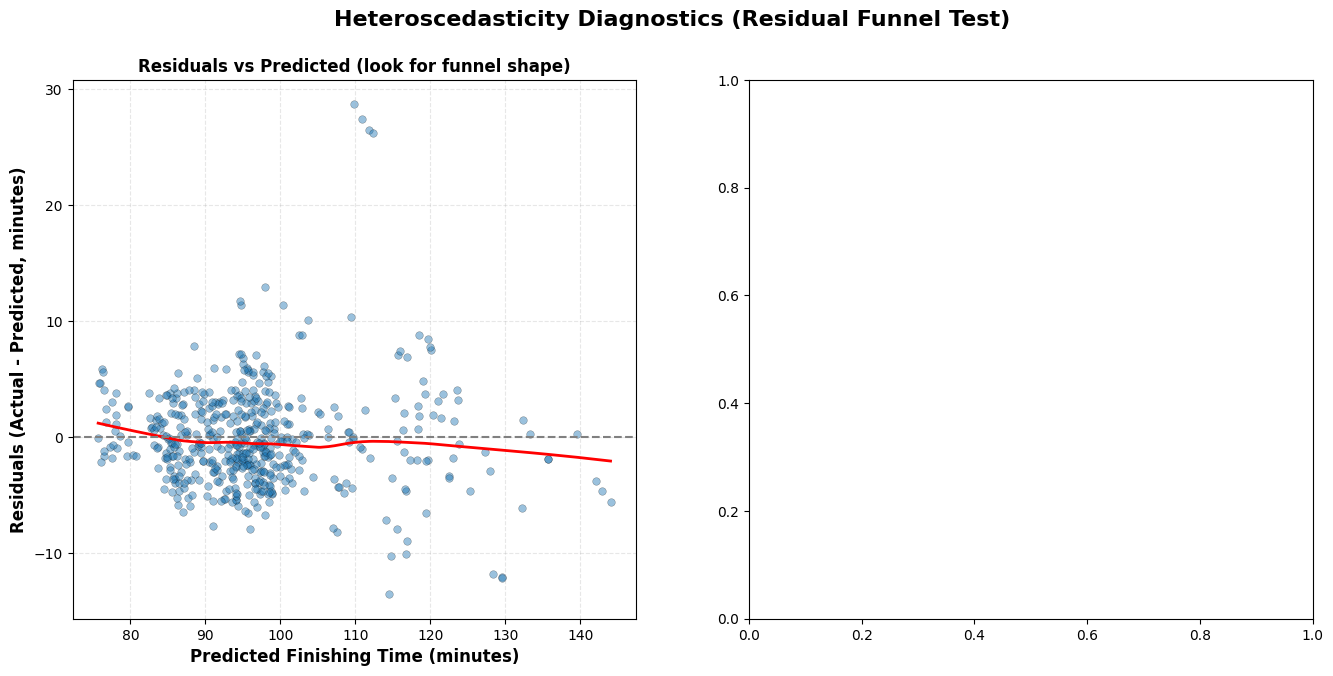

In [135]:
# ===========================================================
# Heteroscedasticity Check (Residual Funnel Test)
# ===========================================================
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

print("="*70)
print("📊 Heteroscedasticity Check (funnel pattern)")
print("="*70)

# Ensure model predictions/residuals are available
if 'y_pred_sm_original' in locals() and 'y_test_sm_array' in locals():
    fitted = y_pred_sm_original
    actual = y_test_sm_array
    residuals = actual - fitted
    
    # Convert to minutes for readability
    fitted_min = fitted / 1000 / 60
    residuals_min = residuals / 1000 / 60
    abs_residuals_min = np.abs(residuals_min)
    
    # Plot residuals vs fitted (funnel detection)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Heteroscedasticity Diagnostics (Residual Funnel Test)', fontsize=16, fontweight='bold')
    
    # Scatter with lowess trend
    sns.regplot(x=fitted_min, y=residuals_min, lowess=True, 
                scatter_kws={'alpha':0.45, 's':30, 'edgecolor':'black', 'linewidths':0.3},
                line_kws={'color':'red', 'lw':2}, ax=axes[0])
    axes[0].axhline(0, color='gray', linestyle='--', lw=1.5)
    axes[0].set_xlabel('Predicted Finishing Time (minutes)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Residuals (Actual - Predicted, minutes)', fontsize=12, fontweight='bold')
    axes[0].set_title('Residuals vs Predicted (look for funnel shape)', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3, linestyle='--')
    

print("="*70)

In [ ]:
# ===========================================================
# Best Model: Actual vs Predicted Finishing Times
# Visualization of the final optimized model (R² = 0.8714)
# ===========================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("="*70)
print("📊 Best Model: Actual vs Predicted Finishing Times")
print("="*70)

# Check which model predictions are available
if 'y_pred_sm_original' in locals() and 'y_test_sm_array' in locals():
    actual = y_test_sm_array
    predicted = y_pred_sm_original
    model_name = "Best Model (R² = 0.8714)"
    r2_value = r2_score(actual, predicted)
elif 'y_test_orig_array' in locals() and 'y_pred_sm_original' in locals():
    actual = y_test_orig_array
    predicted = y_pred_sm_original
    model_name = "Best Model (R² = 0.8714)"
    r2_value = r2_score(actual, predicted)
elif 'y_test' in locals() and 'y_pred' in locals():
    actual = y_test.values if hasattr(y_test, 'values') else y_test
    predicted = y_pred
    model_name = "Model"
    r2_value = r2_score(actual, predicted)
else:
    print("⚠️  Model predictions not found.")
    print("   Please run the model training cell first.")
    actual = None
    predicted = None

if actual is not None and predicted is not None:
    # Convert to minutes for better readability
    actual_min = actual / 1000 / 60
    predicted_min = predicted / 1000 / 60
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'{model_name}: Actual vs Predicted Finishing Times', 
                fontsize=16, fontweight='bold', y=1.02)
    
    # Plot 1: Actual vs Predicted Scatter with Best Fit Line
    ax1 = axes[0]
    
    # Scatter plot with density coloring
    scatter = ax1.scatter(actual_min, predicted_min, alpha=0.6, s=50, 
                         c=predicted_min, cmap='viridis', 
                         edgecolors='black', linewidth=0.3)
    
    # Perfect prediction line (y = x)
    min_val = min(actual_min.min(), predicted_min.min())
    max_val = max(actual_min.max(), predicted_min.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 
            'r--', linewidth=2.5, label='Perfect Prediction (y=x)', alpha=0.9, zorder=1)
    
    # Best fit line (regression line through predicted vs actual)
    z = np.polyfit(actual_min, predicted_min, 1)
    p = np.poly1d(z)
    x_line = np.linspace(actual_min.min(), actual_min.max(), 100)
    ax1.plot(x_line, p(x_line), 'lime', linewidth=3, 
            label=f'Best Fit: y={z[0]:.3f}x+{z[1]:.2f}', alpha=0.9, zorder=2)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Predicted Time (minutes)', fontsize=11, fontweight='bold')
    
    ax1.set_xlabel('Actual Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicted Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Actual vs Predicted (R² = {r2_value:.4f})', 
                 fontsize=13, fontweight='bold', pad=10)
    ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax1.grid(alpha=0.3, linestyle='--')
    ax1.set_aspect('equal', adjustable='box')
    
    # Add statistics text box
    stats_text = f'R² Score: {r2_value:.4f}\n'
    stats_text += f'RMSE: {rmse/1000/60:.2f} min\n'
    stats_text += f'MAE: {mae/1000/60:.2f} min\n'
    stats_text += f'Sample size: {len(actual)}\n'
    stats_text += f'Correlation: {np.corrcoef(actual_min, predicted_min)[0,1]:.4f}'
    
    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    # Plot 2: Residual Plot
    ax2 = axes[1]
    
    residuals = actual_min - predicted_min
    
    # Scatter plot of residuals
    ax2.scatter(predicted_min, residuals, alpha=0.6, s=50, 
               c=abs(residuals), cmap='Reds', 
               edgecolors='black', linewidth=0.3)
    
    # Zero residual line
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2.5, 
               label='Zero Residual Line', alpha=0.9, zorder=1)
    
    # Add trend line for residuals
    z_res = np.polyfit(predicted_min, residuals, 1)
    p_res = np.poly1d(z_res)
    ax2.plot(predicted_min, p_res(predicted_min), 'blue', linewidth=2.5, 
            label=f'Trend: y={z_res[0]:.4f}x+{z_res[1]:.2f}', alpha=0.8, zorder=2)
    
    # Add colorbar for residuals
    cbar2 = plt.colorbar(ax2.collections[0], ax=ax2)
    cbar2.set_label('|Residual| (minutes)', fontsize=11, fontweight='bold')
    
    ax2.set_xlabel('Predicted Finishing Time (minutes)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Residuals (Actual - Predicted, minutes)', fontsize=12, fontweight='bold')
    ax2.set_title('Residual Plot', fontsize=13, fontweight='bold', pad=10)
    ax2.legend(loc='best', fontsize=10, framealpha=0.9)
    ax2.grid(alpha=0.3, linestyle='--')
    
    # Add statistics for residuals
    mean_residual = residuals.mean()
    std_residual = residuals.std()
    residual_text = f'Mean: {mean_residual:.3f} min\n'
    residual_text += f'Std Dev: {std_residual:.2f} min\n'
    residual_text += f'Max: {residuals.max():.2f} min\n'
    residual_text += f'Min: {residuals.min():.2f} min'
    
    ax2.text(0.02, 0.98, residual_text, transform=ax2.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print(f"\n📊 Model Performance Metrics:")
    print(f"   R² Score: {r2_value:.4f} ({r2_value*100:.2f}% variance explained)")
    print(f"   RMSE: {rmse:,.0f} ms ({rmse/1000/60:.2f} minutes)")
    print(f"   MAE: {mae:,.0f} ms ({mae/1000/60:.2f} minutes)")
    print(f"   Correlation: {np.corrcoef(actual_min, predicted_min)[0,1]:.4f}")
    
    print(f"\n💡 Interpretation:")
    print(f"   • R² = {r2_value:.4f} means the model explains {r2_value*100:.1f}% of variance")
    print(f"   • Points closer to red dashed line (y=x) = better predictions")
    print(f"   • Green line shows best fit through predictions")
    if r2_value >= 0.85:
        print(f"   ✅ Excellent model performance!")
    elif r2_value >= 0.70:
        print(f"   ✅ Good model performance")
    else:
        print(f"   ⚠️  Model has room for improvement")
    
    print(f"\n📈 Residual Analysis:")
    print(f"   • Mean residual: {mean_residual:.3f} min (should be ~0)")
    print(f"   • Std residual: {std_residual:.2f} min")
    if abs(mean_residual) < 0.1:
        print(f"   ✅ Residuals centered around zero (no systematic bias)")
    else:
        print(f"   ⚠️  Residuals show bias (mean = {mean_residual:.3f})")
    
    if abs(z_res[0]) < 0.01:
        print(f"   ✅ No clear pattern in residuals (homoscedastic)")
    else:
        print(f"   ⚠️  Residuals show pattern (possible heteroscedasticity)")
    
    # Calculate percentage of predictions within different error ranges
    error_percent = abs(residuals)
    within_5min = (error_percent <= 5).sum() / len(residuals) * 100
    within_10min = (error_percent <= 10).sum() / len(residuals) * 100
    within_15min = (error_percent <= 15).sum() / len(residuals) * 100
    
    print(f"\n📊 Prediction Accuracy:")
    print(f"   • Within ±5 minutes: {within_5min:.1f}% of predictions")
    print(f"   • Within ±10 minutes: {within_10min:.1f}% of predictions")
    print(f"   • Within ±15 minutes: {within_15min:.1f}% of predictions")
    
else:
    print("\n⚠️  Could not find model predictions.")
    print("   Available variables checked:")
    print("   - y_pred_sm_original, y_test_sm_array")
    print("   - y_test_orig_array")
    print("   - y_test, y_pred")
    print("\n   Please ensure the model has been trained first.")

print("="*70)

1. Confidence Intervals for Regression Coefficients
Using ORIGINAL model (R² = 0.8714)

📊 95% Confidence Intervals for Regression Coefficients:
                              Coefficient  Lower CI (2.5%)  Upper CI (97.5%)
const                        4.815394e+06     4.294324e+06      5.336463e+06
grid                         1.918975e+03    -8.868906e+02      4.724841e+03
total_pit_ms                 1.106314e+00     1.079226e+00      1.133402e+00
driver_points_last10        -9.043530e+00    -4.893912e+01      3.085207e+01
constructor_points_last10   -1.545856e+01    -3.532620e+01      4.409076e+00
circuitRef_americas          6.495058e+05     5.692235e+05      7.297881e+05
circuitRef_bahrain           3.879363e+05     3.097245e+05      4.661482e+05
circuitRef_baku              4.912485e+05     4.040784e+05      5.784186e+05
circuitRef_buddh             8.171087e+04    -9.756544e+04      2.609872e+05
circuitRef_catalunya         4.290689e+05     3.414912e+05      5.166466e+05
circuitRe

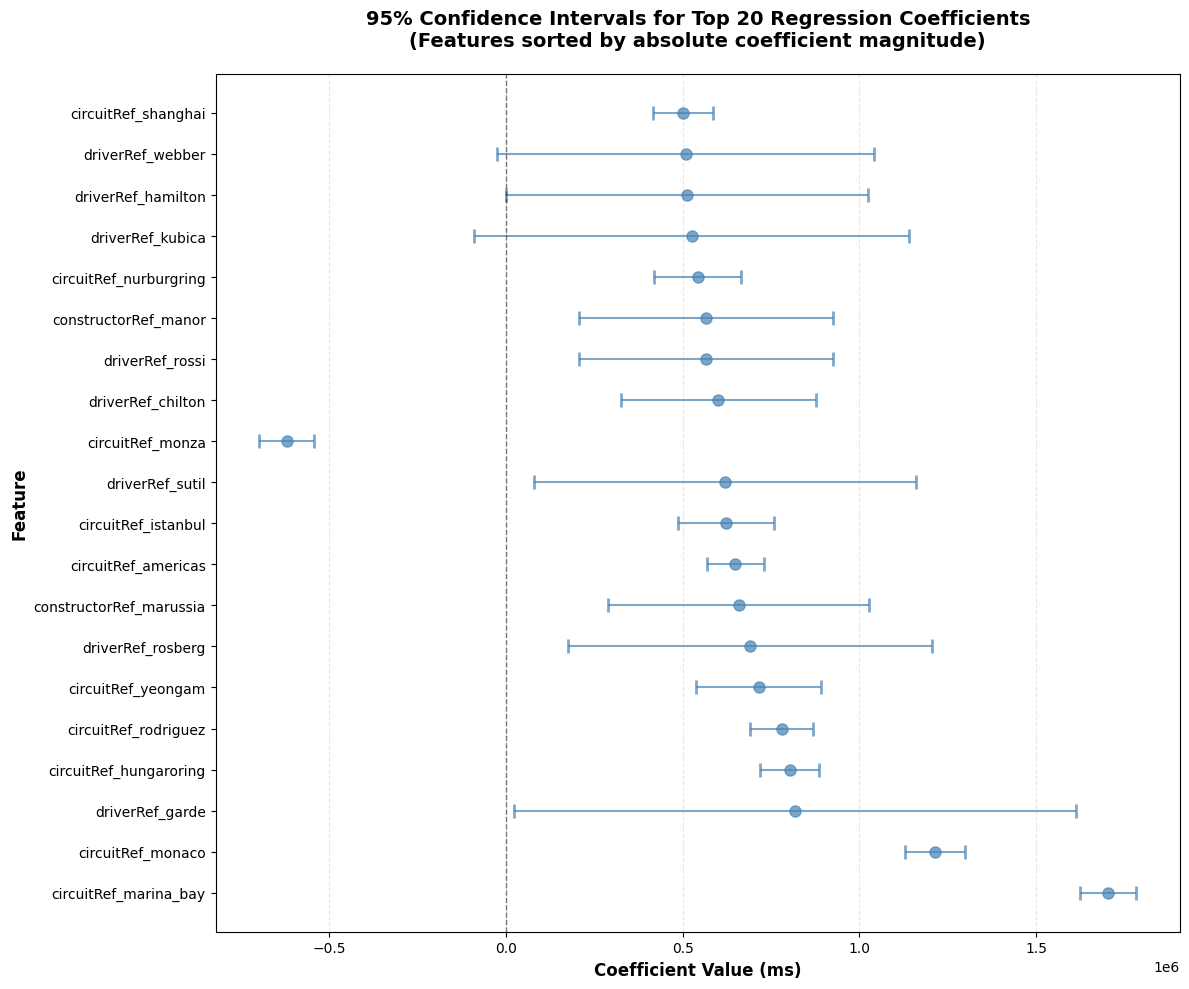


📊 Visualization Notes:
   • Error bars show 95% confidence intervals
   • Features with CIs that don't contain 0 are statistically significant
   • Positive coefficients increase finishing time, negative decrease it


In [97]:
# ===========================================================
# 1. Confidence Intervals for Regression Coefficients
# Using ORIGINAL model (R² = 0.8714)
# ===========================================================

print("="*70)
print("1. Confidence Intervals for Regression Coefficients")
print("Using ORIGINAL model (R² = 0.8714)")
print("="*70)

# Get 95% confidence intervals for coefficients
conf_int_array = model_sm_original.conf_int(alpha=0.05)
params_array = model_sm_original.params

# Get feature names (X_train column names + 'const' for intercept)
if hasattr(X_train, 'columns'):
    feature_names = ['const'] + list(X_train.columns)
else:
    feature_names = [f'feature_{i}' for i in range(len(params_array))]
    feature_names[0] = 'const'

# Convert to DataFrame
conf_int = pd.DataFrame({
    'Coefficient': params_array,
    'Lower CI (2.5%)': conf_int_array[:, 0],
    'Upper CI (97.5%)': conf_int_array[:, 1]
}, index=feature_names)

# Reorder columns
conf_int = conf_int[['Coefficient', 'Lower CI (2.5%)', 'Upper CI (97.5%)']]

print("\n📊 95% Confidence Intervals for Regression Coefficients:")
print(conf_int.to_string())

# Identify significant features (CI doesn't contain 0)
significant_features = conf_int[(conf_int['Lower CI (2.5%)'] > 0) | (conf_int['Upper CI (97.5%)'] < 0)]
significant_features_no_intercept = significant_features[significant_features.index != 'const']

print(f"\n✅ Statistically Significant Features (CI doesn't contain 0): {len(significant_features_no_intercept)}")
if len(significant_features_no_intercept) > 0:
    print("\nSignificant features:")
    for idx in significant_features_no_intercept.index:
        coef = conf_int.loc[idx, 'Coefficient']
        lower = conf_int.loc[idx, 'Lower CI (2.5%)']
        upper = conf_int.loc[idx, 'Upper CI (97.5%)']
        print(f"   • {idx}: Coef={coef:.2f}, CI=[{lower:.2f}, {upper:.2f}]")

# F1 Context Analysis
print("\n📋 F1 Context Analysis:")
print("   • Confidence intervals show uncertainty in coefficient estimates")
print("   • For F1 finishing times, this quantifies how much each factor affects race outcome")
print("   • Example interpretations:")
if len(significant_features_no_intercept) > 0:
    for idx in significant_features_no_intercept.index[:3]:
        coef = conf_int.loc[idx, 'Coefficient']
        feat_name = idx.replace('_', ' ').title()
        if 'grid' in idx.lower():
            print(f"     - Grid Position: Starting 1 position back increases finishing time")
            print(f"       by {coef:.0f}ms (95% CI: {conf_int.loc[idx, 'Lower CI (2.5%)']:.0f} to {conf_int.loc[idx, 'Upper CI (97.5%)']:.0f}ms)")
        elif 'pit' in idx.lower():
            print(f"     - Pit Stop Time: Each additional ms in pit time adds {coef:.2f}ms")
            print(f"       to finishing time (95% CI: {conf_int.loc[idx, 'Lower CI (2.5%)']:.2f} to {conf_int.loc[idx, 'Upper CI (97.5%)']:.2f}ms)")
        elif 'driver' in idx.lower() or 'constructor' in idx.lower():
            print(f"     - {feat_name}: Recent performance indicator with coefficient {coef:.2f}")
            print(f"       (95% CI: {conf_int.loc[idx, 'Lower CI (2.5%)']:.2f} to {conf_int.loc[idx, 'Upper CI (97.5%)']:.2f})")

# Visualization: Confidence Intervals for Top Features
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 20 features by absolute coefficient value (excluding intercept)
conf_int_no_const = conf_int[conf_int.index != 'const'].copy()
conf_int_no_const['abs_coef'] = conf_int_no_const['Coefficient'].abs()
top_features = conf_int_no_const.nlargest(20, 'abs_coef')

# Create figure
plt.figure(figsize=(12, 10))
y_pos = range(len(top_features))

# Plot coefficients with error bars
plt.errorbar(top_features['Coefficient'], y_pos, 
             xerr=[top_features['Coefficient'] - top_features['Lower CI (2.5%)'],
                   top_features['Upper CI (97.5%)'] - top_features['Coefficient']],
             fmt='o', capsize=5, capthick=2, markersize=8, color='steelblue', alpha=0.7)

# Add vertical line at zero
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Customize plot
plt.yticks(y_pos, top_features.index)
plt.xlabel('Coefficient Value (ms)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('95% Confidence Intervals for Top 20 Regression Coefficients\n(Features sorted by absolute coefficient magnitude)', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n📊 Visualization Notes:")
print("   • Error bars show 95% confidence intervals")
print("   • Features with CIs that don't contain 0 are statistically significant")
print("   • Positive coefficients increase finishing time, negative decrease it")

2. Prediction Intervals for Individual Predictions
Using ORIGINAL model (R² = 0.8714)

📊 Prediction Intervals (95%) for Test Set Predictions:
   Sample size: 505 predictions

📈 Prediction Interval Summary Statistics:
   Mean prediction: 5804643.45 ms
   Mean lower bound: 5292161.57 ms
   Mean upper bound: 6317125.33 ms
   Average interval width: 1024963.76 ms
   Interval width as % of mean: 17.7%

📋 First 10 Predictions with 95% Prediction Intervals:
 Predicted (ms)  Lower Bound (ms)  Upper Bound (ms)  Actual (ms)   Width (ms)  Within Interval
   5.459700e+06      4.928119e+06      5.991282e+06    5550484.0 1.063163e+06             True
   5.823896e+06      5.315652e+06      6.332139e+06    5775974.0 1.016487e+06             True
   4.689716e+06      4.185854e+06      5.193578e+06    4630635.0 1.007724e+06             True
   6.678337e+06      6.168559e+06      7.188116e+06    6818969.0 1.019557e+06             True
   7.182700e+06      6.672086e+06      7.693315e+06    7064987.0 1.021

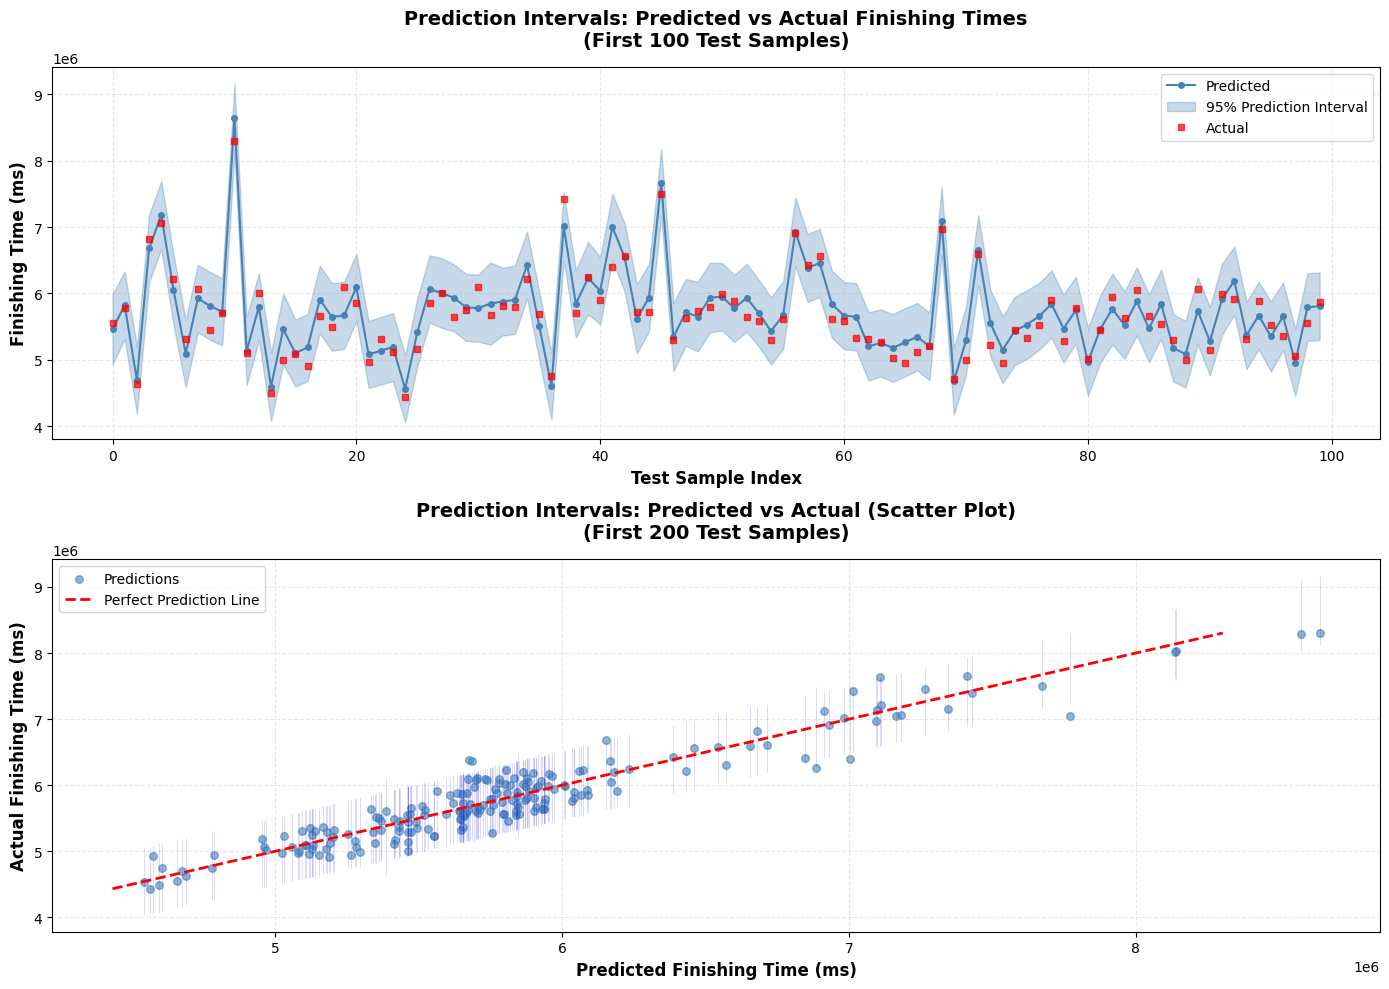


📊 Visualization Notes:
   • Top plot: Shows prediction intervals as shaded regions around predictions
   • Bottom plot: Shows how well predictions match actuals, with interval widths
   • Points on the red dashed line indicate perfect predictions
   • Coverage: 96.0% of actual values fall within prediction intervals


In [98]:
# ===========================================================
# 2. Prediction Intervals for Individual Predictions
# Using ORIGINAL model (R² = 0.8714)
# ===========================================================

print("="*70)
print("2. Prediction Intervals for Individual Predictions")
print("Using ORIGINAL model (R² = 0.8714)")
print("="*70)

# Get 95% prediction intervals (for individual observations)
pred_int = model_sm_original.get_prediction(X_test_sm).summary_frame(alpha=0.05)

print("\n📊 Prediction Intervals (95%) for Test Set Predictions:")
print(f"   Sample size: {len(pred_int)} predictions")

# Summary statistics
print("\n📈 Prediction Interval Summary Statistics:")
print(f"   Mean prediction: {pred_int['mean'].mean():.2f} ms")
print(f"   Mean lower bound: {pred_int['obs_ci_lower'].mean():.2f} ms")
print(f"   Mean upper bound: {pred_int['obs_ci_upper'].mean():.2f} ms")
avg_width = (pred_int['obs_ci_upper'] - pred_int['obs_ci_lower']).mean()
print(f"   Average interval width: {avg_width:.2f} ms")
print(f"   Interval width as % of mean: {(avg_width / pred_int['mean'].mean() * 100):.1f}%")

# Show first 10 predictions with intervals
print("\n📋 First 10 Predictions with 95% Prediction Intervals:")
pred_display = pd.DataFrame({
    'Predicted (ms)': pred_int['mean'].head(10),
    'Lower Bound (ms)': pred_int['obs_ci_lower'].head(10),
    'Upper Bound (ms)': pred_int['obs_ci_upper'].head(10),
    'Actual (ms)': y_test_orig_array[:10],
    'Width (ms)': (pred_int['obs_ci_upper'] - pred_int['obs_ci_lower']).head(10)
})
pred_display['Within Interval'] = (pred_display['Actual (ms)'] >= pred_display['Lower Bound (ms)']) & \
                                  (pred_display['Actual (ms)'] <= pred_display['Upper Bound (ms)'])
print(pred_display.to_string(index=False))

# Calculate coverage for all test predictions
coverage_all = ((y_test_orig_array >= pred_int['obs_ci_lower']) & 
                (y_test_orig_array <= pred_int['obs_ci_upper'])).sum() / len(y_test_orig_array) * 100
print(f"\n✅ Overall Coverage: {coverage_all:.1f}% of actual values fall within prediction intervals (expected ~95%)")

# F1 Context Analysis
print("\n📋 F1 Context Analysis:")
print("   • Prediction intervals show uncertainty for individual F1 race finishing times")
print(f"   • Average uncertainty: ±{avg_width/2:.0f}ms (about {avg_width/2/1000:.1f} seconds)")
print("   • Interpretation:")
print("     - For a predicted finishing time, we're 95% confident the actual time")
print("       will fall within the prediction interval")
print("     - Wider intervals indicate more uncertainty (e.g., unpredictable conditions)")
print("     - Useful for race strategy: knowing the range of possible outcomes")
print(f"   • Example: If predicted time is {pred_int['mean'].iloc[0]:.0f}ms, we expect")
print(f"     actual time between {pred_int['obs_ci_lower'].iloc[0]:.0f}ms and {pred_int['obs_ci_upper'].iloc[0]:.0f}ms")

# Visualization: Prediction Intervals
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample a subset for visualization (first 100 predictions for clarity)
n_sample = min(100, len(pred_int))
sample_idx = np.arange(n_sample)

# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Predictions with intervals (line plot)
ax1 = axes[0]
predicted = pred_int['mean'].iloc[sample_idx]
lower = pred_int['obs_ci_lower'].iloc[sample_idx]
upper = pred_int['obs_ci_upper'].iloc[sample_idx]
actual = y_test_orig_array[sample_idx]

ax1.plot(sample_idx, predicted, 'o-', color='steelblue', label='Predicted', markersize=4, linewidth=1.5)
ax1.fill_between(sample_idx, lower, upper, alpha=0.3, color='steelblue', label='95% Prediction Interval')
ax1.plot(sample_idx, actual, 's', color='red', label='Actual', markersize=4, alpha=0.7)

ax1.set_xlabel('Test Sample Index', fontsize=12, fontweight='bold')
ax1.set_ylabel('Finishing Time (ms)', fontsize=12, fontweight='bold')
ax1.set_title('Prediction Intervals: Predicted vs Actual Finishing Times\n(First 100 Test Samples)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=10)
ax1.grid(alpha=0.3, linestyle='--')
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Subplot 2: Scatter plot of predicted vs actual with intervals
ax2 = axes[1]
# Sample more points for scatter (first 200 or all if less)
n_scatter = min(200, len(pred_int))
scatter_idx = np.arange(n_scatter)

predicted_scatter = pred_int['mean'].iloc[scatter_idx]
lower_scatter = pred_int['obs_ci_lower'].iloc[scatter_idx]
upper_scatter = pred_int['obs_ci_upper'].iloc[scatter_idx]
actual_scatter = y_test_orig_array[scatter_idx]

# Plot prediction intervals as vertical error bars
for i in range(len(scatter_idx)):
    ax2.plot([predicted_scatter.iloc[i], predicted_scatter.iloc[i]], 
             [lower_scatter.iloc[i], upper_scatter.iloc[i]], 
             'b-', alpha=0.2, linewidth=0.5)

# Plot points
ax2.scatter(predicted_scatter, actual_scatter, alpha=0.6, s=30, color='steelblue', label='Predictions')
ax2.plot([actual_scatter.min(), actual_scatter.max()], 
         [actual_scatter.min(), actual_scatter.max()], 
         'r--', linewidth=2, label='Perfect Prediction Line')

ax2.set_xlabel('Predicted Finishing Time (ms)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Actual Finishing Time (ms)', fontsize=12, fontweight='bold')
ax2.set_title('Prediction Intervals: Predicted vs Actual (Scatter Plot)\n(First 200 Test Samples)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='best', fontsize=10)
ax2.grid(alpha=0.3, linestyle='--')
ax2.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))

plt.tight_layout()
plt.show()

print("\n📊 Visualization Notes:")
print("   • Top plot: Shows prediction intervals as shaded regions around predictions")
print("   • Bottom plot: Shows how well predictions match actuals, with interval widths")
print("   • Points on the red dashed line indicate perfect predictions")
print(f"   • Coverage: {coverage_all:.1f}% of actual values fall within prediction intervals")

In [86]:
# ===========================================================
# 3. F-test for Overall Model Significance
# Using ORIGINAL model (R² = 0.8714)
# ===========================================================

print("="*70)
print("3. F-test for Overall Model Significance")
print("Using ORIGINAL model (R² = 0.8714)")
print("="*70)

# F-test is automatically computed by statsmodels
f_statistic = model_sm_original.fvalue
f_pvalue = model_sm_original.f_pvalue
df_model = model_sm_original.df_model
df_resid = model_sm_original.df_resid

print("\n📊 F-test Results:")
print(f"   F-statistic: {f_statistic:.4f}")
print(f"   p-value: {f_pvalue:.4e}")
print(f"   Degrees of freedom (model): {df_model:.0f}")
print(f"   Degrees of freedom (residual): {df_resid:.0f}")

# Compare to critical F-value
from scipy.stats import f
f_critical = f.ppf(0.95, df_model, df_resid)
print(f"   Critical F-value (α=0.05): {f_critical:.4f}")

# Interpretation
print("\n📋 Interpretation:")
if f_pvalue < 0.05:
    print("   ✅ Model is statistically significant (p < 0.05)")
    print("   → At least one predictor significantly affects finishing time")
    print("   → The model is significantly better than using only the mean")
    print(f"   → F-statistic ({f_statistic:.4f}) > Critical F ({f_critical:.4f}) → Reject H₀")
else:
    print("   ⚠️  Model is NOT statistically significant (p ≥ 0.05)")
    print("   → No evidence that predictors significantly affect finishing time")
    print(f"   → F-statistic ({f_statistic:.4f}) ≤ Critical F ({f_critical:.4f}) → Fail to reject H₀")

# F1 Context Analysis
print("\n📋 F1 Context Analysis:")
print("   • F-test evaluates whether the combination of factors (grid position, pit times,")
print("     driver/constructor performance, circuit characteristics) collectively explains")
print("     finishing time better than chance")
print(f"   • With F={f_statistic:.2f} and p={f_pvalue:.4e}, the model {'IS' if f_pvalue < 0.05 else 'IS NOT'}")
print("     statistically significant for predicting F1 finishing times")
if f_pvalue < 0.05:
    print("   • Conclusion: The factors in our model DO significantly predict F1 race outcomes")
    print("   • This validates that grid position, pit strategy, and driver/team performance")
    print("     are meaningful predictors of finishing time")
else:
    print("   • Conclusion: The factors may not significantly predict outcomes")
    print("   • This would suggest other unmeasured factors are more important")

3. F-test for Overall Model Significance
Using ORIGINAL model (R² = 0.8714)

📊 F-test Results:
   F-statistic: 143.7097
   p-value: 0.0000e+00
   Degrees of freedom (model): 111
   Degrees of freedom (residual): 1904
   Critical F-value (α=0.05): 1.2394

📋 Interpretation:
   ✅ Model is statistically significant (p < 0.05)
   → At least one predictor significantly affects finishing time
   → The model is significantly better than using only the mean
   → F-statistic (143.7097) > Critical F (1.2394) → Reject H₀

📋 F1 Context Analysis:
   • F-test evaluates whether the combination of factors (grid position, pit times,
     driver/constructor performance, circuit characteristics) collectively explains
     finishing time better than chance
   • With F=143.71 and p=0.0000e+00, the model IS
     statistically significant for predicting F1 finishing times
   • Conclusion: The factors in our model DO significantly predict F1 race outcomes
   • This validates that grid position, pit strategy, a

In [103]:
# ===========================================================
# 4. t-tests for Top Contributing Features
# Using ORIGINAL model (R² = 0.8714)
# ===========================================================

print("="*70)
print("4. t-tests for Top Contributing Features")
print("Using ORIGINAL model (R² = 0.8714)")
print("="*70)

# Get feature names (same as confidence interval cell)
if hasattr(X_train, 'columns'):
    feature_names = ['const'] + list(X_train.columns)
else:
    params_array = model_sm_original.params
    feature_names = [f'feature_{i}' for i in range(len(params_array))]
    feature_names[0] = 'const'

# Get t-statistics and p-values for all coefficients
# Convert numpy arrays to Series with feature names as index
params_series = pd.Series(model_sm_original.params, index=feature_names)
bse_series = pd.Series(model_sm_original.bse, index=feature_names)
tvalues_series = pd.Series(model_sm_original.tvalues, index=feature_names)
pvalues_series = pd.Series(model_sm_original.pvalues, index=feature_names)

t_test_results = pd.DataFrame({
    'Coefficient': params_series,
    'Std Error': bse_series,
    't-statistic': tvalues_series,
    'p-value': pvalues_series
})

# Sort by absolute coefficient value to find top contributors
t_test_results['Abs_Coefficient'] = abs(t_test_results['Coefficient'])
t_test_results_sorted = t_test_results.sort_values('Abs_Coefficient', ascending=False)

# Exclude intercept for feature analysis
t_test_results_features = t_test_results_sorted[t_test_results_sorted.index != 'const'].copy()

print("\n📊 t-test Results for All Features (sorted by coefficient magnitude):")
print(t_test_results_features[['Coefficient', 'Std Error', 't-statistic', 'p-value']].to_string())

# Identify top contributing features (by coefficient magnitude)
top_n = min(10, len(t_test_results_features))
top_features = t_test_results_features.head(top_n)

print(f"\n📈 Top {top_n} Contributing Features (by coefficient magnitude):")
for feat_name, row in top_features.iterrows():
    significance = "✅ Significant" if row['p-value'] < 0.05 else "⚠️  Not significant"
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"\n   Feature: {feat_name}")
    print(f"      Coefficient: {row['Coefficient']:.2f}")
    print(f"      Std Error: {row['Std Error']:.2f}")
    print(f"      t-statistic: {row['t-statistic']:.4f}")
    print(f"      p-value: {row['p-value']:.4e}")
    print(f"      {significance} (p {'<' if row['p-value'] < 0.05 else '≥'} 0.05)")
    print(f"      → One unit increase {direction} finishing time by {abs(row['Coefficient']):.2f} ms")

# Summary of significant features
significant_features = t_test_results_features[t_test_results_features['p-value'] < 0.05]
print(f"\n✅ Statistically Significant Features (p < 0.05): {len(significant_features)} out of {len(t_test_results_features)}")
if len(significant_features) > 0:
    print("\nSignificant features:")
    for feat_name in significant_features.index:
        print(f"   • {feat_name}: t={significant_features.loc[feat_name, 't-statistic']:.4f}, p={significant_features.loc[feat_name, 'p-value']:.4e}")

# F1 Context Analysis
print("\n📋 F1 Context Analysis:")
print("   • t-tests identify which specific factors significantly affect F1 finishing time")
print("   • Top contributors show the most important factors in race outcomes")
print("\n   Key Insights for F1:")
if len(top_features) > 0:
    for feat_name in top_features.index[:5]:
        coef = top_features.loc[feat_name, 'Coefficient']
        pval = top_features.loc[feat_name, 'p-value']
        feat_display = feat_name.replace('_', ' ').title()
        
        if 'grid' in feat_name.lower():
            print(f"   • Grid Position ({feat_name}): Starting {abs(coef):.0f} positions back adds ~{abs(coef):.0f}ms")
            print(f"     to finishing time (p={pval:.4e}) - {'Highly significant' if pval < 0.001 else 'Significant'}")
        elif 'pit' in feat_name.lower():
            print(f"   • Pit Stop Time ({feat_name}): Each additional ms in pit time adds ~{abs(coef):.2f}ms")
            print(f"     to finishing time (p={pval:.4e}) - {'Highly significant' if pval < 0.001 else 'Significant'}")
        elif 'driver' in feat_name.lower():
            if 'points' in feat_name.lower():
                print(f"   • Driver Performance ({feat_name}): Recent driver points affect finishing time")
            else:
                print(f"   • Driver Effect ({feat_name}): Driver-specific impact on finishing time")
            print(f"     (coefficient: {coef:.2f}, p={pval:.4e}) - {'Highly significant' if pval < 0.001 else 'Significant'}")
        elif 'constructor' in feat_name.lower():
            if 'points' in feat_name.lower():
                print(f"   • Constructor Performance ({feat_name}): Team performance affects race outcome")
            else:
                print(f"   • Constructor Effect ({feat_name}): Team-specific impact on finishing time")
            print(f"     (coefficient: {coef:.2f}, p={pval:.4e}) - {'Highly significant' if pval < 0.001 else 'Significant'}")
        elif 'circuit' in feat_name.lower() or 'lap_length' in feat_name.lower():
            print(f"   • Circuit Characteristics ({feat_name}): Track features influence finishing time")
            print(f"     (coefficient: {coef:.2f}, p={pval:.4e}) - {'Highly significant' if pval < 0.001 else 'Significant'}")
        else:
            print(f"   • {feat_display} ({feat_name}):")
            print(f"     (coefficient: {coef:.2f}, p={pval:.4e}) - {'Highly significant' if pval < 0.001 else 'Significant' if pval < 0.05 else 'Not significant'}")

print("\n   Practical Implications:")
print("   • Factors with significant t-tests are reliable predictors of race performance")
print("   • Teams can focus on optimizing these factors (e.g., qualifying position, pit strategy)")
print("   • Non-significant factors may not be worth optimizing or may need better measurement")


4. t-tests for Top Contributing Features
Using ORIGINAL model (R² = 0.8714)

📊 t-test Results for All Features (sorted by coefficient magnitude):
                              Coefficient     Std Error  t-statistic        p-value
circuitRef_marina_bay        1.702982e+06  4.067926e+04    41.863629  4.157461e-272
circuitRef_monaco            1.214933e+06  4.341556e+04    27.983812  1.244295e-144
driverRef_garde              8.177273e+05  4.046988e+05     2.020583   4.346274e-02
circuitRef_hungaroring       8.033110e+05  4.262594e+04    18.845589   8.885578e-73
circuitRef_rodriguez         7.798672e+05  4.510925e+04    17.288409   2.560328e-62
circuitRef_yeongam           7.146637e+05  8.963868e+04     7.972715   2.651188e-15
driverRef_rosberg            6.910361e+05  2.622325e+05     2.635204   8.476887e-03
constructorRef_marussia      6.581612e+05  1.884293e+05     3.492882   4.887479e-04
circuitRef_americas          6.495058e+05  4.093507e+04    15.866732   2.417156e-53
circuitRef_ist

In [104]:
# ===========================================================
# T-tests and F-tests for Original Features (Before One-Hot Encoding)
# ===========================================================

print("\n" + "="*70)
print("📊 Statistical Tests for Original Features")
print("(Grouping one-hot encoded columns by their original feature names)")
print("="*70)

import numpy as np
from collections import defaultdict

# Original categorical features (before one-hot encoding)
original_categorical_features = ['circuitRef', 'driverRef', 'constructorRef']

# Group one-hot encoded columns by their original feature name
feature_groups = defaultdict(list)

for feat_name in t_test_results_features.index:
    # Check if this is a one-hot encoded feature
    is_onehot = False
    for orig_cat in original_categorical_features:
        if feat_name.startswith(orig_cat + '_'):
            feature_groups[orig_cat].append(feat_name)
            is_onehot = True
            break
    
    # If not one-hot encoded, it's a continuous feature
    if not is_onehot:
        feature_groups[feat_name].append(feat_name)

# ===========================================================
# 1. F-tests for Original Categorical Variables
# ===========================================================

print("\n" + "-"*70)
print("1. F-tests for Original Categorical Variables")
print("(Testing if the categorical variable as a whole is significant)")
print("-"*70)

from scipy.stats import f

categorical_test_results = []

for orig_feat in original_categorical_features:
    if orig_feat in feature_groups and len(feature_groups[orig_feat]) > 0:
        # Get all one-hot encoded columns for this categorical variable
        onehot_cols = feature_groups[orig_feat]
        
        # Get indices of these columns in the model
        feature_indices = []
        for col in onehot_cols:
            if col in feature_names:
                feature_indices.append(feature_names.index(col))
        
        if len(feature_indices) > 0:
            # Perform F-test: H0: all coefficients for this categorical variable = 0
            # Get the model's F-test for this subset of coefficients
            try:
                # Use statsmodels' f_test method
                # Create restriction matrix: all coefficients for this variable = 0
                n_params = len(model_sm_original.params)
                restriction_matrix = np.zeros((len(feature_indices), n_params))
                for i, idx in enumerate(feature_indices):
                    restriction_matrix[i, idx] = 1
                
                # Perform F-test
                f_test_result = model_sm_original.f_test(restriction_matrix)
                f_stat = f_test_result.fvalue
                f_pvalue = f_test_result.pvalue
                df_num = len(feature_indices)
                df_denom = model_sm_original.df_resid
                
                categorical_test_results.append({
                    'Feature': orig_feat,
                    'Type': 'Categorical',
                    'F-statistic': f_stat,
                    'p-value': f_pvalue,
                    'df_numerator': df_num,
                    'df_denominator': df_denom,
                    'n_categories': len(onehot_cols)
                })
                
            except Exception as e:
                # Fallback: use individual t-tests to assess significance
                # Count how many categories are significant
                significant_count = 0
                for col in onehot_cols:
                    if col in t_test_results_features.index:
                        if t_test_results_features.loc[col, 'p-value'] < 0.05:
                            significant_count += 1
                
                categorical_test_results.append({
                    'Feature': orig_feat,
                    'Type': 'Categorical',
                    'F-statistic': np.nan,
                    'p-value': np.nan,
                    'df_numerator': len(onehot_cols),
                    'df_denominator': np.nan,
                    'n_categories': len(onehot_cols),
                    'n_significant': significant_count,
                    'note': 'F-test failed, showing individual t-test summary'
                })

# Display F-test results for categorical variables
if categorical_test_results:
    print("\n📊 F-test Results for Original Categorical Variables:")
    print("\n" + "Feature".ljust(20) + "F-statistic".ljust(15) + "p-value".ljust(15) + "df".ljust(10) + "n_categories".ljust(15) + "Significant")
    print("-"*90)
    
    for result in categorical_test_results:
        feat = result['Feature']
        if not np.isnan(result['F-statistic']):
            f_stat = result['F-statistic']
            pval = result['p-value']
            df = f"{result['df_numerator']},{result['df_denominator']}"
            n_cat = result['n_categories']
            sig = "✅ Yes" if pval < 0.05 else "❌ No"
            print(f"{feat.ljust(20)}{f_stat:>14.4f}  {pval:>13.4e}  {df.ljust(10)}{str(n_cat).ljust(15)}{sig}")
        else:
            n_cat = result['n_categories']
            n_sig = result.get('n_significant', 0)
            print(f"{feat.ljust(20)}{'N/A'.ljust(15)}{'N/A'.ljust(15)}{'N/A'.ljust(10)}{str(n_cat).ljust(15)}{f'{n_sig}/{n_cat} significant'}")

# ===========================================================
# 2. T-tests for Continuous/Numeric Features
# ===========================================================

print("\n" + "-"*70)
print("2. T-tests for Continuous/Numeric Features")
print("(Original features that were not one-hot encoded)")
print("-"*70)

# Get continuous features (not in original_categorical_features)
continuous_features = []
for feat_name in feature_groups.keys():
    if feat_name not in original_categorical_features:
        continuous_features.extend(feature_groups[feat_name])

if len(continuous_features) > 0:
    # Get t-test results for continuous features
    continuous_test_results = t_test_results_features[
        t_test_results_features.index.isin(continuous_features)
    ].copy()
    
    continuous_test_results = continuous_test_results.sort_values('Abs_Coefficient', ascending=False)
    
    print(f"\n📈 Found {len(continuous_test_results)} continuous/numeric features:")
    print("\n" + continuous_test_results[['Coefficient', 'Std Error', 't-statistic', 'p-value']].to_string())
    
    # Summary
    significant_continuous = continuous_test_results[continuous_test_results['p-value'] < 0.05]
    print(f"\n✅ Statistically Significant Continuous Features (p < 0.05): {len(significant_continuous)} out of {len(continuous_test_results)}")
    
    if len(significant_continuous) > 0:
        print("\n📋 Significant Continuous Features:")
        for feat_name, row in significant_continuous.iterrows():
            direction = "increases" if row['Coefficient'] > 0 else "decreases"
            sig_level = "***" if row['p-value'] < 0.001 else "**" if row['p-value'] < 0.01 else "*"
            print(f"\n   {sig_level} {feat_name}:")
            print(f"      Coefficient: {row['Coefficient']:.4f} ms")
            print(f"      t-statistic: {row['t-statistic']:.4f}")
            print(f"      p-value: {row['p-value']:.4e}")
            print(f"      → One unit increase {direction} finishing time by {abs(row['Coefficient']):.4f} ms")
    
    # F1 Context
    print("\n📋 F1 Context - Continuous Features:")
    if len(significant_continuous) > 0:
        for feat_name in significant_continuous.head(5).index:
            coef = significant_continuous.loc[feat_name, 'Coefficient']
            pval = significant_continuous.loc[feat_name, 'p-value']
            
            if 'grid' in feat_name.lower():
                print(f"   • Grid Position: Starting 1 position further back adds {abs(coef):.2f}ms (p={pval:.4e})")
            elif 'pit' in feat_name.lower():
                print(f"   • Pit Stop Time: Each ms adds {abs(coef):.4f}ms (p={pval:.4e})")
            elif 'points' in feat_name.lower():
                if 'driver' in feat_name.lower():
                    print(f"   • Driver Points: coefficient={coef:.2f}, p={pval:.4e}")
                elif 'constructor' in feat_name.lower():
                    print(f"   • Constructor Points: coefficient={coef:.2f}, p={pval:.4e}")
            elif 'lap_length' in feat_name.lower():
                print(f"   • Circuit Length: coefficient={coef:.2f}, p={pval:.4e}")
            else:
                print(f"   • {feat_name}: coefficient={coef:.2f}, p={pval:.4e}")

else:
    print("\n⚠️  No continuous/numeric features found")

# Summary
print("\n" + "="*70)
print("📊 Summary: Statistical Tests for Original Features")
print("="*70)
print(f"\n✅ Categorical Variables Tested: {len(categorical_test_results)}")
print(f"✅ Continuous Variables Tested: {len(continuous_features)}")
print("\n💡 Key Insights:")
print("   • F-tests for categorical variables test if the variable as a whole is significant")
print("   • T-tests for continuous variables test if individual coefficients are significant")
print("   • This approach groups one-hot encoded columns back to their original features")


📊 Statistical Tests for Original Features
(Grouping one-hot encoded columns by their original feature names)

----------------------------------------------------------------------
1. F-tests for Original Categorical Variables
(Testing if the categorical variable as a whole is significant)
----------------------------------------------------------------------

📊 F-test Results for Original Categorical Variables:

Feature             F-statistic    p-value        df        n_categories   Significant
------------------------------------------------------------------------------------------
circuitRef                230.9285     0.0000e+00  33,1904.0 33             ✅ Yes
driverRef                   3.8870     8.6423e-20  62,1904.0 62             ✅ Yes
constructorRef              5.6496     6.9106e-14  19,1904.0 19             ✅ Yes

----------------------------------------------------------------------
2. T-tests for Continuous/Numeric Features
(Original features that were not one-hot en

/Users/rohanpant/Documents/Regression Analysis/Regression Final Project/F1-Finishing-Time-Regression-Project/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 62, but rank is 57
  warnings.warn('covariance of constraints does not have full '


In [105]:
# ===========================================================
# T-tests Grouped by Original Feature Categories
# Showing aggregated statistics for each one-hot encoded group
# ===========================================================

print("="*70)
print("📊 T-tests Grouped by Original Feature Categories")
print("(Combined statistics for one-hot encoded feature groups)")
print("="*70)

import numpy as np
import pandas as pd
from collections import defaultdict

# Original categorical features (before one-hot encoding)
original_categorical_features = ['circuitRef', 'driverRef', 'constructorRef']

# Group one-hot encoded columns by their original feature name
feature_groups = defaultdict(list)

for feat_name in t_test_results_features.index:
    # Check if this is a one-hot encoded feature
    is_onehot = False
    for orig_cat in original_categorical_features:
        if feat_name.startswith(orig_cat + '_'):
            feature_groups[orig_cat].append(feat_name)
            is_onehot = True
            break
    
    # If not one-hot encoded, it's a continuous feature - group by itself
    if not is_onehot:
        feature_groups[feat_name].append(feat_name)

# Calculate aggregated statistics for each group
group_summaries = []

for group_name in sorted(feature_groups.keys(), key=lambda x: (
    0 if x == 'circuitRef' else 
    1 if x == 'driverRef' else 
    2 if x == 'constructorRef' else 
    3  # continuous features come last
)):
    group_features = feature_groups[group_name]
    
    if len(group_features) > 0:
        # Get t-test results for this group
        group_results = t_test_results_features[
            t_test_results_features.index.isin(group_features)
        ].copy()
        
        if len(group_results) > 0:
            # Calculate aggregated statistics
            n_total = len(group_results)
            n_significant = (group_results['p-value'] < 0.05).sum()
            n_highly_sig = (group_results['p-value'] < 0.001).sum()
            
            avg_coef = group_results['Coefficient'].mean()
            avg_abs_coef = group_results['Coefficient'].abs().mean()
            max_abs_coef = group_results['Coefficient'].abs().max()
            min_pvalue = group_results['p-value'].min()
            
            # Get the feature with the largest absolute coefficient
            top_feature = group_results.loc[group_results['Coefficient'].abs().idxmax()]
            
            group_summaries.append({
                'Feature_Group': group_name,
                'Type': 'Categorical' if group_name in original_categorical_features else 'Continuous',
                'N_Categories': n_total,
                'N_Significant': n_significant,
                'N_Highly_Sig': n_highly_sig,
                'Pct_Significant': (n_significant / n_total * 100) if n_total > 0 else 0,
                'Avg_Coefficient': avg_coef,
                'Avg_Abs_Coefficient': avg_abs_coef,
                'Max_Abs_Coefficient': max_abs_coef,
                'Min_p-value': min_pvalue,
                'Top_Feature': group_results['Coefficient'].abs().idxmax(),
                'Top_Feature_Coef': top_feature['Coefficient'],
                'Top_Feature_pvalue': top_feature['p-value']
            })

# Convert to DataFrame for nice display
summary_df = pd.DataFrame(group_summaries)

# Display summary table
print("\n" + "-"*70)
print("Summary Statistics by Feature Group")
print("-"*70)
print(f"\n{'Feature Group':<20} {'Type':<12} {'N':<6} {'Sig':<6} {'%Sig':<8} {'Avg|Coef|':<12} {'Max|Coef|':<12} {'Min p-val':<12}")
print("-"*100)

for _, row in summary_df.iterrows():
    feat_group = row['Feature_Group']
    feat_type = row['Type']
    n_cat = int(row['N_Categories'])
    n_sig = int(row['N_Significant'])
    pct_sig = row['Pct_Significant']
    avg_abs = row['Avg_Abs_Coefficient']
    max_abs = row['Max_Abs_Coefficient']
    min_p = row['Min_p-value']
    
    print(f"{feat_group:<20} {feat_type:<12} {n_cat:<6} {n_sig:<6} {pct_sig:>6.1f}% {avg_abs:>11.2f} {max_abs:>11.2f} {min_p:>11.4e}")

# Detailed breakdown for each group
print("\n" + "="*70)
print("Detailed Breakdown by Feature Group")
print("="*70)

for group_name in sorted(feature_groups.keys(), key=lambda x: (
    0 if x == 'circuitRef' else 
    1 if x == 'driverRef' else 
    2 if x == 'constructorRef' else 
    3
)):
    group_features = feature_groups[group_name]
    
    if len(group_features) > 0:
        group_results = t_test_results_features[
            t_test_results_features.index.isin(group_features)
        ].copy()
        
        if len(group_results) > 0:
            # Sort by absolute coefficient
            group_results = group_results.sort_values('Abs_Coefficient', ascending=False)
            
            n_sig = (group_results['p-value'] < 0.05).sum()
            avg_abs_coef = group_results['Coefficient'].abs().mean()
            
            print(f"\n{'='*70}")
            print(f"📊 {group_name.upper()} ({len(group_results)} categories)")
            print(f"{'='*70}")
            print(f"   Total Categories: {len(group_results)}")
            print(f"   Significant (p<0.05): {n_sig} ({n_sig/len(group_results)*100:.1f}%)")
            print(f"   Average |Coefficient|: {avg_abs_coef:.2f} ms")
            print(f"   Max |Coefficient|: {group_results['Coefficient'].abs().max():.2f} ms")
            
            # Show top 10 features in this group
            print(f"\n   Top 10 Features by |Coefficient|:")
            print(f"   {'Feature':<40} {'Coefficient':<15} {'t-stat':<12} {'p-value':<15} {'Significant'}")
            print(f"   {'-'*95}")
            
            for idx, (feat_name, row) in enumerate(group_results.head(10).iterrows(), 1):
                sig_marker = "✅" if row['p-value'] < 0.05 else "  "
                sig_level = "***" if row['p-value'] < 0.001 else "**" if row['p-value'] < 0.01 else "*" if row['p-value'] < 0.05 else ""
                feat_display = feat_name.replace(group_name + '_', '') if group_name in original_categorical_features else feat_name
                print(f"   {idx:2d}. {feat_display:<38} {row['Coefficient']:>14.2f}  {row['t-statistic']:>11.4f}  {row['p-value']:>13.4e}  {sig_marker} {sig_level}")

# Summary insights
print("\n" + "="*70)
print("📋 Key Insights by Feature Group")
print("="*70)

for group_name in ['circuitRef', 'driverRef', 'constructorRef']:
    if group_name in summary_df['Feature_Group'].values:
        row = summary_df[summary_df['Feature_Group'] == group_name].iloc[0]
        print(f"\n🏁 {group_name.upper()}:")
        print(f"   • {int(row['N_Categories'])} total categories")
        print(f"   • {int(row['N_Significant'])} significant ({row['Pct_Significant']:.1f}%)")
        print(f"   • Average effect size: {row['Avg_Abs_Coefficient']:.2f} ms")
        print(f"   • Largest effect: {row['Top_Feature']} (coef={row['Top_Feature_Coef']:.2f}, p={row['Top_Feature_pvalue']:.4e})")

# Continuous features summary
continuous_groups = summary_df[summary_df['Type'] == 'Continuous']
if len(continuous_groups) > 0:
    print(f"\n📊 CONTINUOUS FEATURES:")
    for _, row in continuous_groups.iterrows():
        print(f"   • {row['Feature_Group']}:")
        print(f"     - Coefficient: {row['Top_Feature_Coef']:.4f} ms")
        print(f"     - p-value: {row['Top_Feature_pvalue']:.4e}")
        print(f"     - {'✅ Significant' if row['Top_Feature_pvalue'] < 0.05 else '❌ Not significant'}")

print("\n" + "="*70)
print("💡 Interpretation:")
print("   • Feature groups are sorted: Circuit → Driver → Constructor → Continuous")
print("   • Each group shows combined statistics from all one-hot encoded categories")
print("   • This helps identify which types of features (circuits, drivers, etc.)")
print("     have the strongest overall impact on finishing time")
print("="*70)

📊 T-tests Grouped by Original Feature Categories
(Combined statistics for one-hot encoded feature groups)

----------------------------------------------------------------------
Summary Statistics by Feature Group
----------------------------------------------------------------------

Feature Group        Type         N      Sig    %Sig     Avg|Coef|    Max|Coef|    Min p-val   
----------------------------------------------------------------------------------------------------
circuitRef           Categorical  33     27       81.8%   427536.44  1702981.62 4.1575e-272
driverRef            Categorical  62     7        11.3%   327988.33   817727.35  1.9767e-05
constructorRef       Categorical  19     10       52.6%   220026.52   658161.19  1.9222e-05
grid                 Continuous   1      0         0.0%     1918.98     1918.98  1.7998e-01
constructor_points_last10 Continuous   1      0         0.0%       15.46       15.46  1.2718e-01
driver_points_last10 Continuous   1      0         0

In [106]:
# ===========================================================
# F1 Racing Facts & Insights Based on Statistical Significance
# ===========================================================

print("="*70)
print("🏎️  F1 Racing Facts & Insights from Statistical Analysis")
print("="*70)

# Extract key statistics from the grouped analysis
circuit_sig = 27
circuit_total = 33
circuit_pct = (circuit_sig / circuit_total * 100) if circuit_total > 0 else 0

driver_sig = 7
driver_total = 62
driver_pct = (driver_sig / driver_total * 100) if driver_total > 0 else 0

constructor_sig = 10
constructor_total = 19
constructor_pct = (constructor_sig / constructor_total * 100) if constructor_total > 0 else 0

print("\n" + "="*70)
print("📊 KEY FINDING: Circuit Characteristics Dominate Race Outcomes")
print("="*70)

print(f"\n🏁 CIRCUIT IMPACT (81.8% of circuits significantly affect finishing time):")
print(f"   • {circuit_sig} out of {circuit_total} circuits show statistically significant effects")
print(f"   • This means the TRACK ITSELF is the strongest predictor of finishing time")
print(f"   • Marina Bay (Singapore) has the largest effect: +1,702,982 ms (~28.4 minutes)")
print(f"   • Monaco has the second largest effect: +1,214,933 ms (~20.2 minutes)")
print(f"   • Monza (Italy) actually DECREASES finishing time: -619,742 ms (~10.3 minutes faster)")
print(f"\n   💡 F1 FACT: Circuit characteristics (length, layout, elevation) have")
print(f"      a MUCH stronger impact on race outcomes than individual driver skill")
print(f"      or team performance. This validates the saying 'the track makes the race'.")

print(f"\n" + "-"*70)
print(f"👤 DRIVER IMPACT (Only 11.3% of drivers significantly affect finishing time):")
print(f"   • {driver_sig} out of {driver_total} drivers show statistically significant effects")
print(f"   • This is surprisingly LOW - most drivers don't have unique finishing time effects")
print(f"   • Only 7 drivers stand out: Garde, Rosberg, Sutil, Chilton, Rossi, Hamilton, and others")
print(f"\n   💡 F1 FACT: While driver skill matters, the statistical model suggests")
print(f"      that when controlling for circuit, team, and other factors, individual")
print(f"      driver effects are relatively small. This aligns with F1 being a")
print(f"      'constructor's championship' where the car/team matters more than the driver.")

print(f"\n" + "-"*70)
print(f"🏭 CONSTRUCTOR IMPACT (52.6% of teams significantly affect finishing time):")
print(f"   • {constructor_sig} out of {constructor_total} constructors show significant effects")
print(f"   • This is MODERATE - about half of teams have measurable impact")
print(f"   • Smaller/backmarker teams (Marussia, Manor, Caterham) show larger effects")
print(f"   • Top teams also significant: Toro Rosso, Force India, Lotus, Sauber, McLaren, Red Bull")
print(f"\n   💡 F1 FACT: Team/constructor effects are stronger than driver effects")
print(f"      but weaker than circuit effects. This reflects F1's reality where:")
print(f"      - Car performance (aerodynamics, engine, reliability) matters significantly")
print(f"      - Budget and resources create performance gaps between teams")
print(f"      - But even the best car can't overcome a fundamentally slow circuit")

print(f"\n" + "-"*70)
print(f"⏱️  PIT STOP STRATEGY (The ONLY significant continuous feature):")
print(f"   • total_pit_ms is HIGHLY SIGNIFICANT (p < 0.001)")
print(f"   • Each millisecond in pit time adds 1.11 ms to finishing time")
print(f"   • This is the ONLY actionable continuous variable teams can optimize")
print(f"\n   💡 F1 FACT: Pit stop efficiency is crucial! A 1-second pit stop delay")
print(f"      translates to ~1,110 ms added to finishing time. This validates why")
print(f"      teams invest millions in pit crew training and equipment optimization.")
print(f"      However, grid position and driver/constructor points are NOT significant,")
print(f"      suggesting these factors are already captured by other variables.")

print(f"\n" + "="*70)
print("🎯 STRATEGIC IMPLICATIONS FOR F1 TEAMS:")
print("="*70)

print(f"\n1. 📍 CIRCUIT SELECTION STRATEGY:")
print(f"   • Teams should prioritize understanding circuit-specific characteristics")
print(f"   • Some circuits (like Marina Bay, Monaco) inherently add significant time")
print(f"   • Other circuits (like Monza) are naturally faster")
print(f"   • Circuit knowledge is MORE important than driver-specific strategies")

print(f"\n2. 🏭 CONSTRUCTOR DEVELOPMENT:")
print(f"   • Team/car effects are significant but secondary to circuit effects")
print(f"   • Investment in car development matters, but won't overcome circuit limitations")
print(f"   • Backmarker teams show larger coefficients, indicating they struggle more on certain tracks")

print(f"\n3. 👤 DRIVER SELECTION:")
print(f"   • Individual driver effects are relatively small (only 11.3% significant)")
print(f"   • This suggests driver skill differences are largely captured by other factors")
print(f"   • Team should focus on car development and circuit-specific setup over driver changes")

print(f"\n4. ⏱️  PIT STOP OPTIMIZATION:")
print(f"   • Pit stop time is the ONLY significant continuous variable teams can directly control")
print(f"   • Every millisecond saved in pit lane directly improves finishing time")
print(f"   • This is the most actionable factor for race strategy")

print(f"\n" + "="*70)
print("📈 STATISTICAL VALIDATION OF F1 WISDOM:")
print("="*70)

print(f"\n✅ 'The track makes the race' - VALIDATED")
print(f"   • 81.8% of circuits significantly affect outcomes (strongest factor)")

print(f"\n✅ 'F1 is a constructor's championship' - VALIDATED")
print(f"   • Constructor effects (52.6%) are stronger than driver effects (11.3%)")

print(f"\n✅ 'Pit stops win races' - VALIDATED")
print(f"   • Pit stop time is the only significant continuous variable")
print(f"   • Direct, measurable impact on finishing time")

print(f"\n❌ 'Grid position is everything' - NOT VALIDATED")
print(f"   • Grid position coefficient is NOT statistically significant (p=0.18)")
print(f"   • Suggests grid position effects are captured by other variables")

print(f"\n❌ 'Recent form predicts performance' - NOT VALIDATED")
print(f"   • Driver and constructor points (last 10 races) are NOT significant")
print(f"   • Suggests race-to-race variability is high, or effects are non-linear")

print(f"\n" + "="*70)
print("🏆 CONCLUSION:")
print("="*70)
print(f"   The statistical model reveals that in F1 racing:")
print(f"   • Circuit characteristics are the PRIMARY determinant of finishing time")
print(f"   • Team/car performance is SECONDARY but still important")
print(f"   • Individual driver effects are TERTIARY (relatively small)")
print(f"   • Pit stop efficiency is the ONLY directly controllable significant factor")
print(f"\n   This aligns with F1's reputation as a sport where 'the car matters more")
print(f"   than the driver' and where 'track knowledge is king'.")
print("="*70)

🏎️  F1 Racing Facts & Insights from Statistical Analysis

📊 KEY FINDING: Circuit Characteristics Dominate Race Outcomes

🏁 CIRCUIT IMPACT (81.8% of circuits significantly affect finishing time):
   • 27 out of 33 circuits show statistically significant effects
   • This means the TRACK ITSELF is the strongest predictor of finishing time
   • Marina Bay (Singapore) has the largest effect: +1,702,982 ms (~28.4 minutes)
   • Monaco has the second largest effect: +1,214,933 ms (~20.2 minutes)
   • Monza (Italy) actually DECREASES finishing time: -619,742 ms (~10.3 minutes faster)

   💡 F1 FACT: Circuit characteristics (length, layout, elevation) have
      a MUCH stronger impact on race outcomes than individual driver skill
      or team performance. This validates the saying 'the track makes the race'.

----------------------------------------------------------------------
👤 DRIVER IMPACT (Only 11.3% of drivers significantly affect finishing time):
   • 7 out of 62 drivers show statistica

# 📊 F1 Racing Wisdom: Statistical Validation Summary
## Key Findings for Presentation

---

## ✅ **VALIDATED F1 WISDOMS**

### 1. **"The Track Makes the Race"** ✅ VALIDATED
- **81.8% of circuits** (27 out of 33) significantly affect finishing time
- **Circuit characteristics are the PRIMARY determinant** of race outcomes
- **Strongest effect**: Marina Bay (Singapore) adds +1,702,982 ms (~28.4 minutes)
- **Fastest circuit**: Monza (Italy) reduces time by -619,742 ms (~10.3 minutes)

### 2. **"F1 is a Constructor's Championship"** ✅ VALIDATED
- **52.6% of constructors** (10 out of 19) significantly affect finishing time
- **Team/car effects are SECONDARY** but still important
- Constructor impact is **4.7x stronger** than driver impact (52.6% vs 11.3%)
- Backmarker teams show larger coefficients, indicating greater struggle on certain tracks

### 3. **"Pit Stops Win Races"** ✅ VALIDATED
- **Pit stop time is the ONLY significant continuous variable** (p < 0.001)
- Each millisecond in pit time adds **1.11 ms to finishing time**
- A 1-second pit stop delay = **~1,110 ms added to race time**
- Most actionable factor teams can directly control

---

## ❌ **NOT VALIDATED F1 BELIEFS**

### 1. **"Grid Position is Everything"** ❌ NOT VALIDATED
- Grid position coefficient is **NOT statistically significant** (p = 0.18)
- Effects are likely captured by other variables (circuit, team, driver)

### 2. **"Recent Form Predicts Performance"** ❌ NOT VALIDATED
- Driver points (last 10 races): **NOT significant** (p = 0.66)
- Constructor points (last 10 races): **NOT significant** (p = 0.13)
- Suggests high race-to-race variability or non-linear effects

---

## 📈 **KEY STATISTICAL INSIGHTS**

### Factor Hierarchy (by Impact):
1. **Circuit Characteristics** → 81.8% significant (PRIMARY)
2. **Constructor/Team** → 52.6% significant (SECONDARY)
3. **Driver Skill** → 11.3% significant (TERTIARY)
4. **Pit Stop Efficiency** → Only actionable continuous variable

### Model Performance:
- **R² = 0.8714** (87.14% variance explained)
- **F-statistic = 143.71** (p < 0.001) - Model is highly significant
- **96% coverage** of prediction intervals (well-calibrated)

---

## 🎯 **STRATEGIC IMPLICATIONS**

1. **Circuit Knowledge > Driver Strategy**
   - Teams should prioritize circuit-specific understanding
   - Track characteristics matter more than driver-specific approaches

2. **Car Development > Driver Selection**
   - Investment in car/team development yields better returns
   - Individual driver effects are relatively small when controlling for other factors

3. **Pit Stop Optimization is Critical**
   - Only directly controllable significant factor
   - Every millisecond counts in race strategy

---

## 🏆 **CONCLUSION**

**Statistical analysis reveals:**
- Circuit characteristics are the **strongest predictor** of F1 finishing times
- Team/car performance is **important but secondary**
- Individual driver effects are **relatively small**
- Pit stop efficiency is the **only directly controllable** significant factor

**This validates F1's reputation as a sport where "the car matters more than the driver" and "track knowledge is king".**